# Analysis of Deconvolved 10k Windows

**Background:** 
Switched deconvolution from gene/origin centric to the entire genome. This will now require an API to load the approporiate 10k window (and stitch if needed) for gene and origin analysis. And for transcription factor and nucleosome-centric analyses.


In [2]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
from src.GenomeDeconvolutionAnalysis import GenomeDeconvolutionAnalysis

outdir = "output/deconvolve_genome_g0066_10k_10x10_2024_09_20"
analysis = GenomeDeconvolutionAnalysis(outdir)


In [4]:
from src.geneset import get_deconvolved_geneset
genes = get_deconvolved_geneset()

In [381]:
from src.GenomeDeconvolutionAnalysis import load_stacked_mnase_data_for_genes
mean_loaded_genes = load_stacked_mnase_data_for_genes(genes, chroms=[1])

Text(0.5, 0.98, 'All genes on chromosome 1 (sanity check)')

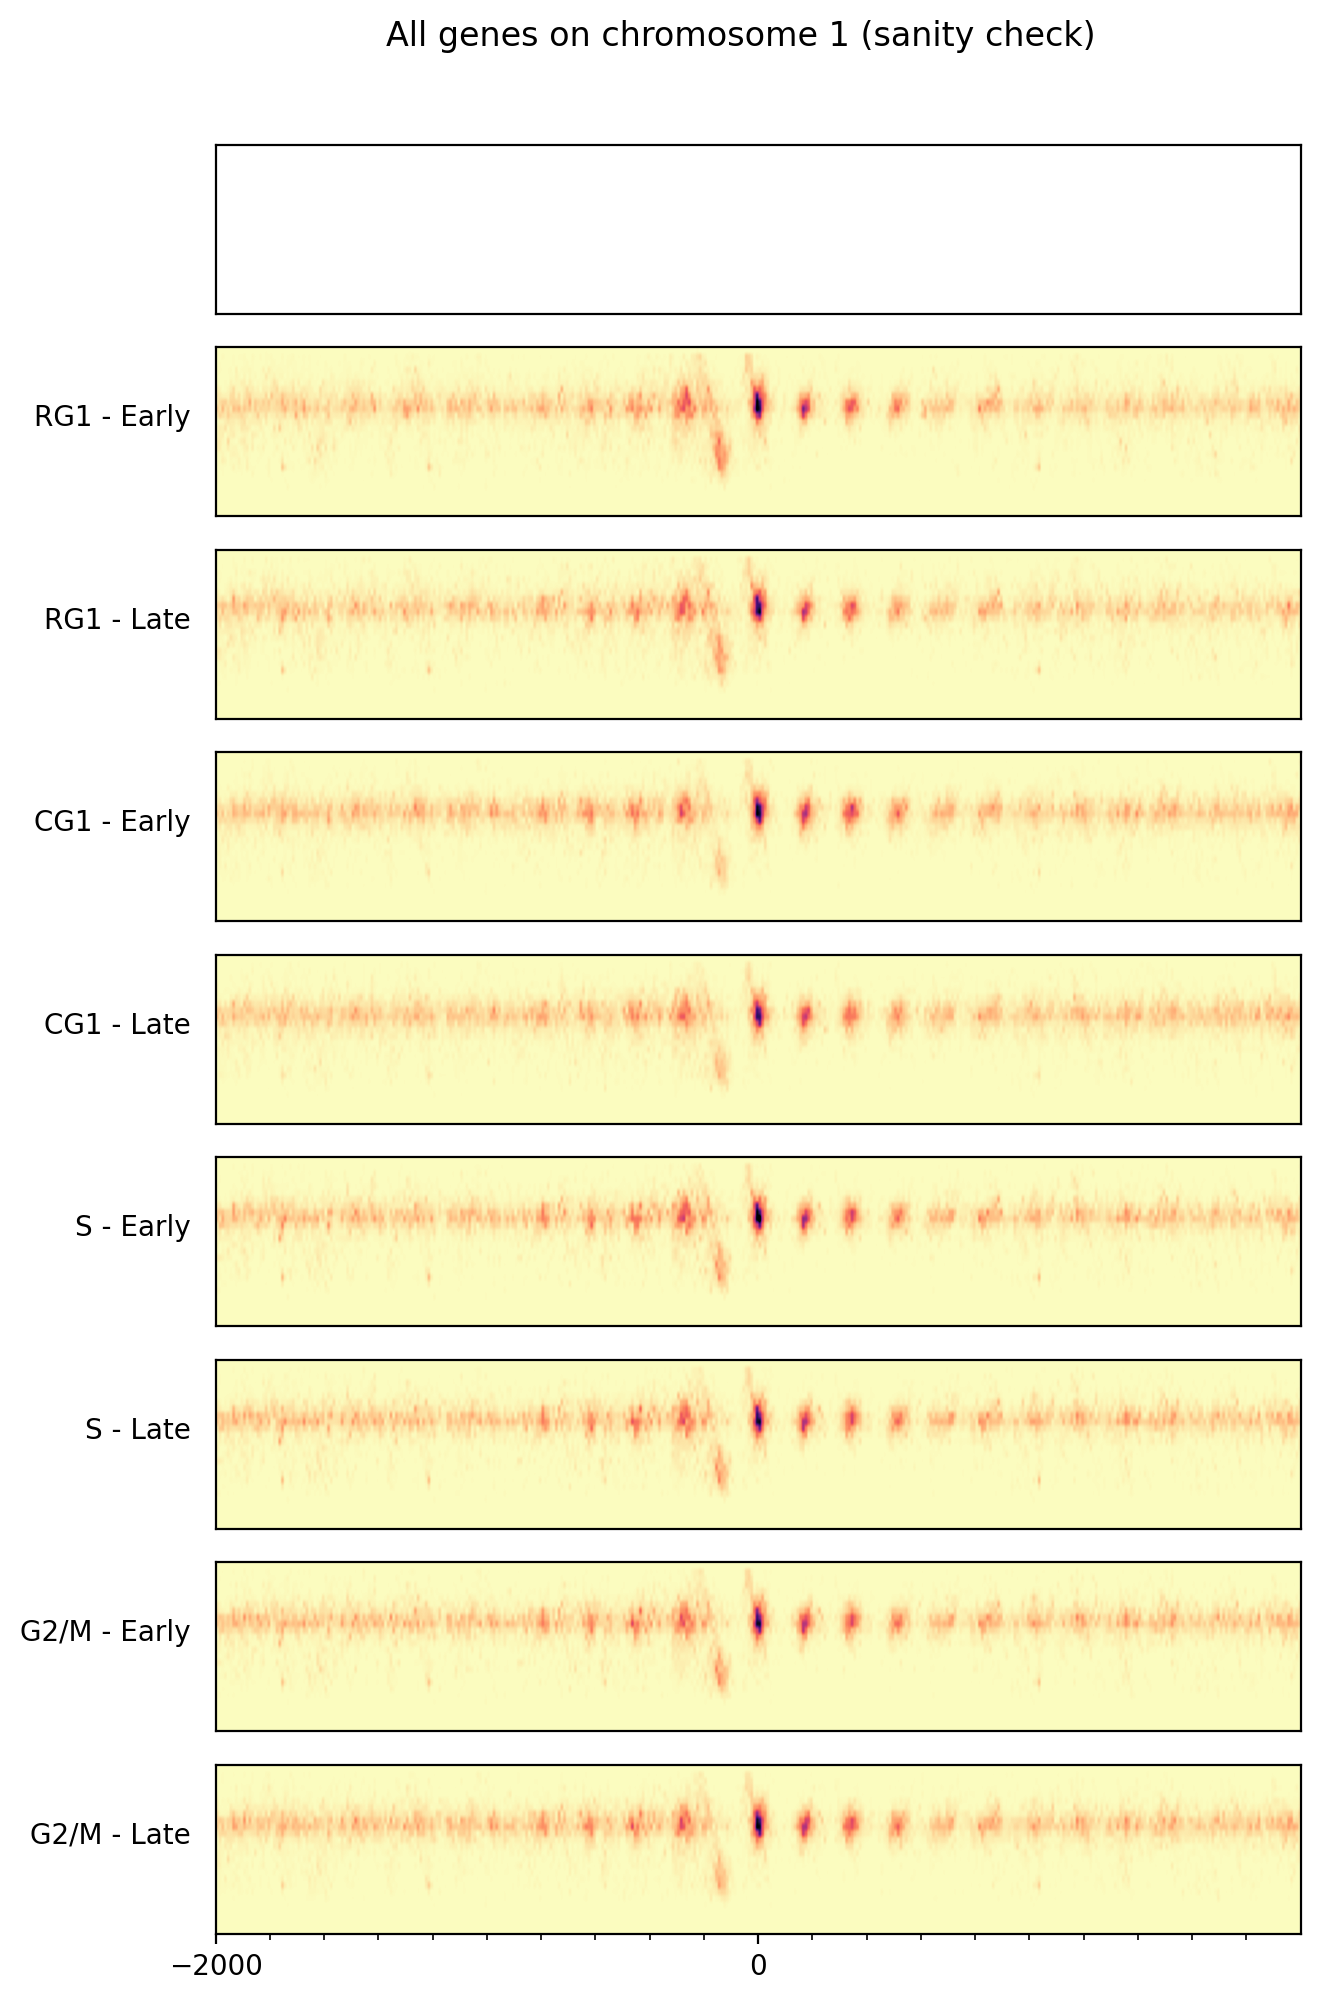

In [6]:
padding = 2000
fig = analysis.plot_deconvolved_result(mean_loaded_genes, (-padding, padding), 
    normalize=True)
plt.suptitle("All genes on chromosome 1 (sanity check)")

In [15]:
from src.reference_data import load_h3k56ac_marks

nuc_h3k56ac_table = load_h3k56ac_marks()
genes_h3k56ac = nuc_h3k56ac_table.loc[~nuc_h3k56ac_table.acc.isna()]
genes_h3k56ac = genes_h3k56ac[['mean_acetylation', 'acc']].groupby('acc').mean()
genes_h3k56ac = genes_h3k56ac.join(genes[['chr', 'strand', 'TSS']], how='inner')

top_acetylation = genes_h3k56ac.tail(200)
bottom_acetylation = genes_h3k56ac.head(200)

In [16]:
mean_imgs_top_acetyl_genes = load_stacked_mnase_data_for_genes(top_acetylation)
mean_imgs_bottom_acetyl_genes = load_stacked_mnase_data_for_genes(bottom_acetylation)

Failed to load 3 files


Text(0.5, 0.98, 'Top H3K56 acetylation genes')

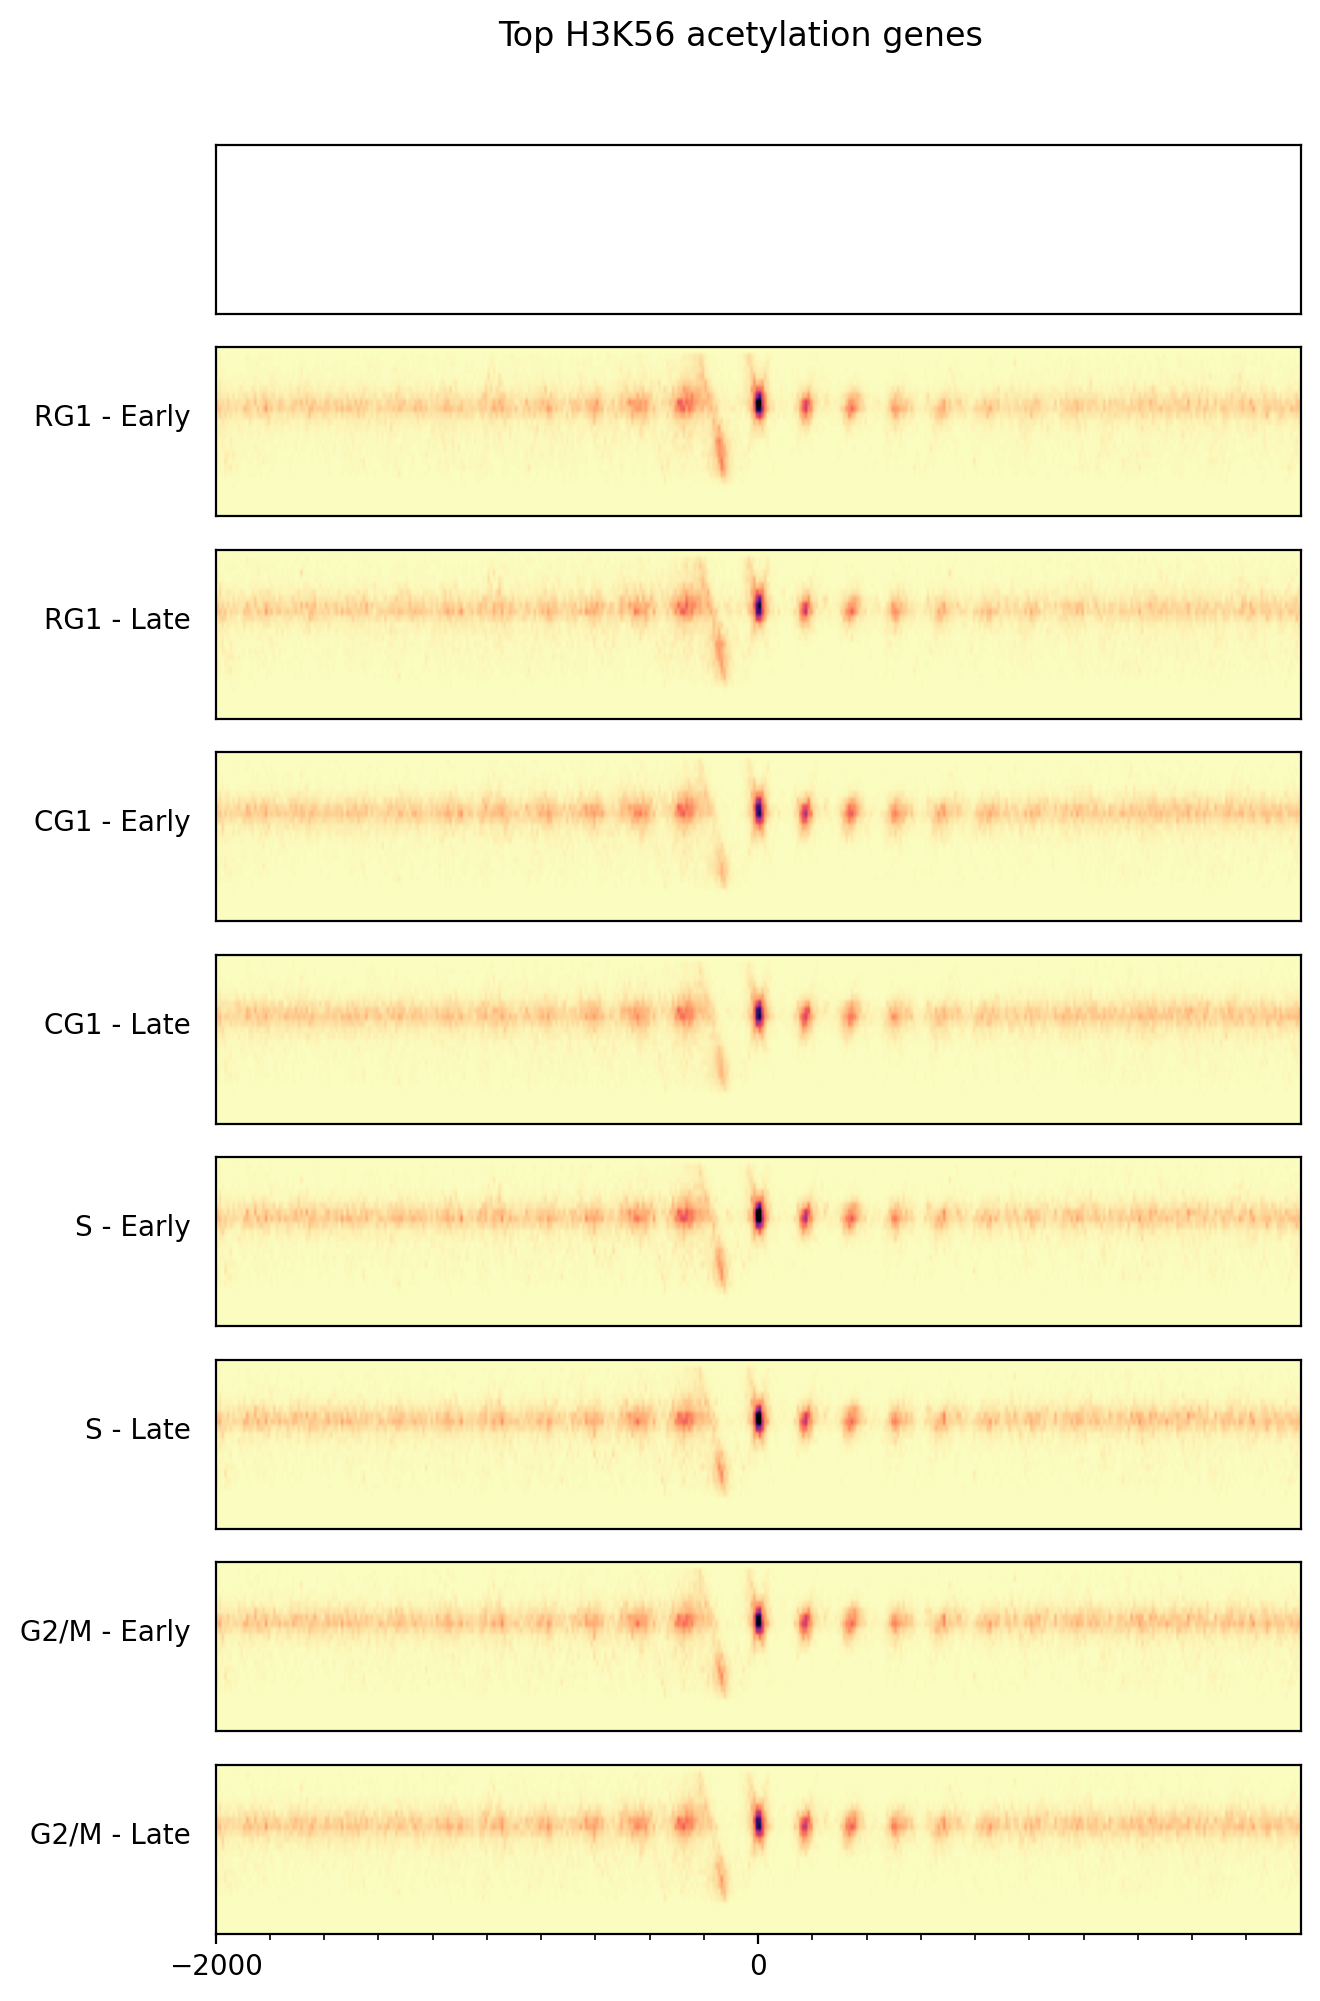

In [31]:
fig = analysis.plot_deconvolved_result(mean_imgs_top_acetyl_genes, (-padding, padding), 
    normalize=True)
plt.suptitle("Top H3K56 acetylation genes")

Text(0.5, 0.98, 'Bottom H3K56 acetylation genes')

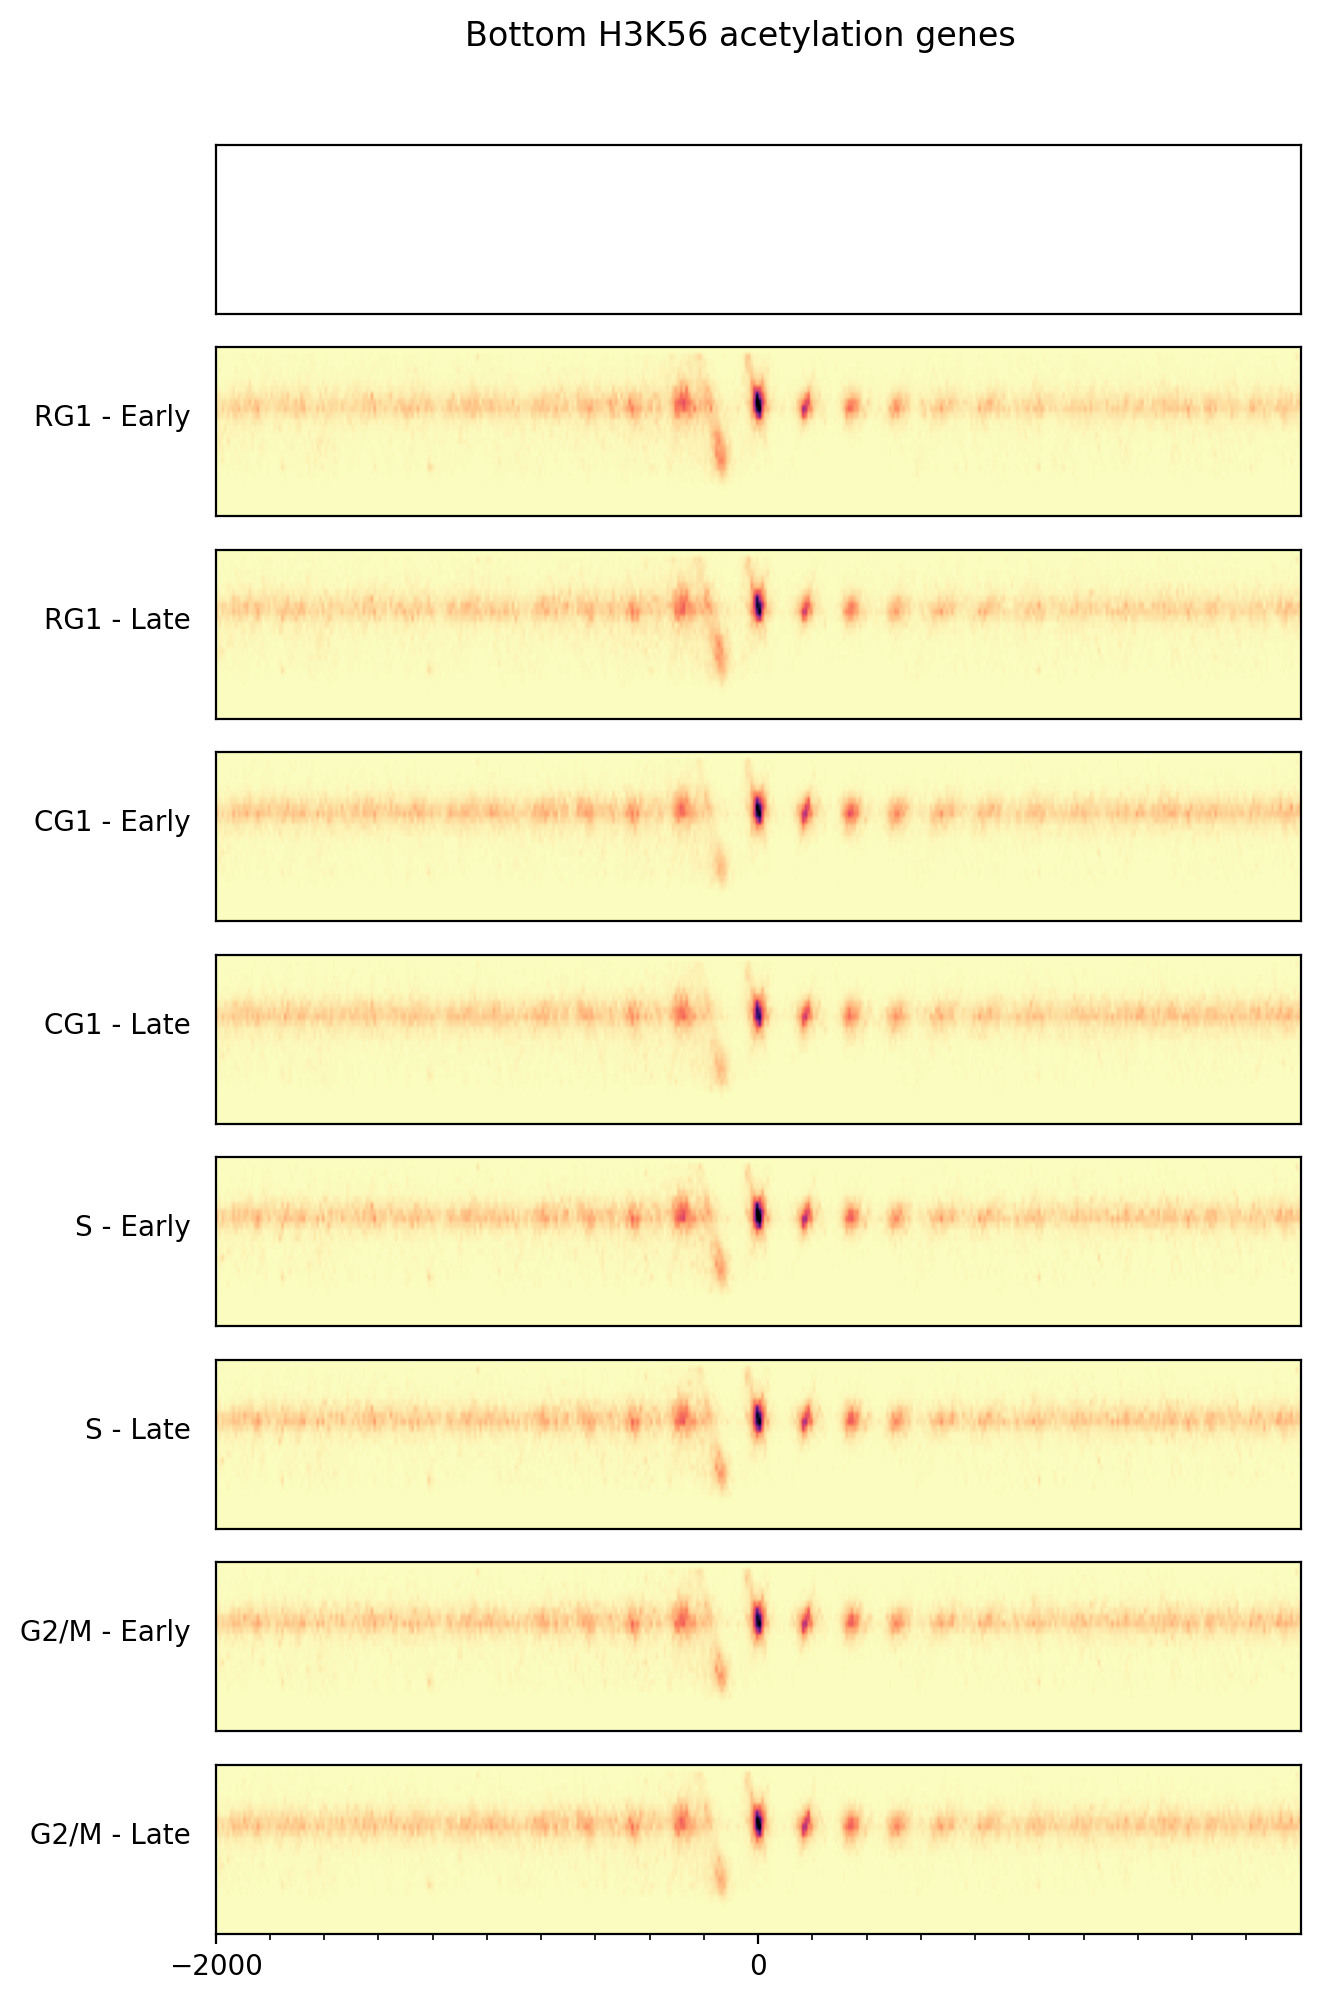

In [32]:
fig = analysis.plot_deconvolved_result(mean_imgs_bottom_acetyl_genes, (-padding, padding), 
    normalize=True)
plt.suptitle("Bottom H3K56 acetylation genes")

In [350]:
# Criteria to identify buffering genes:
# 1. High maximal expression - to remove genes that are generally off for the 
#    entirety of the time course. (And both steady state and genes with a high and 
#    low expression are can be identified as buffering)
#
# 2. Anti-correlated expression with copy number
#

from src.gene_clustering import GeneClustering
outdir = 'output/deconvolve_sharedg1_g0066_11x11_2024_08_13/'
gene_clustering = GeneClustering(outdir)
gene_clustering.set_max_expression_threshold()


Genes with maximal expression for quantile: 0.5
is set at 10.58 expression level. 2789 genes meet this criteria


In [43]:
from src.copy_correction_reanalysis import CopyCorrectionAnalysis

copy_analysis = CopyCorrectionAnalysis()

1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 00:02:18.996
1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 00:02:30.566


In [44]:
copy_analysis.set_replicate(1)

In [348]:
from scipy.stats import pearsonr
from src.CopyNumberCorrection import get_bin_for_position
from src.geneset import get_deconvolved_geneset
from src.config import read_yl_vst_data_rep

raw_gene_expression_replicate_1 = read_yl_vst_data_rep(1)

def compute_gene_copy_num_correlation(gene):
    """Compute the correlation of the gene expression to copy number
    for a gene"""
    start_indices = copy_analysis.chrom_replication_profile.loc[gene.chr].index
    repl_bin, start_ind = get_bin_for_position(gene.TSS, start_indices)
    
    expression_curve = raw_gene_expression_replicate_1.loc[gene.name]    
    repl_curve = copy_analysis.chrom_bin_curves.loc[gene.chr].loc[start_ind]
    pearson, pval = pearsonr(expression_curve, repl_curve)
    return pearson, pval

gene_tx_copy_num_correlation = genes[[]].copy()
for orf_name, gene in genes.iterrows():
    pearson, pval = compute_gene_copy_num_correlation(gene)
    gene_tx_copy_num_correlation.loc[orf_name, 'pearson'] = pearson
    gene_tx_copy_num_correlation.loc[orf_name, 'pval'] = pval


/Users/trung/opt/anaconda3/envs/cell-cycle-deconvolution/lib/python3.8/site-packages/scipy/stats/_stats_py.py:4424: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))


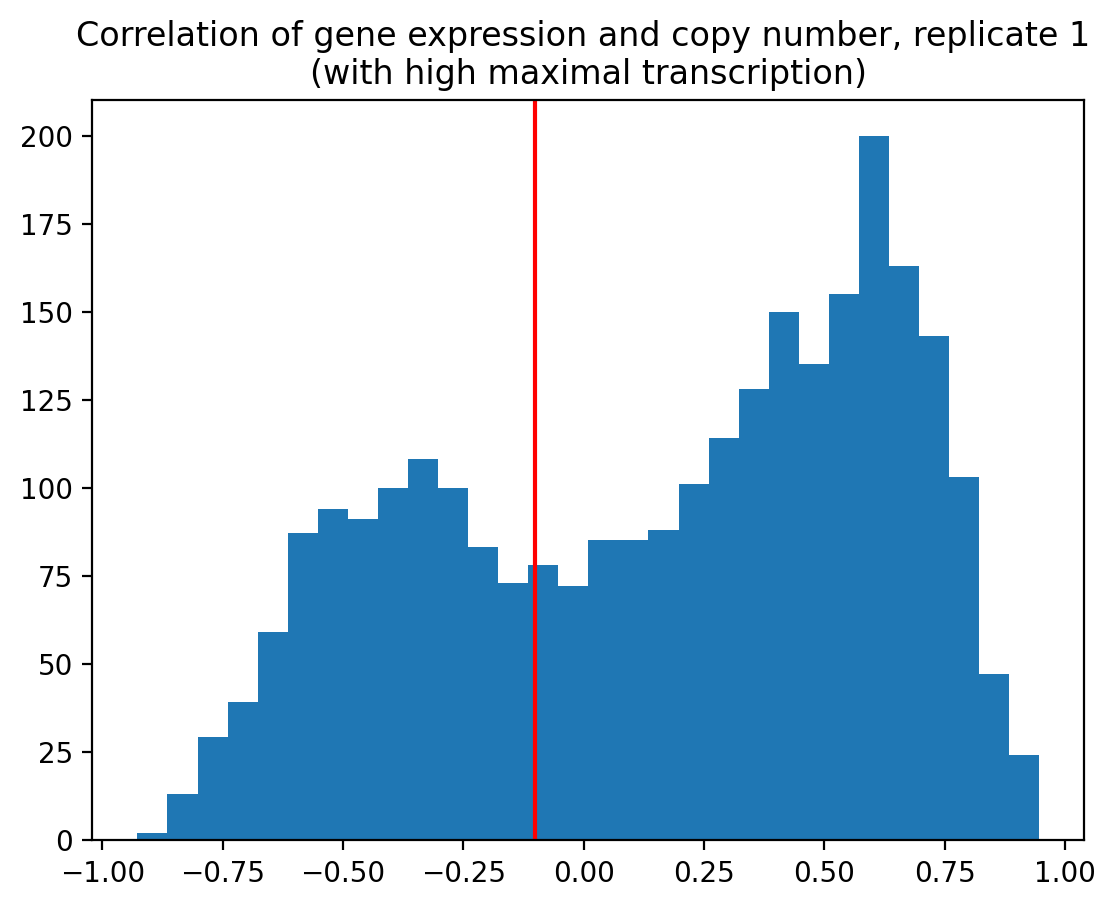

In [352]:
gene_repl_tx_corr_nona = gene_tx_copy_num_correlation.loc[gene_clustering\
    .high_max_expression_genes].dropna()
gene_repl_tx_corr_rank = gene_repl_tx_corr_nona.join(genes[['gene']], 
   how='inner').sort_values('pearson', ascending=False)
gene_repl_tx_corr_rank['rank'] = np.arange(1, len(gene_repl_tx_corr_rank)+1)

plt.hist(gene_repl_tx_corr_rank.pearson, bins=30)
plt.title("Correlation of gene expression and copy number, replicate 1 \n"
          "(with high maximal transcription)")

threshold_correlation = -0.1
plt.axvline(threshold_correlation, c='red')

# Genes with low correlation with copy number may be buffered
potentially_buffered_genes = gene_repl_tx_corr_rank[\
    gene_repl_tx_corr_rank.pearson < threshold_correlation]

In [380]:
print(f"Gene's with a thresholded level of maximal transcription: {len(gene_repl_tx_corr_rank)}"
      f"\nGenes anti-correlated to copy number: {len(potentially_buffered_genes)}")

Gene's with a thresholded level of maximal transcription: 2749
Genes anti-correlated to copy number: 902


In [362]:
mean_imgs_potential_buffering = load_stacked_mnase_data_for_genes(potentially_buffered_genes)

Text(0.5, 0.98, 'Potentially buffered genes, n=178')

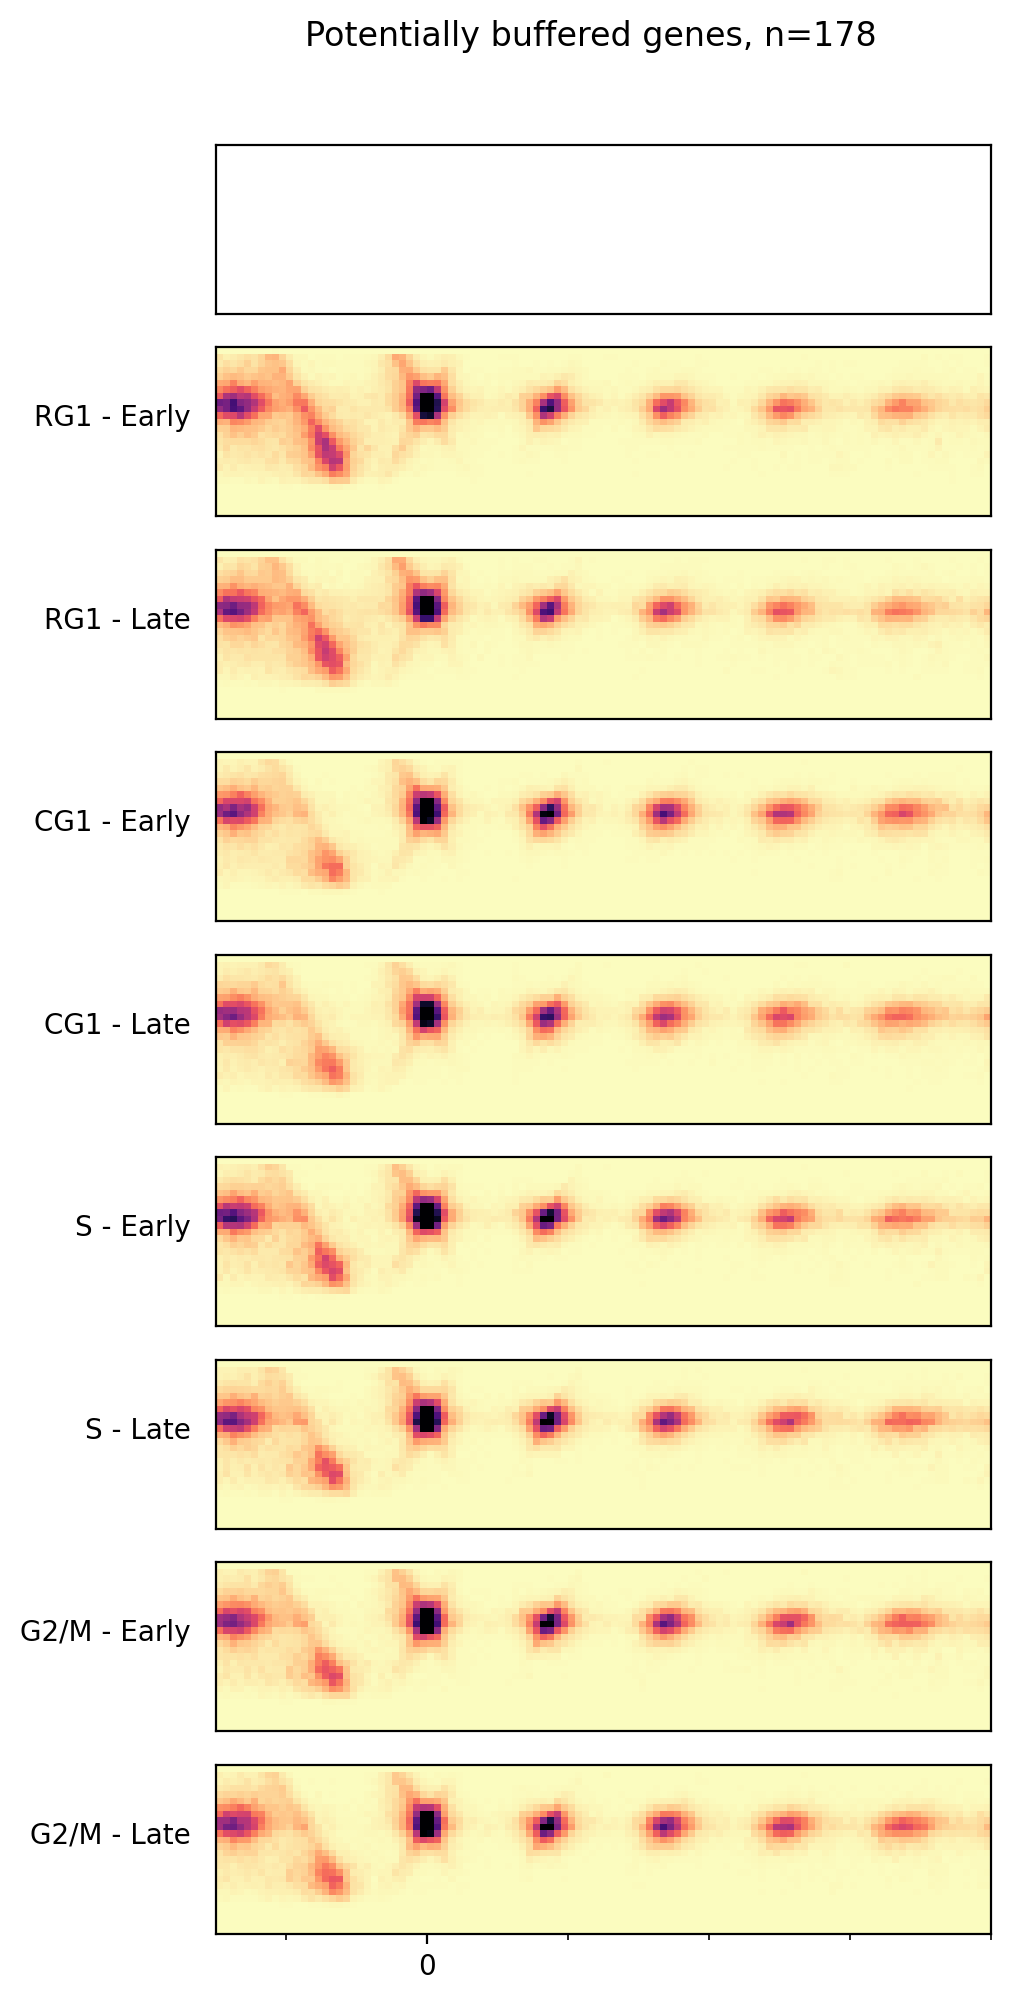

In [364]:
fig = analysis.plot_deconvolved_result(mean_imgs_potential_buffering, (-padding, padding), 
    normalize=True)
plt.suptitle(f"Potentially buffered genes, n={len(mean_imgs_potential_buffering)}")

# No chromatin evidence of buffering in this set of 900 genes

In [365]:
buffered_expression = raw_gene_expression_replicate_1.loc[potentially_buffered_genes.index]

normalized_buffered_expression = buffered_expression -\
    buffered_expression.mean(axis=1).values.reshape((-1, 1))

In [366]:
from src.gene_clustering import GeneClustering

outdir = 'output/deconvolve_sharedg1_g0066_11x11_2024_08_13/chromatin/'
gene_clustering = GeneClustering(outdir)

In [367]:
gene_clustering.set_gene_expression_to_cluster(normalized_buffered_expression)

In [368]:
gene_clustering.compute_distance_from_gene_expression()

0/902 - 00:00:00.033
100/902 - 00:00:02.348
200/902 - 00:00:04.288
300/902 - 00:00:05.915
400/902 - 00:00:07.298
500/902 - 00:00:08.421
600/902 - 00:00:09.301
700/902 - 00:00:09.924
800/902 - 00:00:10.309
900/902 - 00:00:10.439
00:00:10.439


In [369]:
gene_clustering.cluster_expression(5)

Text(0.5, 1.0, 'Clustered non-copy # correlated genes')

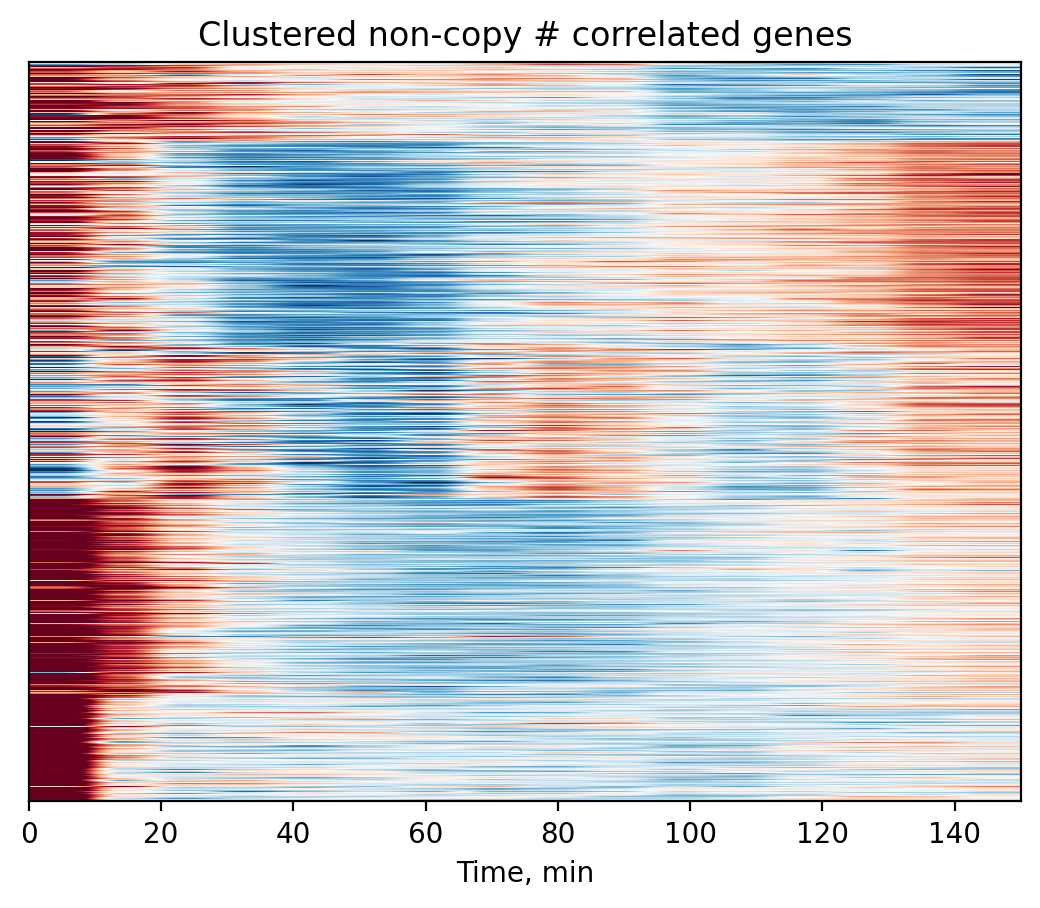

In [375]:
genes_sorted_by_cluster = gene_clustering.clustered_expression.sort_index()

plt.imshow(genes_sorted_by_cluster, 
    aspect='auto', cmap='RdBu_r', vmin=-2, vmax=2,
          extent=[buffered_expression.columns[0], buffered_expression.columns[-1], 0,
                 len(genes_sorted_by_cluster)])
plt.xlabel("Time, min")
plt.yticks([])
plt.title("Clustered non-copy # correlated genes")

Cluster 1
   23 ORFS with acetylation greater than 1
Cluster 2
   79 ORFS with acetylation greater than 1
Cluster 3
   12 ORFS with acetylation greater than 1
Cluster 4
   80 ORFS with acetylation greater than 1
Cluster 5
   25 ORFS with acetylation greater than 1


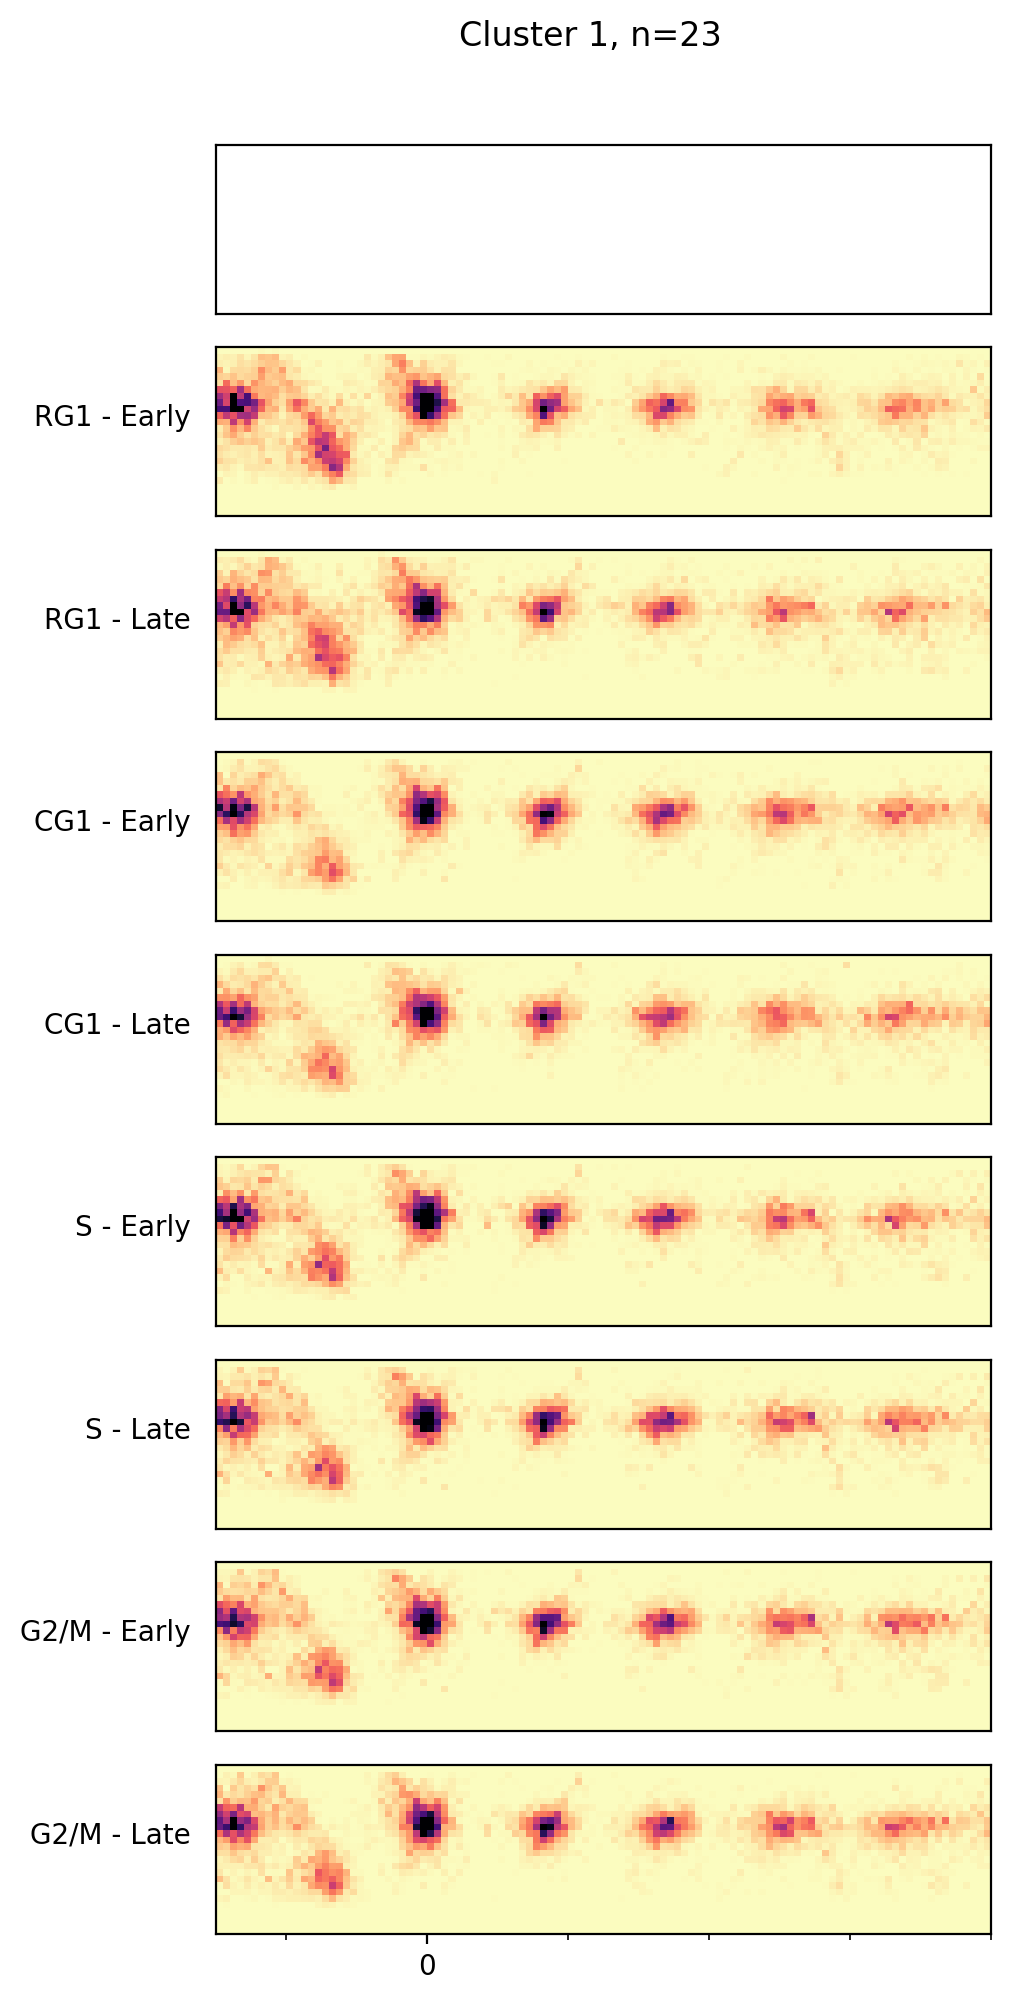

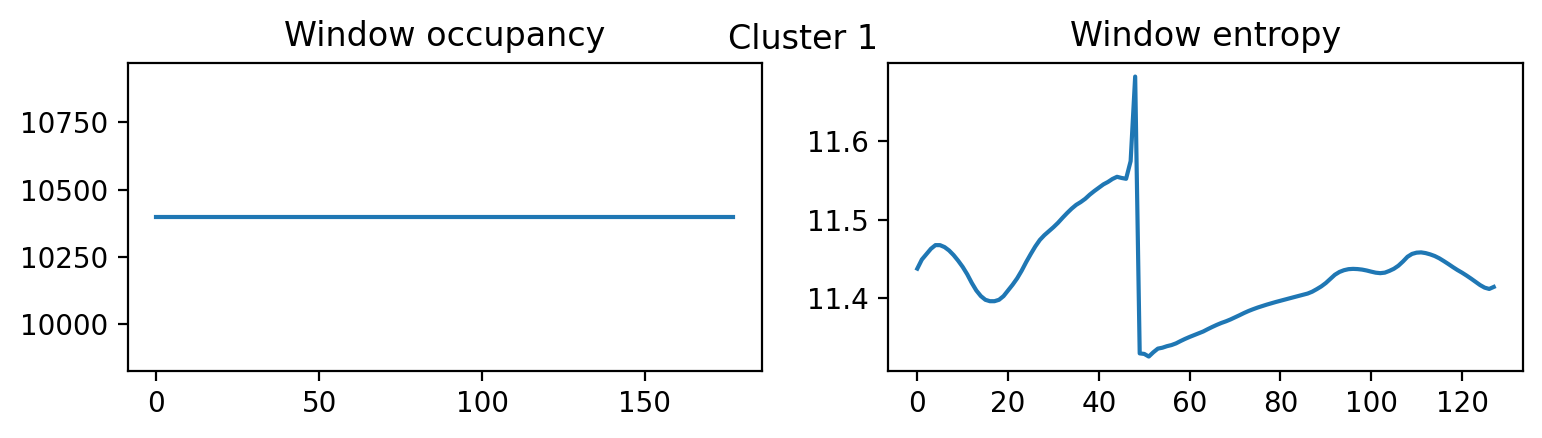

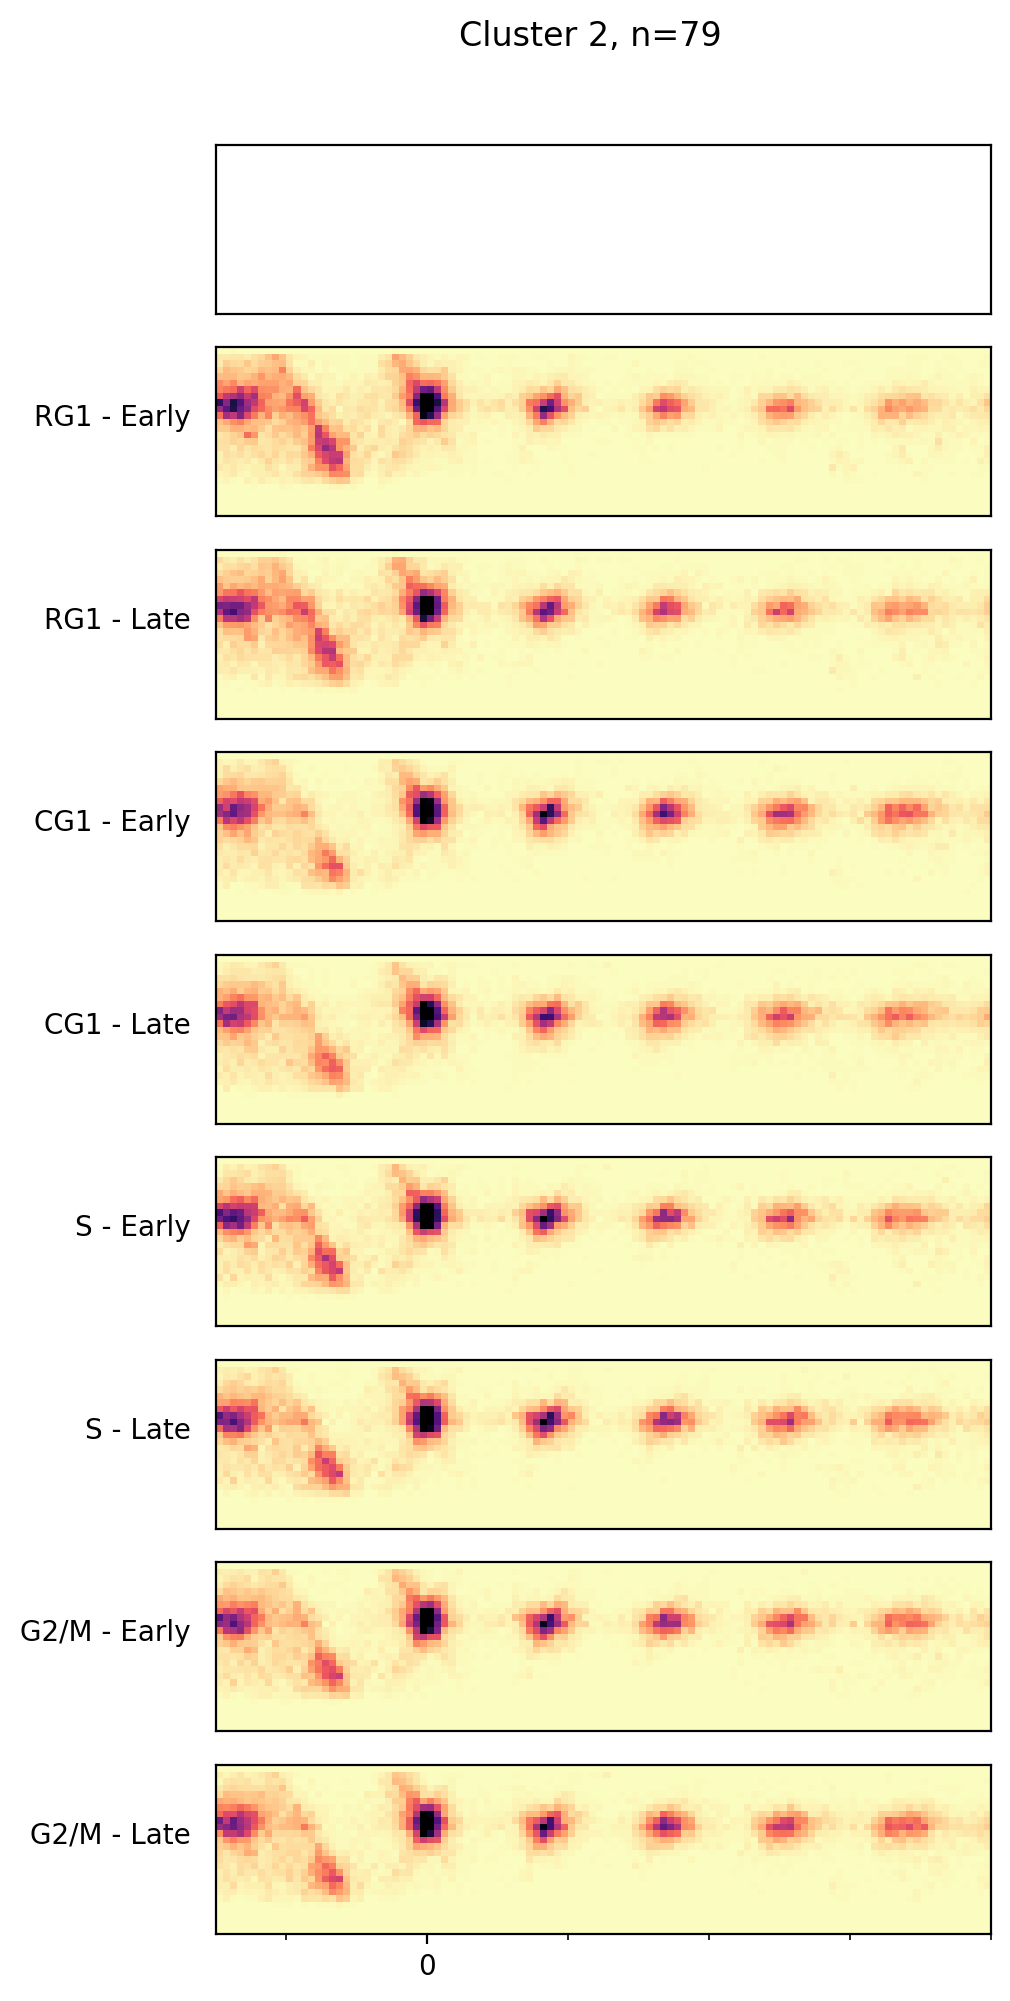

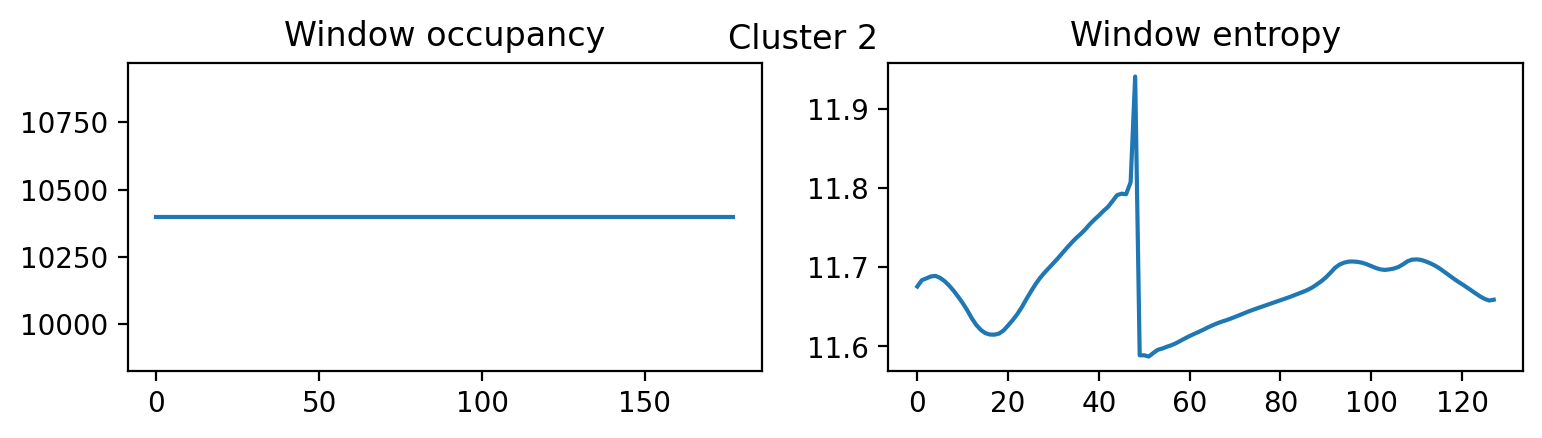

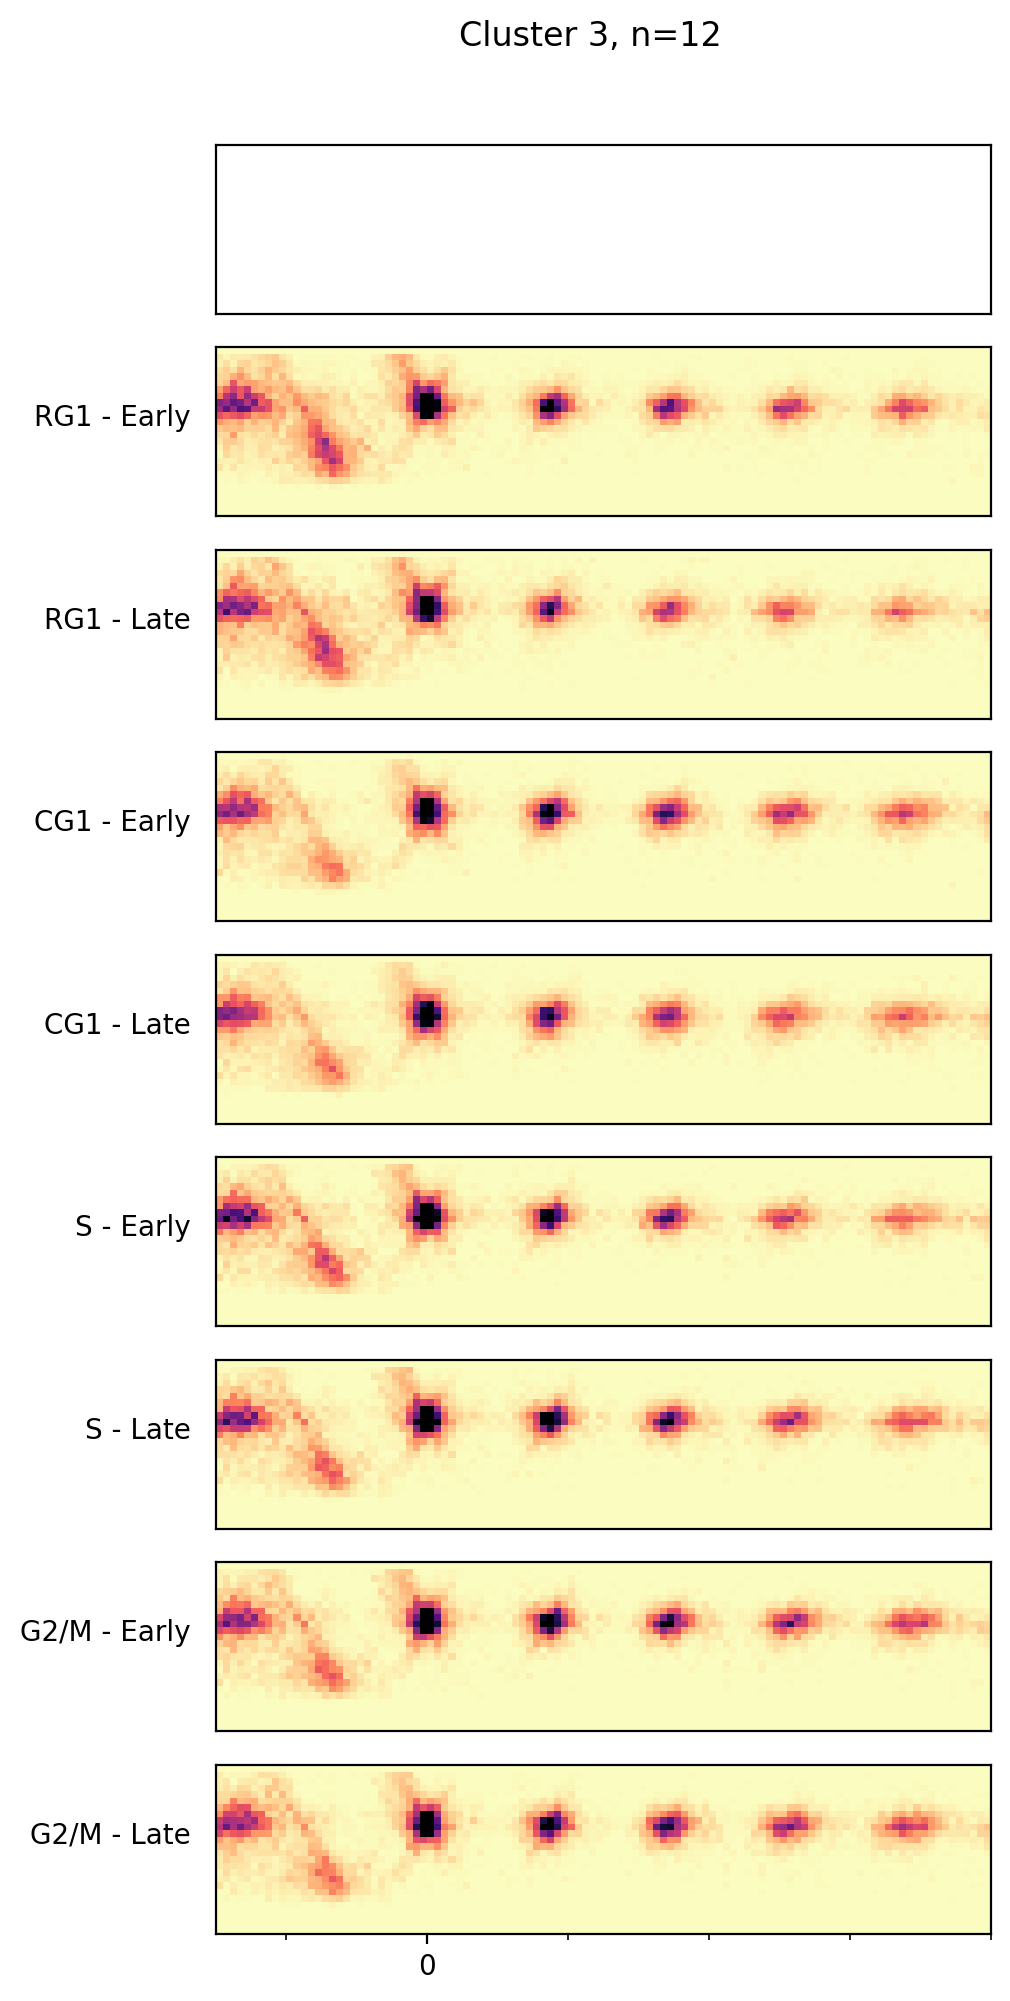

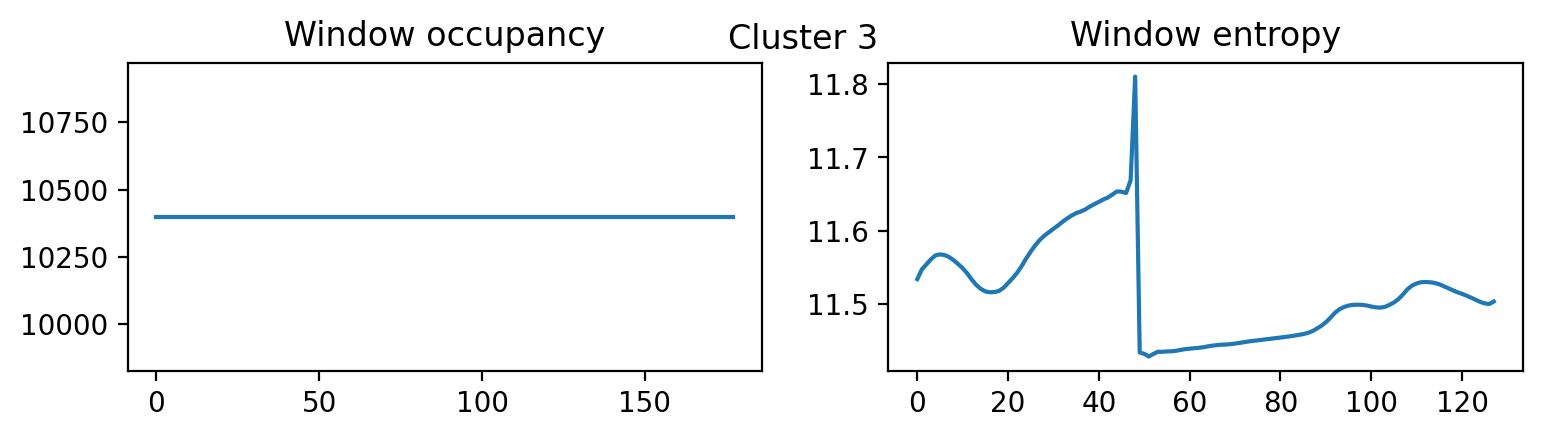

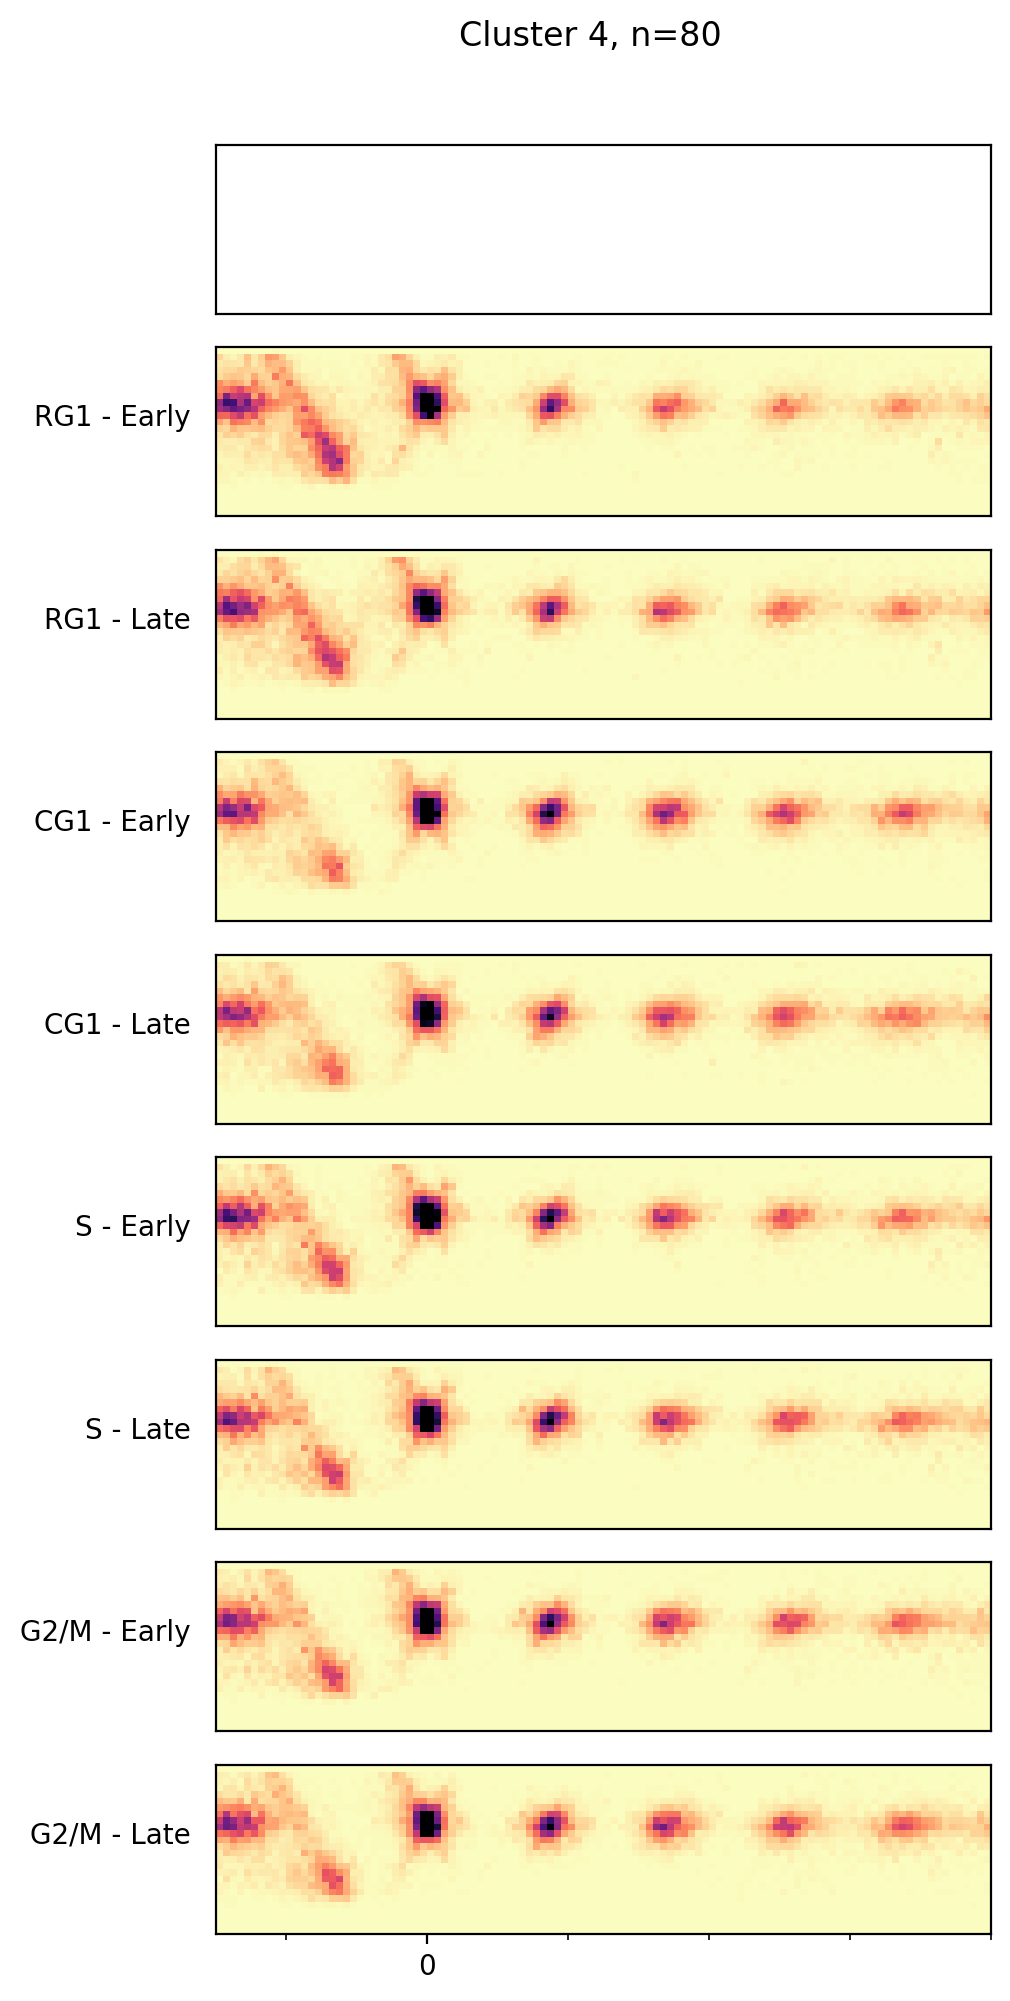

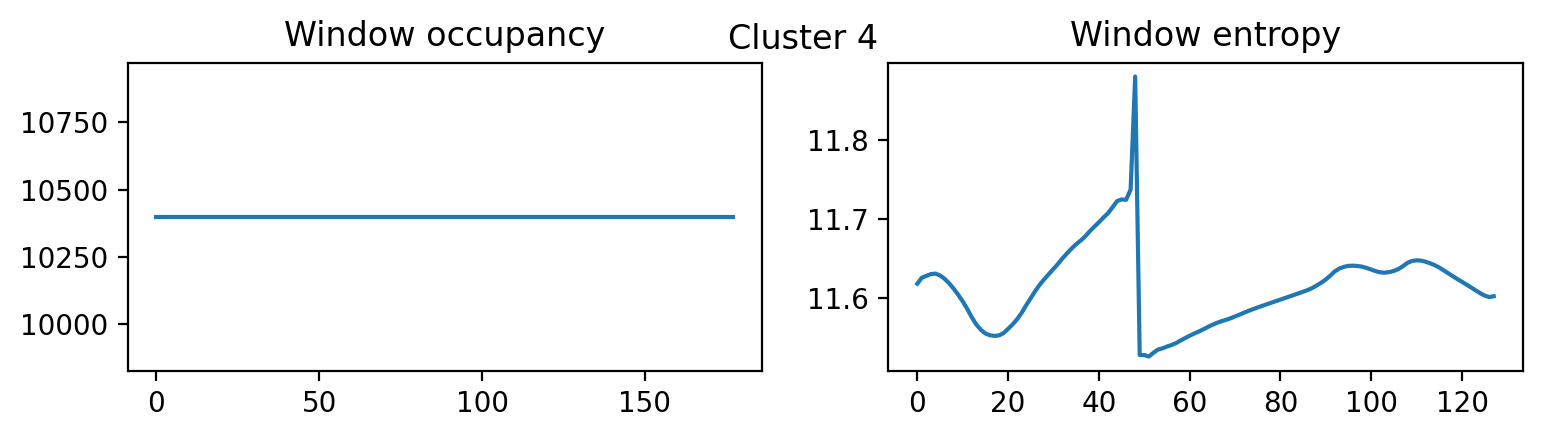

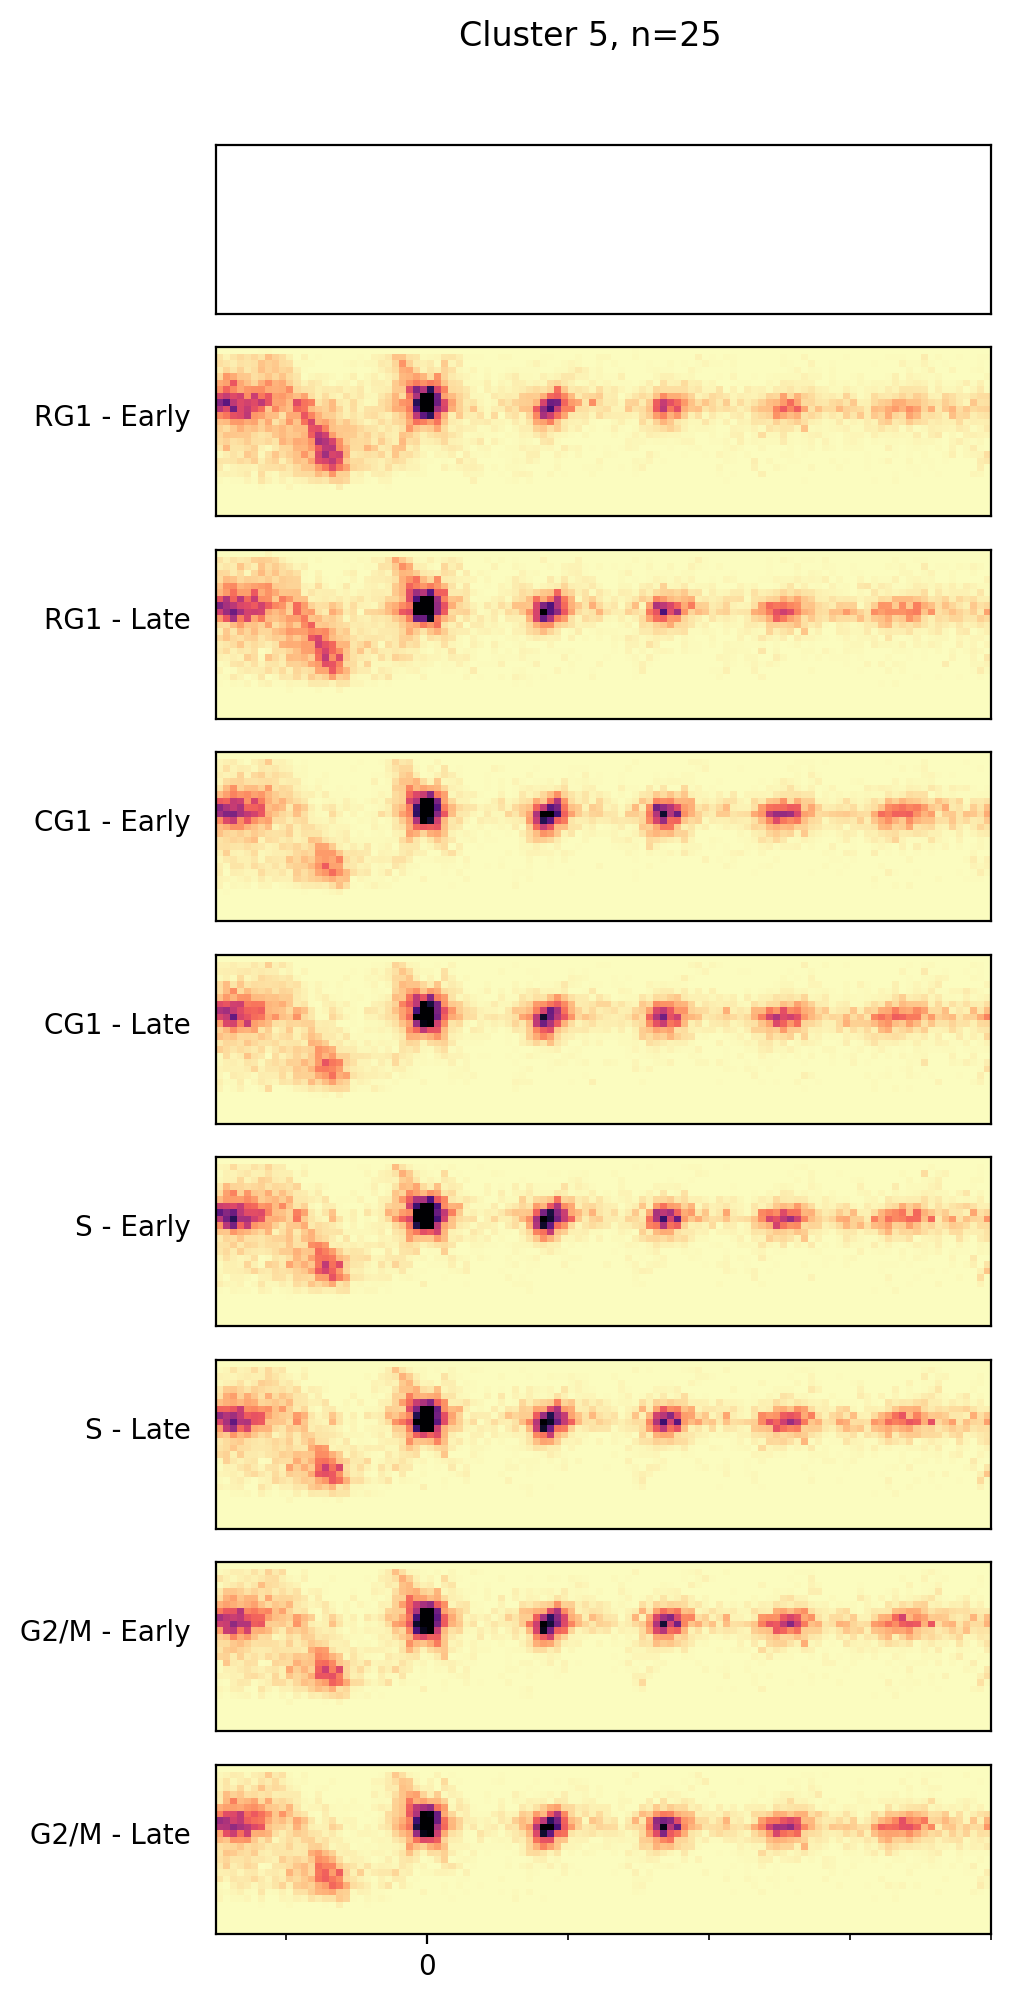

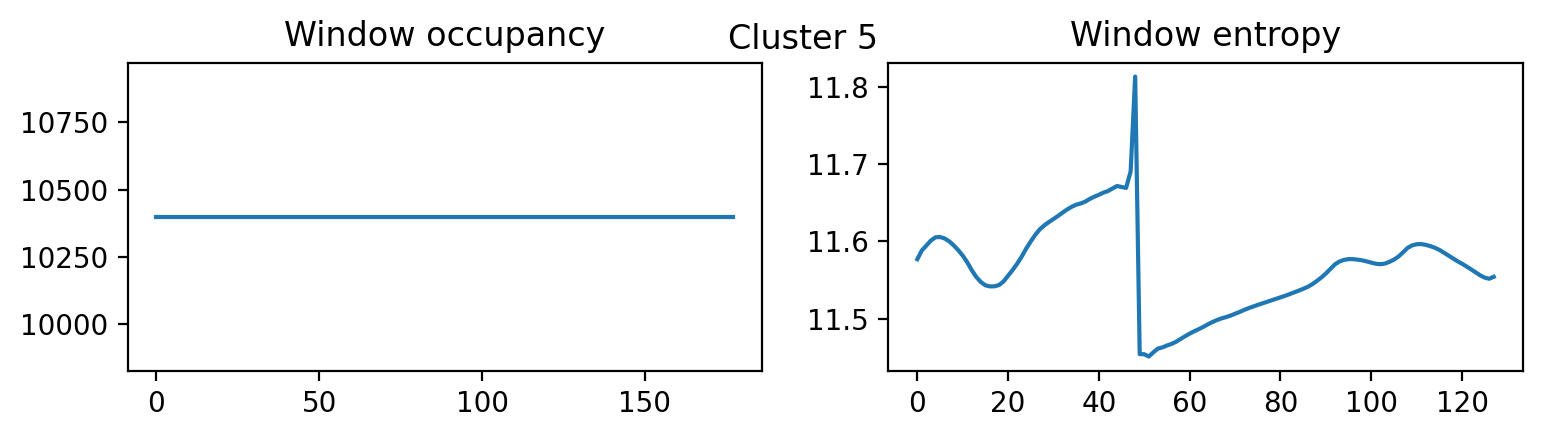

In [376]:
for cluster in range(1, 6):
    
    print(f"Cluster {cluster}")
    
    cluster_geneset = genes_sorted_by_cluster.loc[cluster][[]]

    cluster_orfs_h3k56ac = list(set(cluster_geneset.index.values)\
        .intersection(set(nuc_h3k56ac_table.acc)))
    cluster_acetl_values = nuc_h3k56ac_table.set_index('acc').loc[cluster_orfs_h3k56ac]
    
    # How many above 1?
    threshold_val = 1
    thresholded_orfs = cluster_acetl_values[\
        cluster_acetl_values.mean_acetylation > 1]
    print(f"   {len(thresholded_orfs)} ORFS with acetylation greater than {threshold_val}")
    
    mean_imgs = load_stacked_mnase_data_for_genes(cluster_geneset)
    
    fig = analysis.plot_deconvolved_result(mean_imgs, (-padding, padding), 
        normalize=True)
    plt.suptitle(f"Cluster {cluster}, n={len(thresholded_orfs)}")
    
    from src.helpers import calc_entropy

    # Calculate the occupancy and the entropy
    normalized_mean_imgs = mean_imgs / mean_imgs.mean(axis=1).mean(axis=1).reshape((-1, 1, 1))
    gene_body_occupancy = normalized_mean_imgs[:, :, :].reshape((mean_imgs.shape[0], -1))
    entropy_values = np.zeros(gene_body_occupancy.shape[0])
    for i in range(gene_body_occupancy.shape[0]):
        entropy_values[i] = calc_entropy(gene_body_occupancy[i])

    plt.figure(figsize=(9, 2))
    plt.subplot(1, 2, 1)
    plt.plot(gene_body_occupancy.sum(axis=1))
    plt.title("Window occupancy")
    plt.subplot(1, 2, 2)
    plt.plot(entropy_values[t_indices])
    plt.title("Window entropy")
    plt.suptitle(f"Cluster {cluster}")


In [ ]:
# The entropy dramatically falls right at the start of S phase...
#      If this is true, this could indicate a replication effect of early replicating
#      disorganization... 
#      And this is happening in the entire window not just the gene body...
#
#      We have a result like this previously discovered... 
#      Does this occur for each cluster? Do we need to control for expression
# 

In [407]:
# Control for early replicating and late replicating first,
# if that is indeed the largest driving signal in the chromatin.... even though
# it isn't visually obvious (probably because the early and late replicating genes
# are mixed into each other)
mean_imgs_potential_buffering_PAS = analysis.load_stacked_mnase_data_for_genes(
    potentially_buffered_genes, center_mode='PAS_nuc')


Text(0.5, 0.98, 'PAS of acetylated buffering genes')

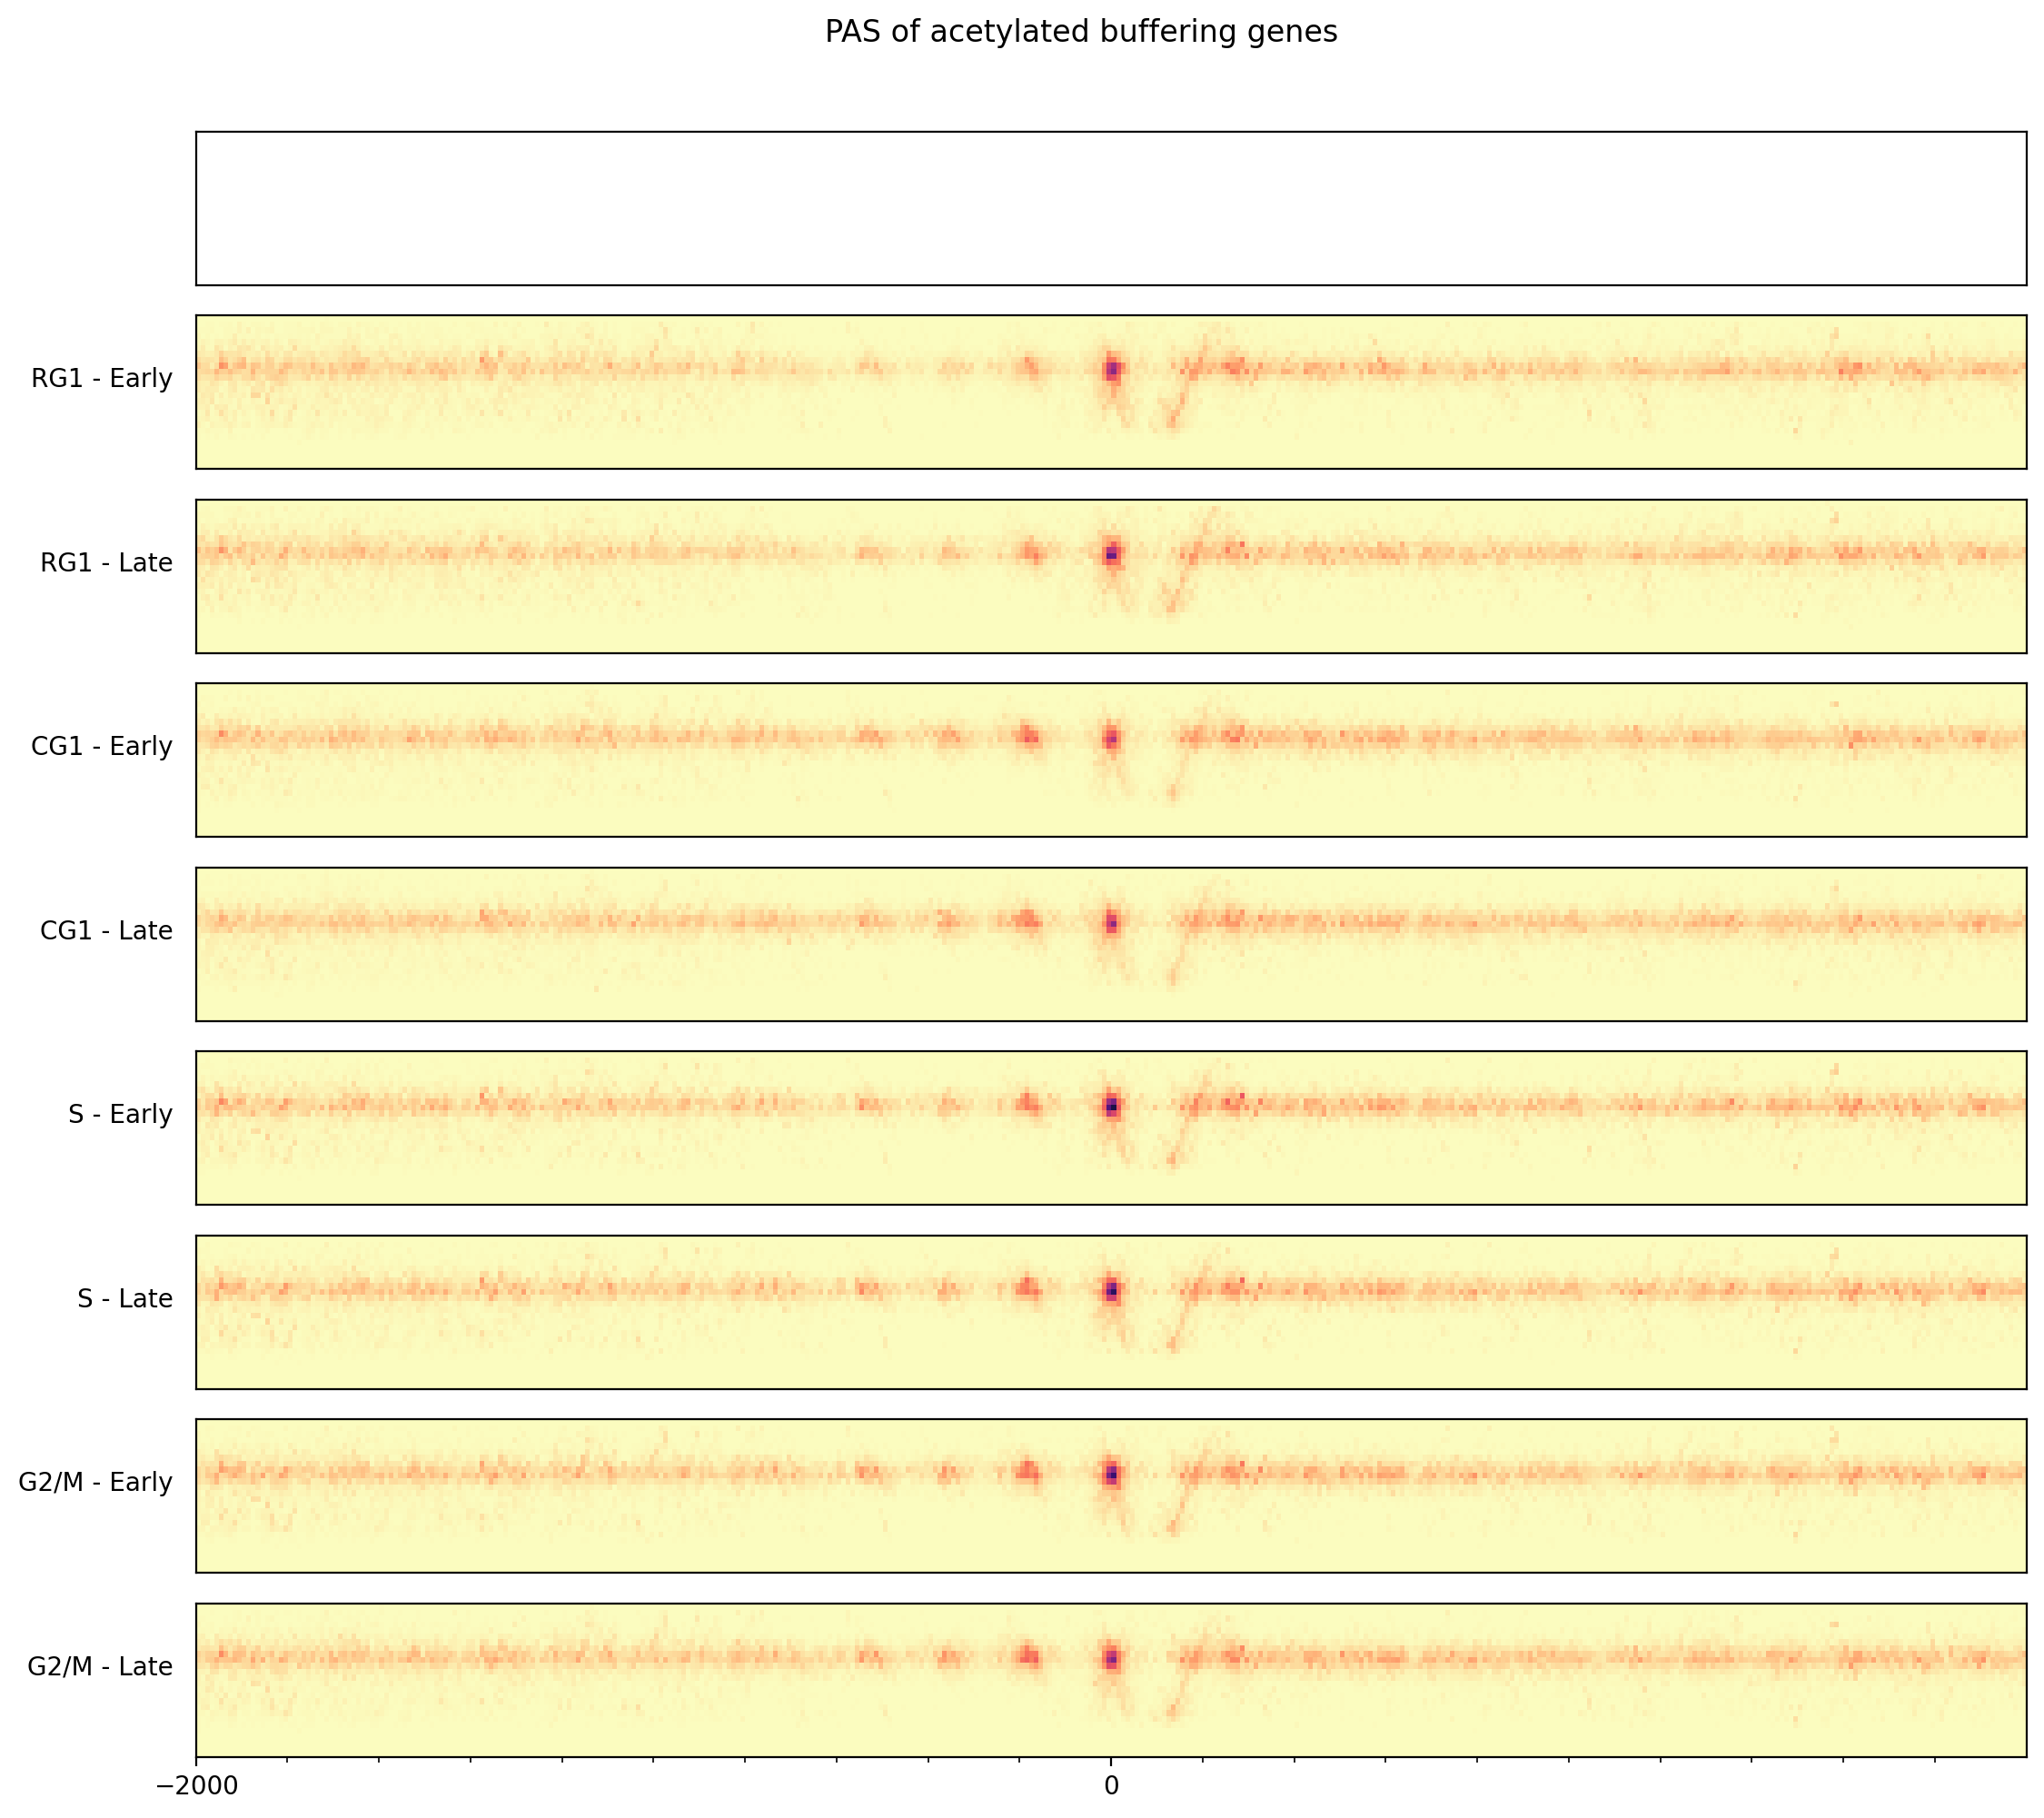

In [430]:
buffered_orfs_h3k56ac = list(set(potentially_buffered_genes.index.values)\
    .intersection(set(nuc_h3k56ac_table.acc)))
buffered_ac_vals_h3k56ac = nuc_h3k56ac_table.set_index('acc').loc[buffered_orfs_h3k56ac]
selected_orfs = buffered_ac_vals_h3k56ac[buffered_ac_vals_h3k56ac.mean_acetylation > 1].index

buffered_genes_w_acet_PAS = analysis.load_stacked_mnase_data_for_genes(
   potentially_buffered_genes.loc[selected_orfs], center_mode='PAS_nuc')

padding = 2000
fig = analysis.plot_deconvolved_result(buffered_genes_w_acet_PAS, (-padding, padding), 
    normalize=True)
plt.suptitle("PAS of acetylated buffering genes")


Text(0.5, 0.98, 'PAS of buffering genes')

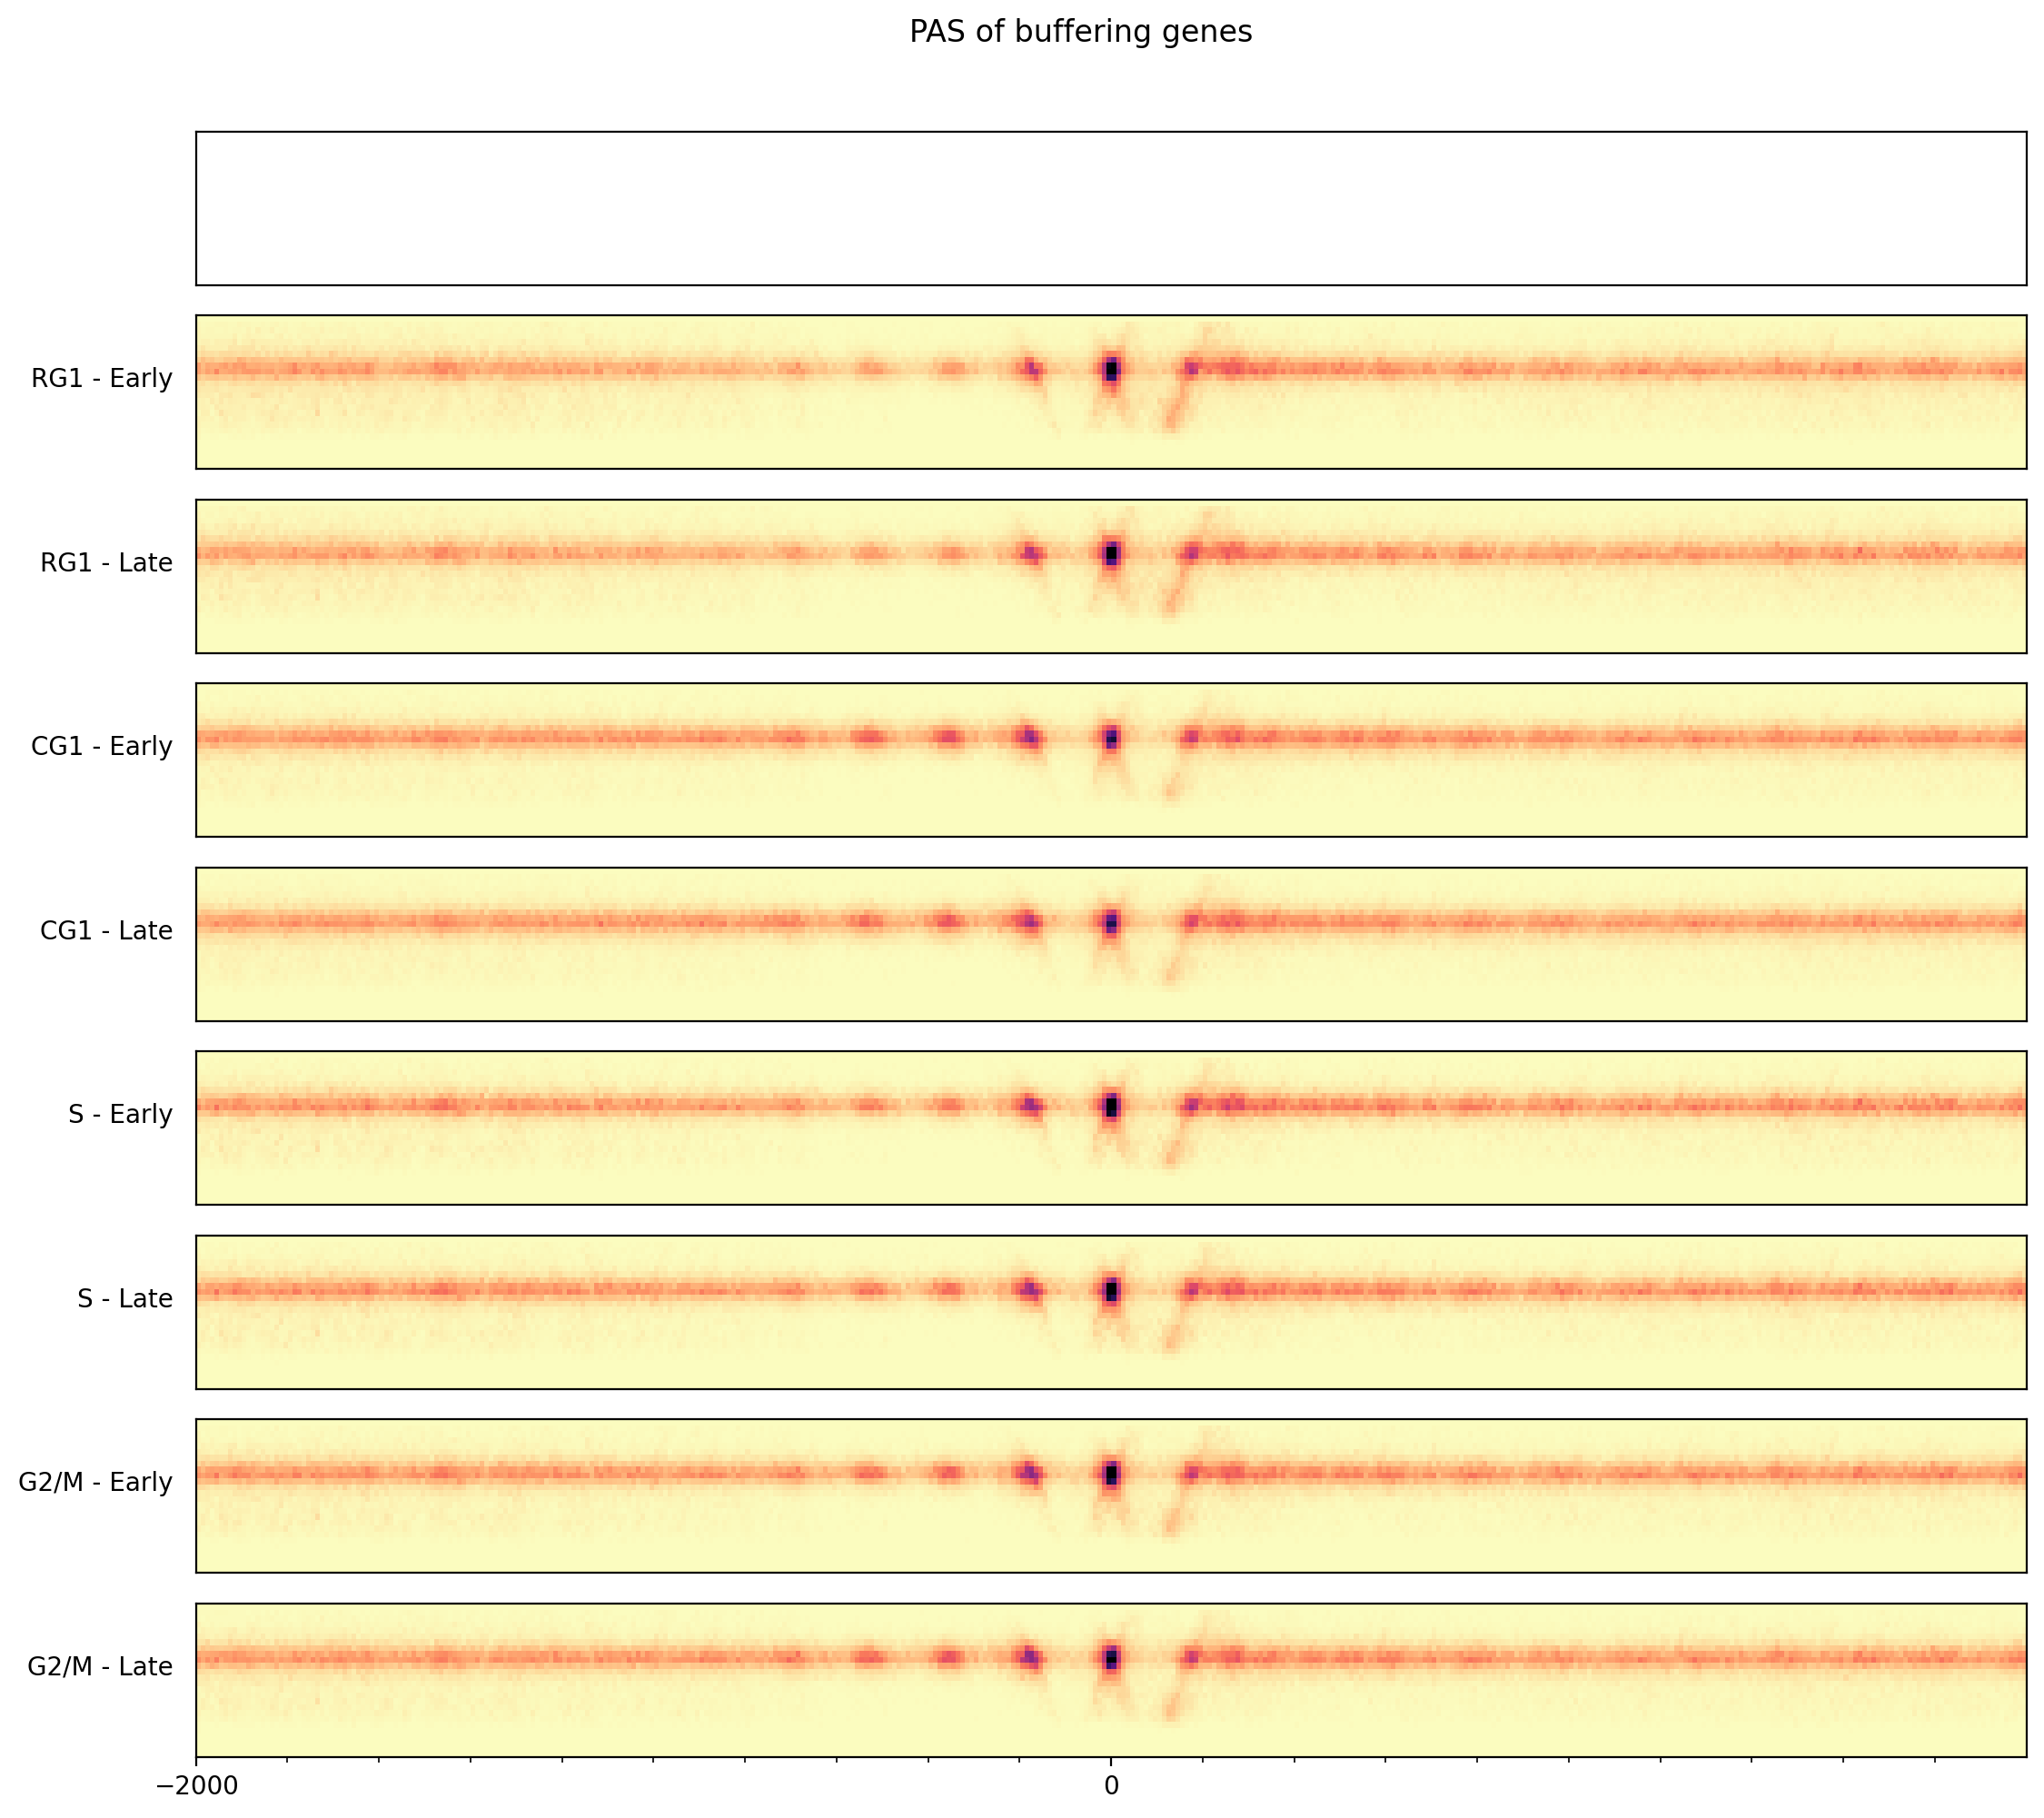

In [409]:
padding = 2000
fig = analysis.plot_deconvolved_result(mean_imgs_potential_buffering_PAS, (-padding, padding), 
    normalize=True)
plt.suptitle("PAS of buffering genes")


0

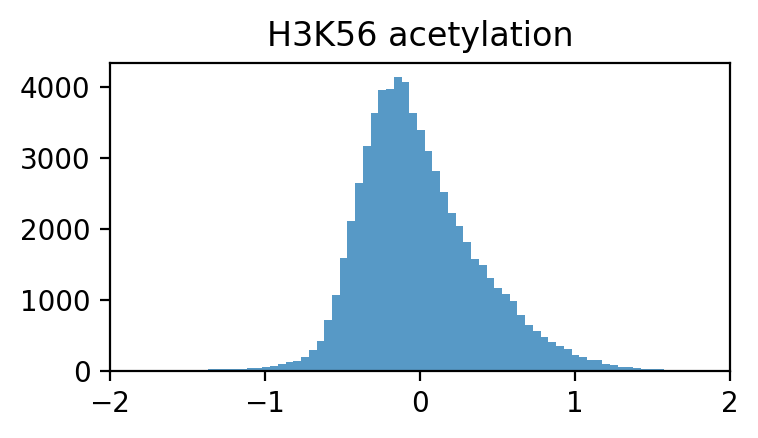

In [445]:
plt.figure(figsize=(4, 2))
plt.hist(nuc_h3k56ac_table.mean_acetylation, bins=100, alpha=0.75)
plt.title("H3K56 acetylation")
plt.xlim(-2, 2)
0

Cluster 1
   134 ORFS with acetylation greater than 0.5
Cluster 2
   419 ORFS with acetylation greater than 0.5
Cluster 3
   142 ORFS with acetylation greater than 0.5
Cluster 4
   434 ORFS with acetylation greater than 0.5
Cluster 5
   163 ORFS with acetylation greater than 0.5


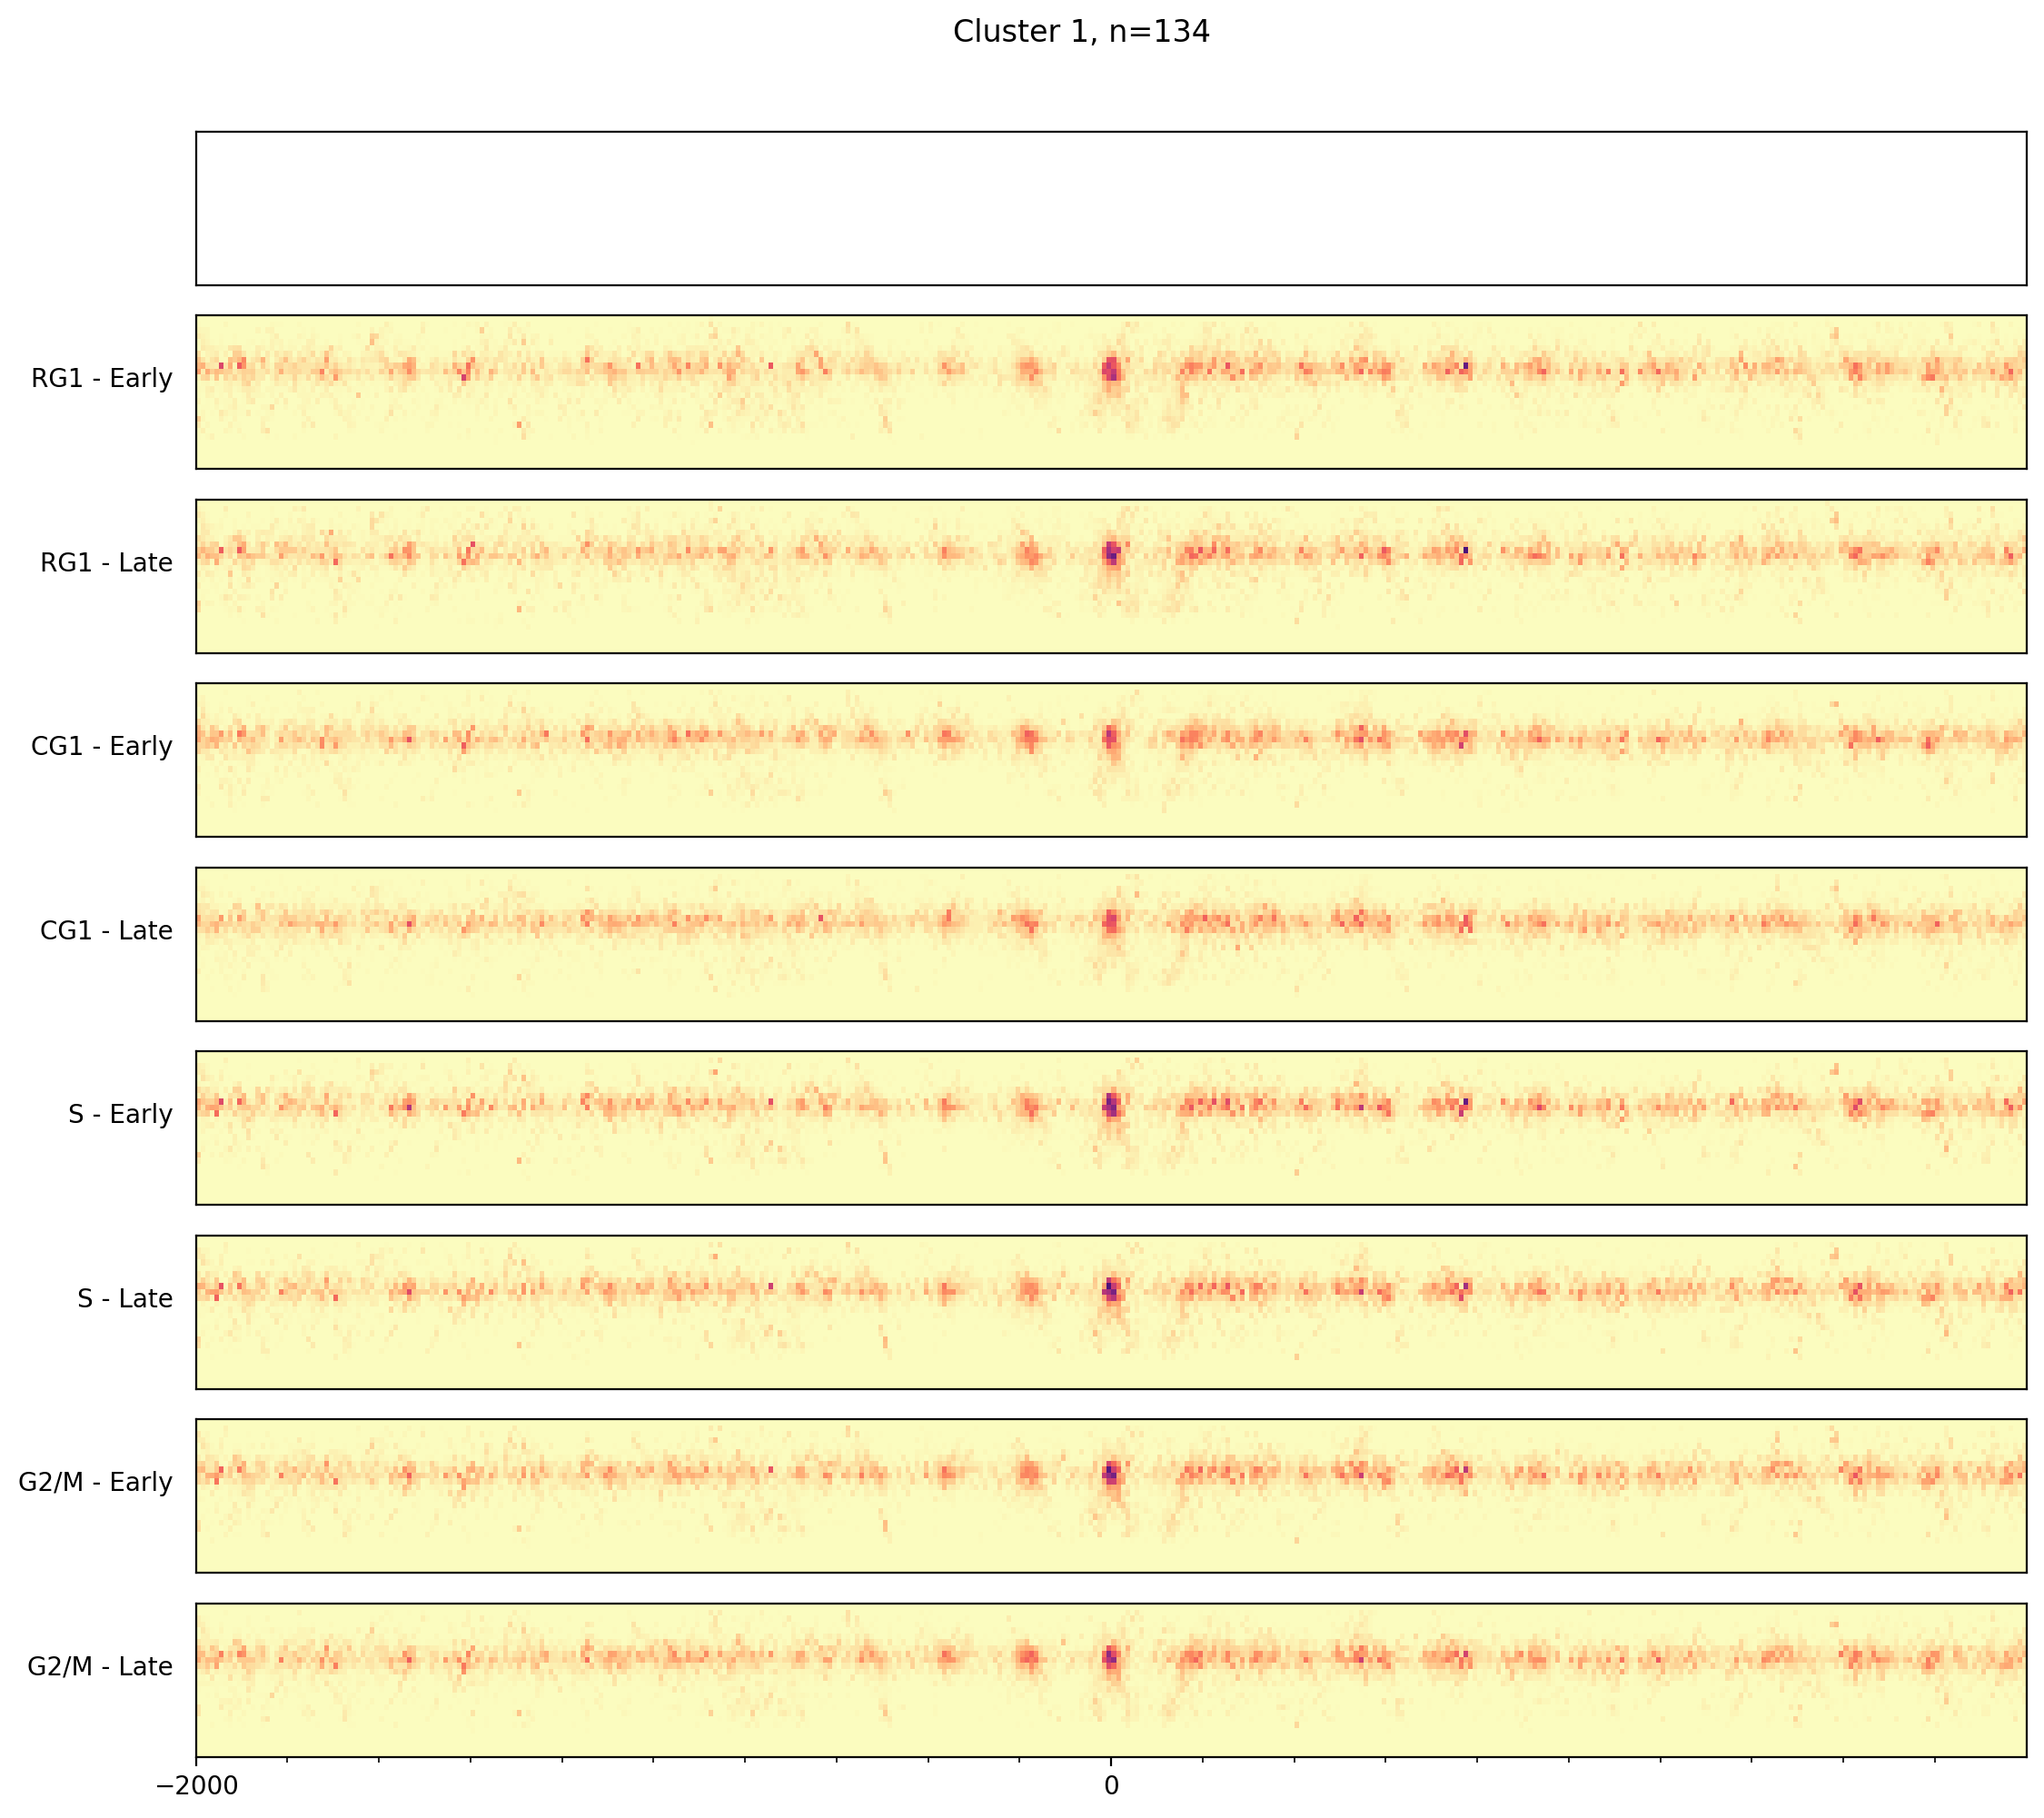

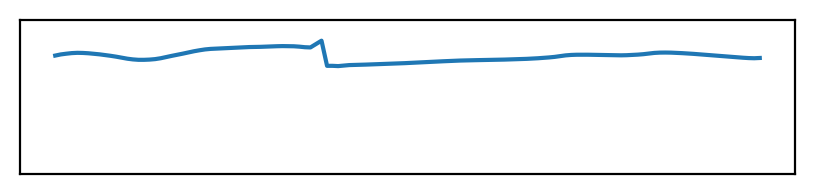

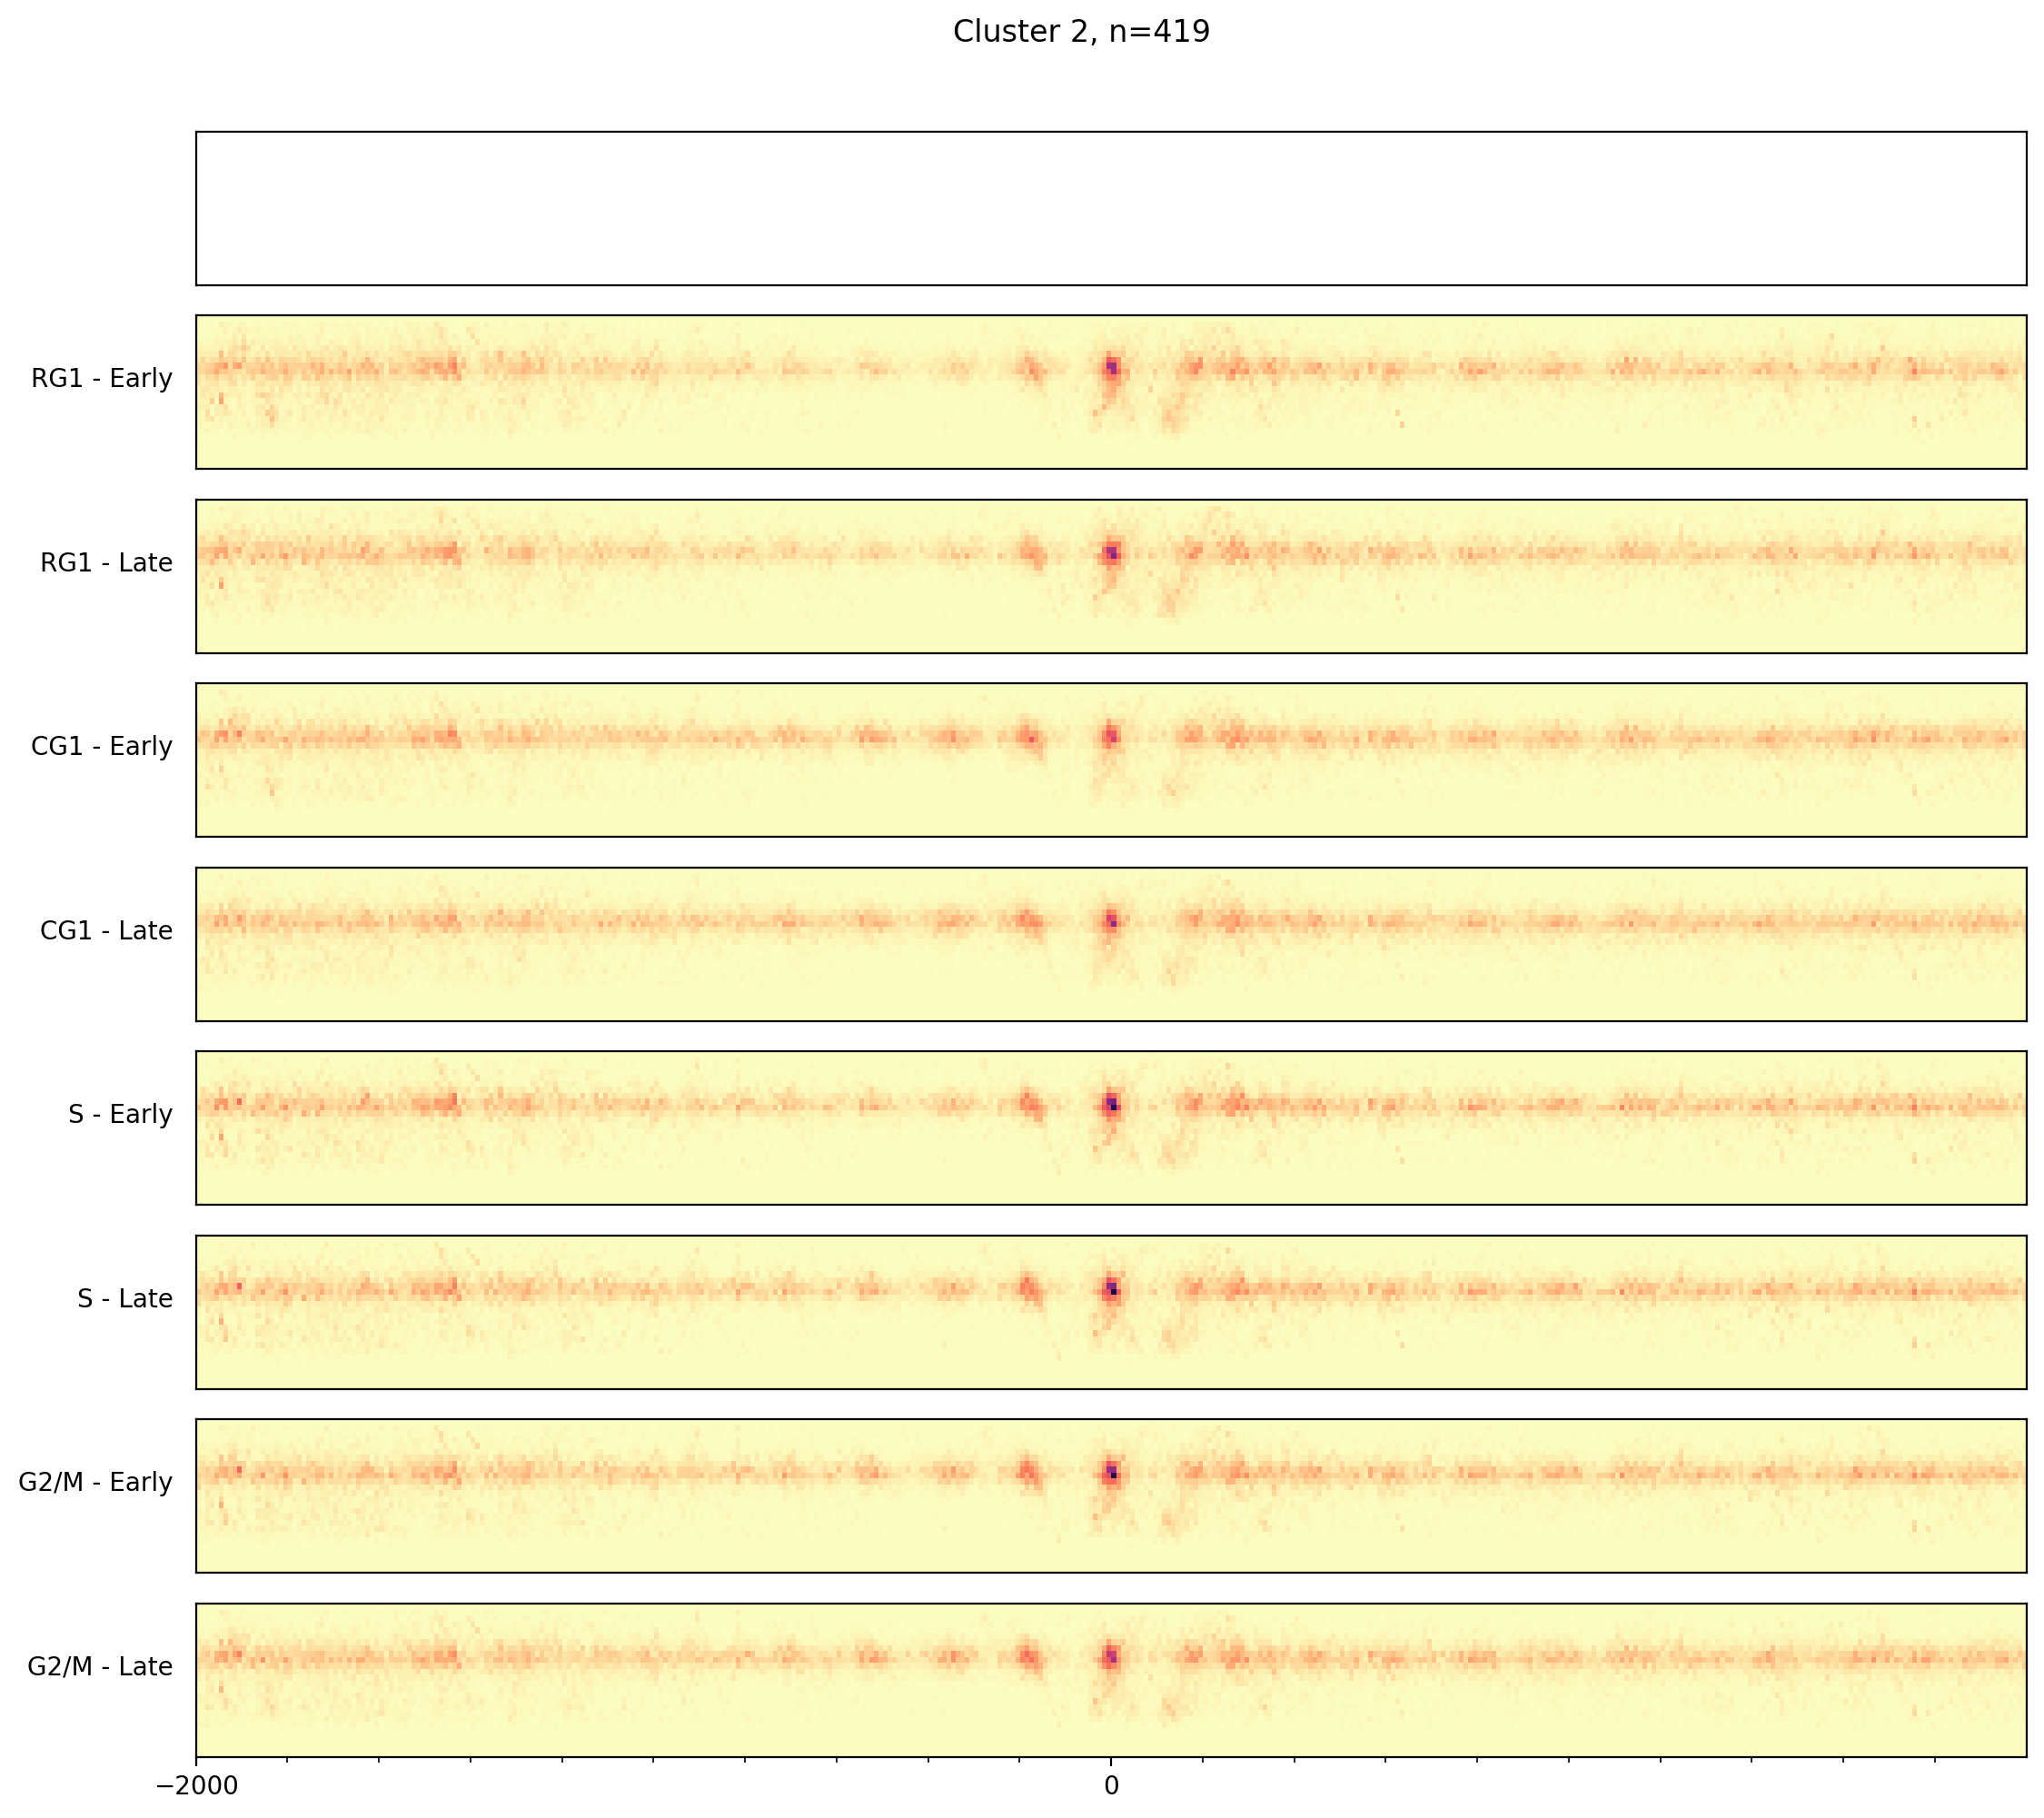

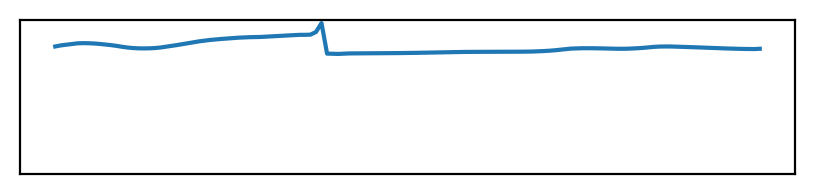

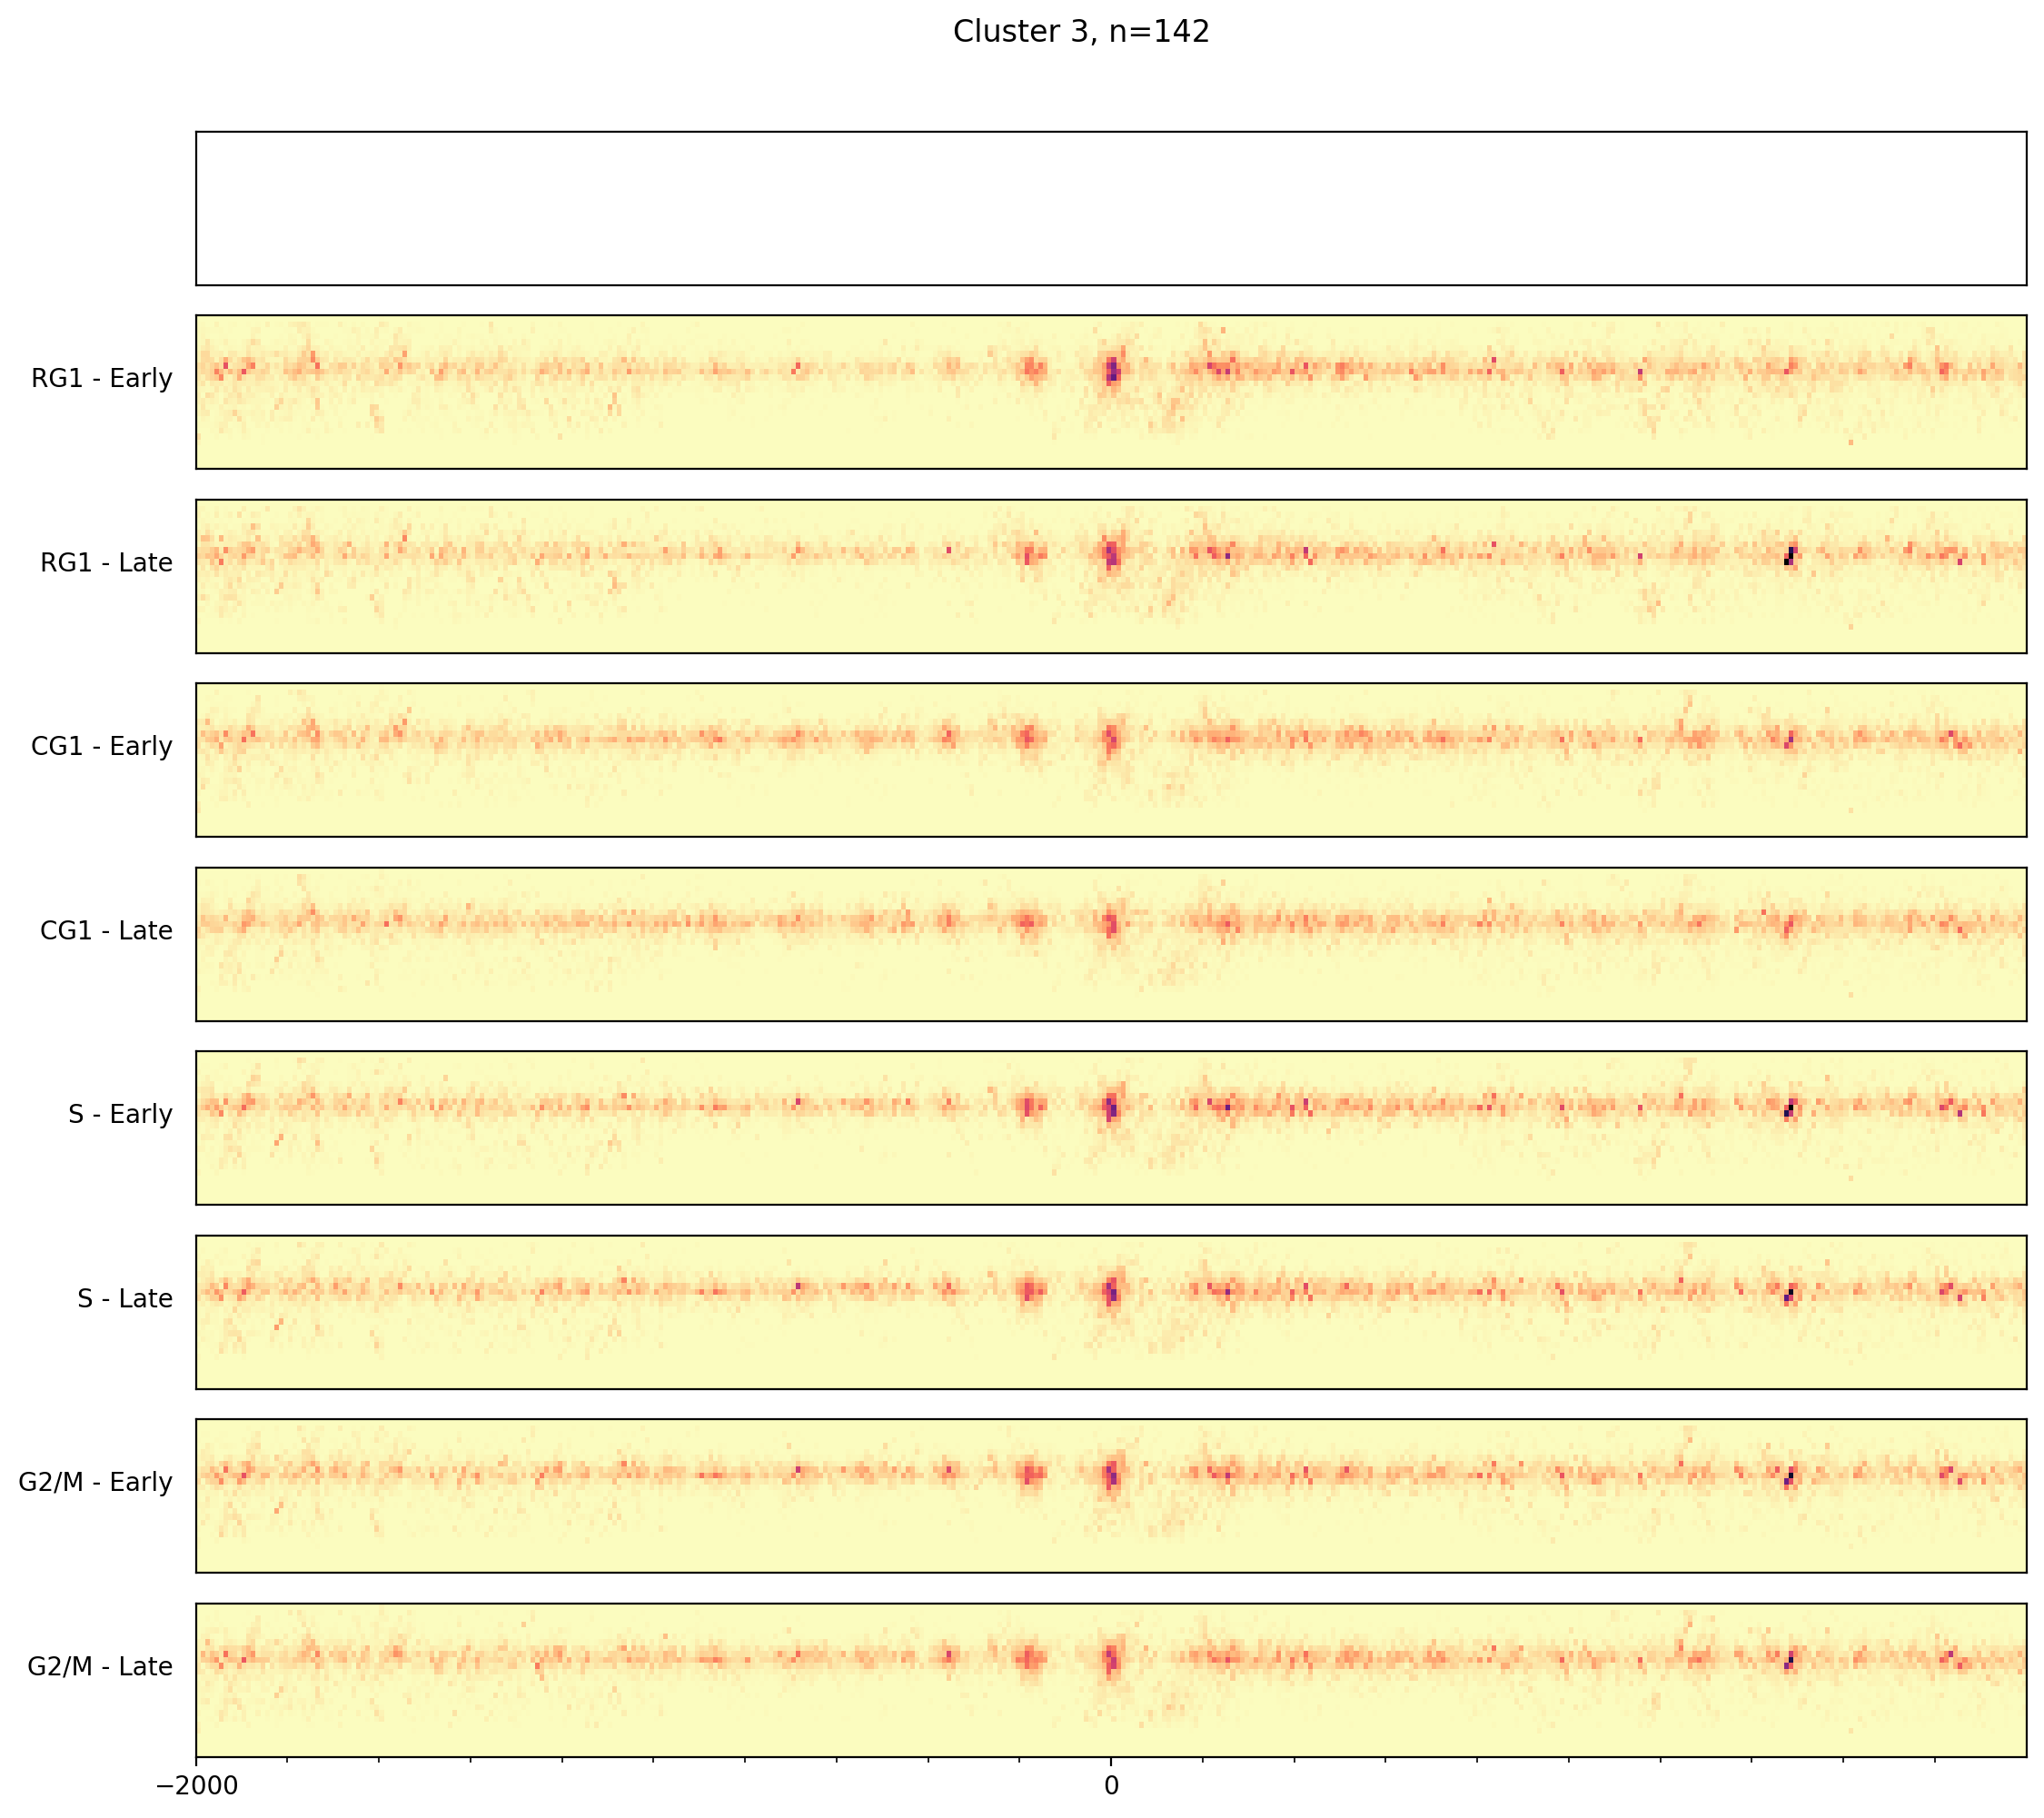

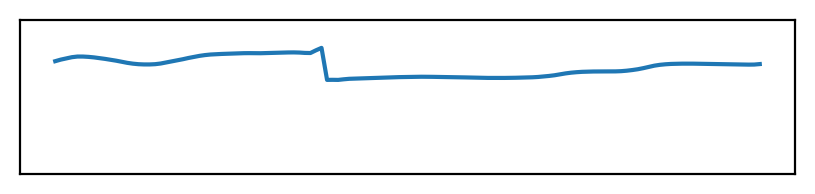

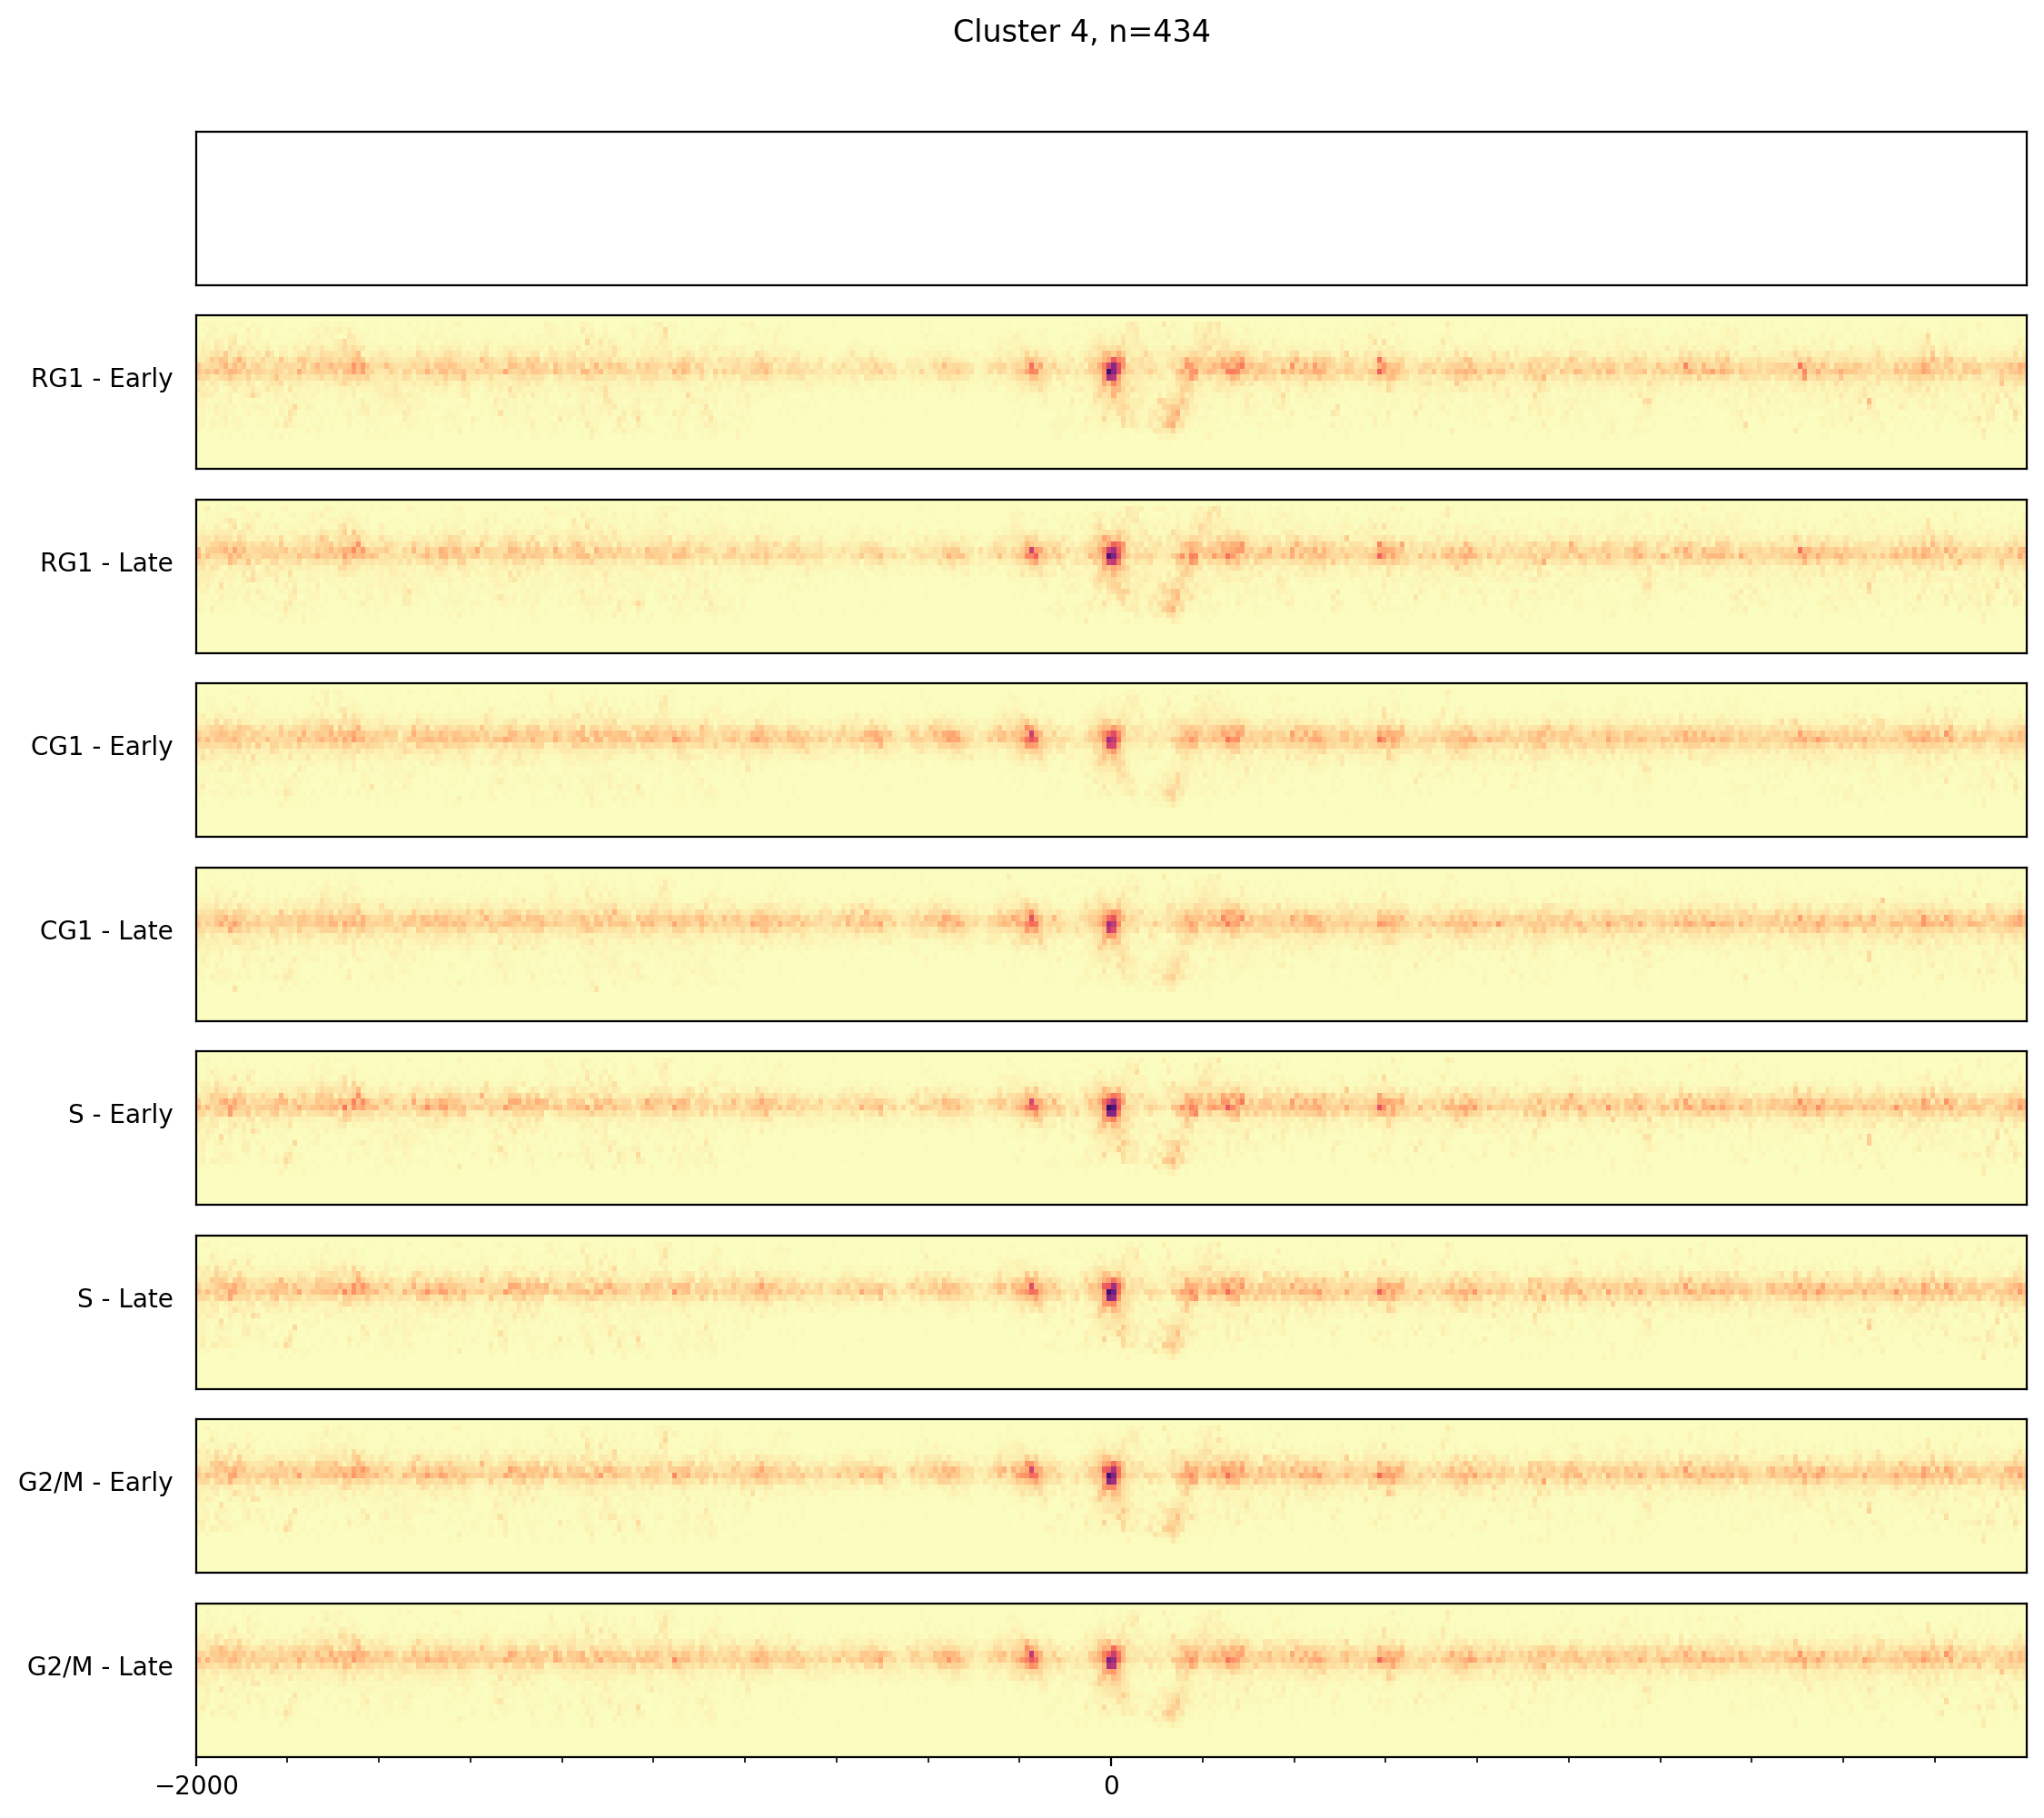

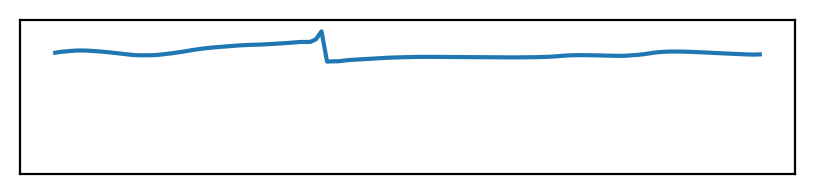

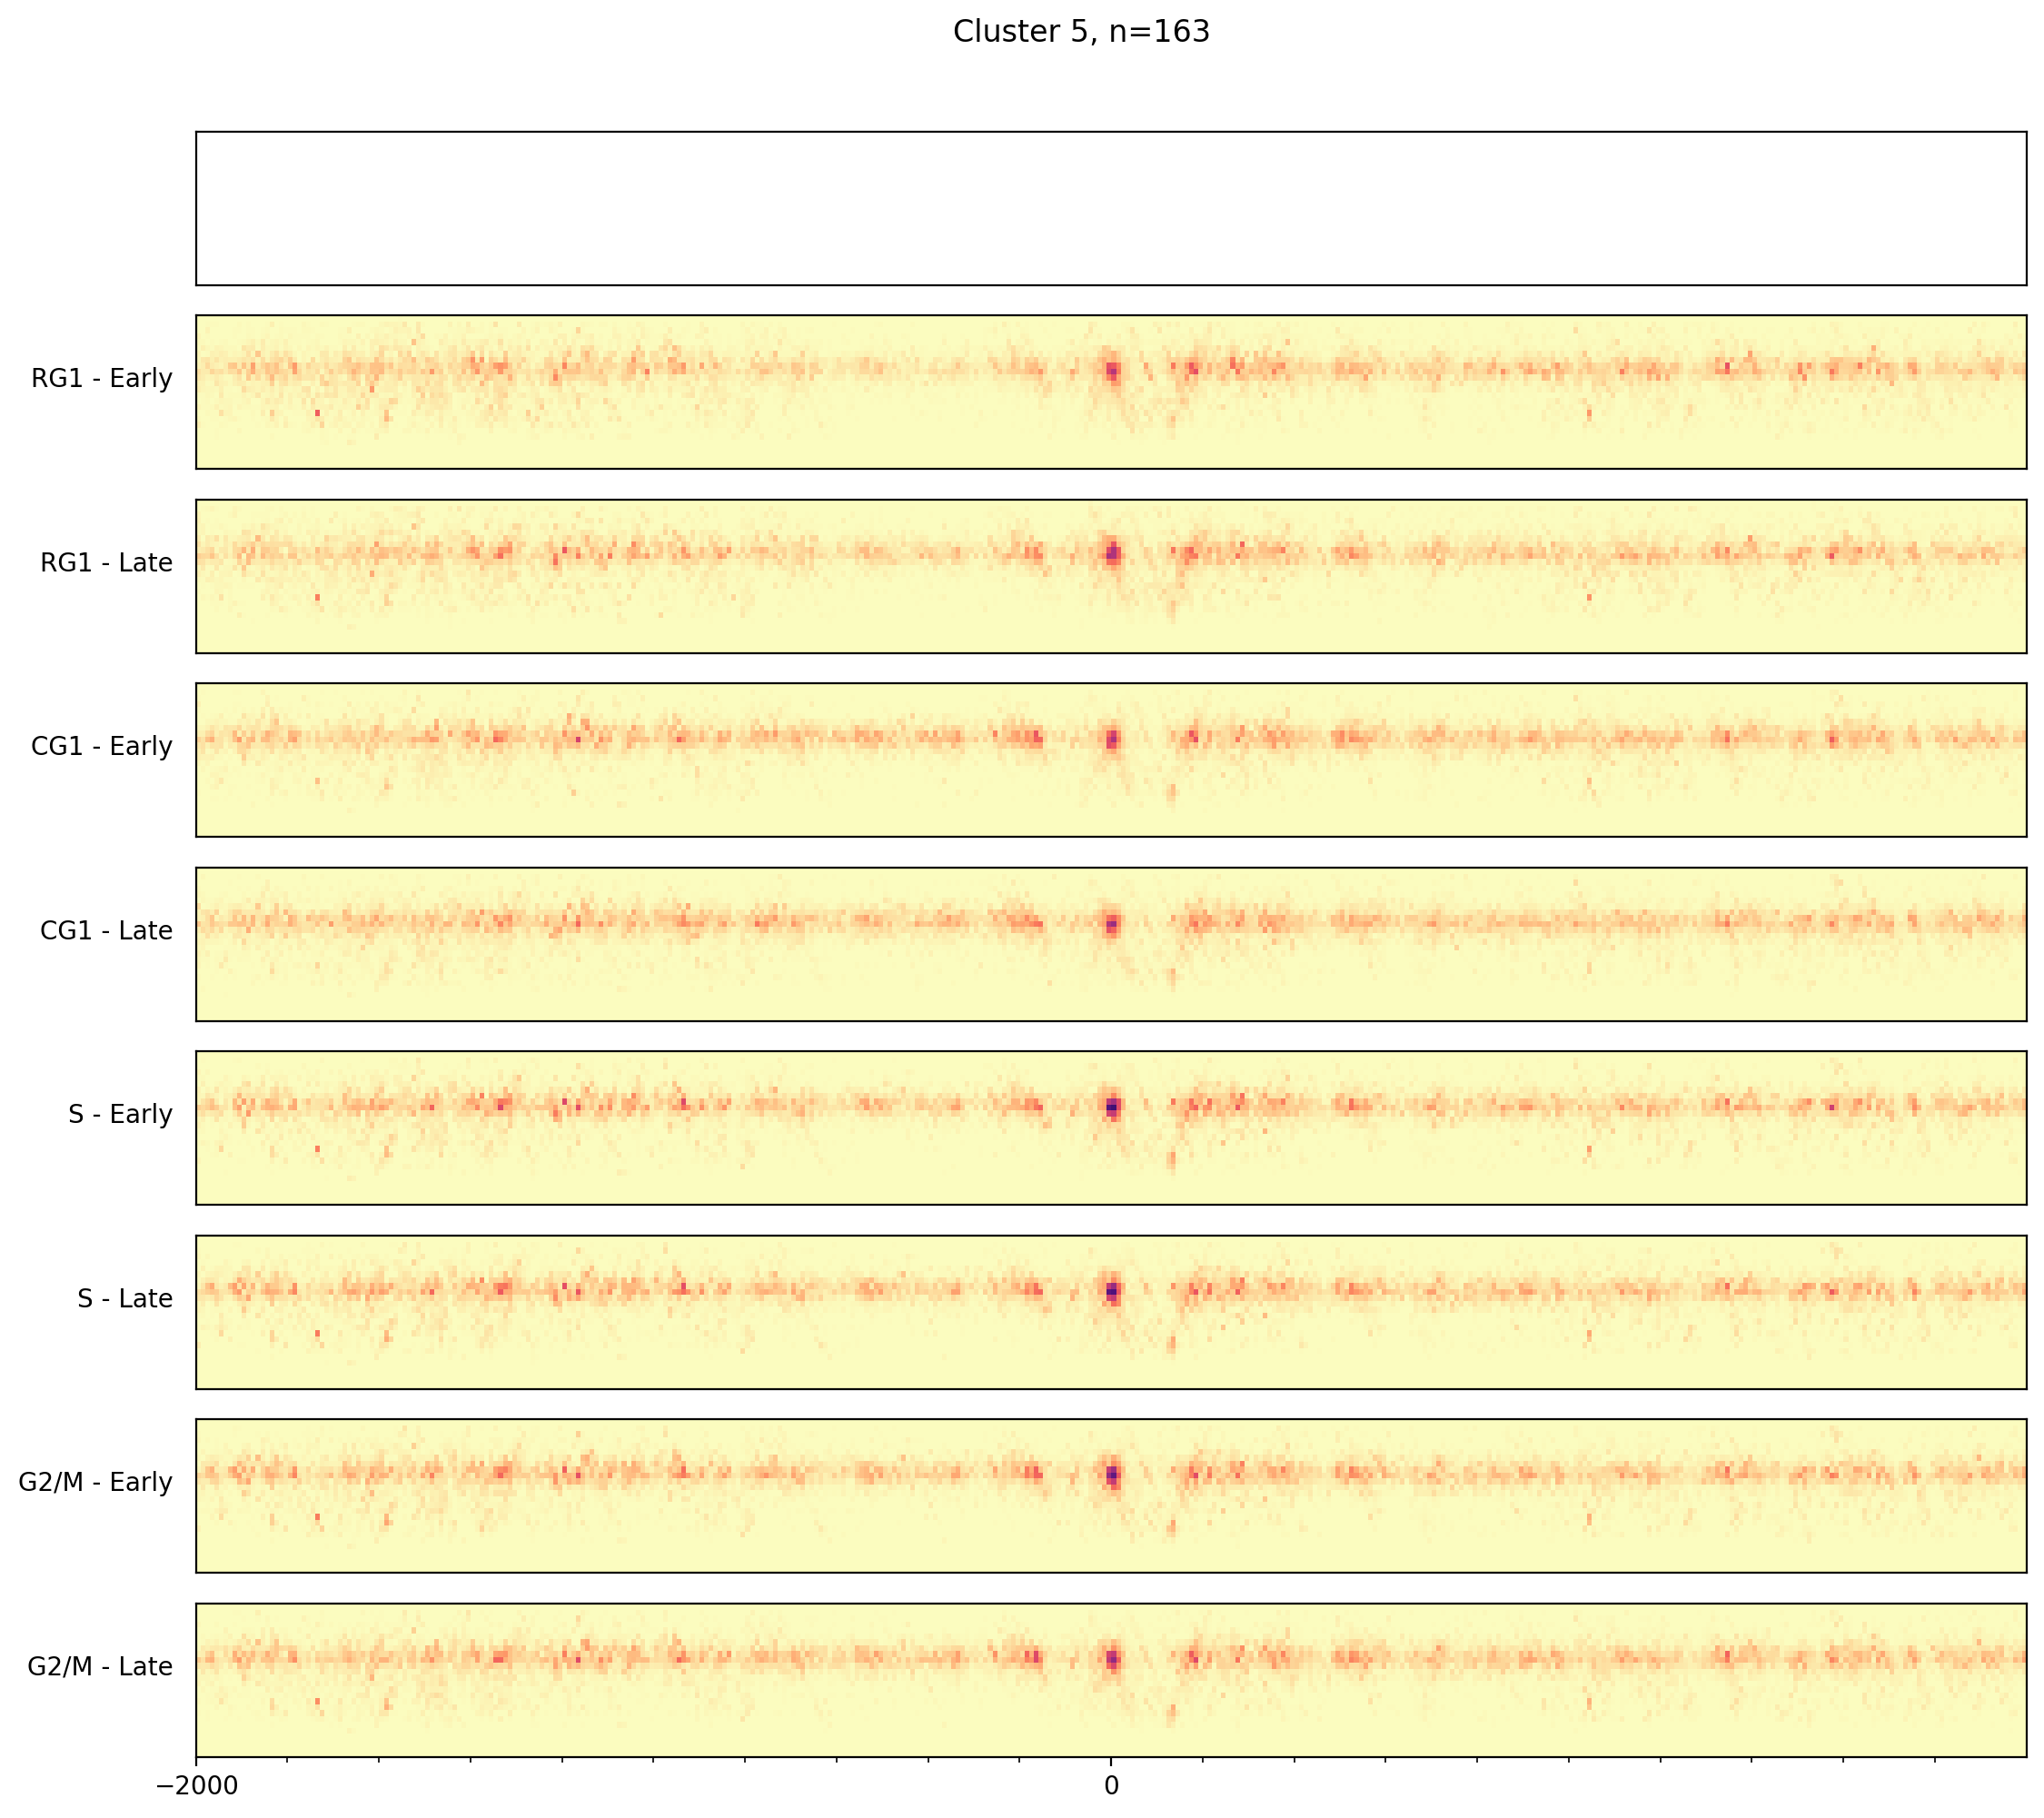

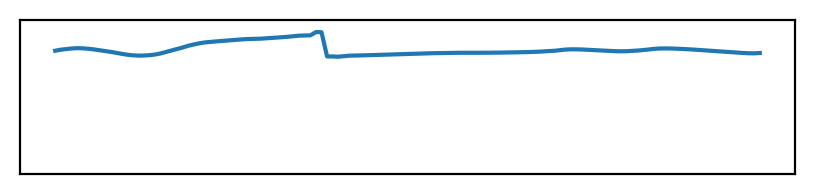

In [515]:
for cluster in range(1, 6):
    
    print(f"Cluster {cluster}")
    
    cluster_geneset = genes_sorted_by_cluster.loc[cluster][[]]

    cluster_orfs_h3k56ac = list(set(cluster_geneset.index.values)\
        .intersection(set(nuc_h3k56ac_table.acc)))
    cluster_acetl_values = nuc_h3k56ac_table.set_index('acc').loc[cluster_orfs_h3k56ac]
    
    # How many above 1?
    threshold_val = 0.5
    thresholded_orfs = cluster_acetl_values[\
        cluster_acetl_values.mean_acetylation > threshold_val].index
    print(f"   {len(thresholded_orfs)} ORFS with acetylation greater than {threshold_val}")
    
    mean_imgs = analysis.load_stacked_mnase_data_for_genes(
        cluster_geneset.loc[thresholded_orfs], 
        center_mode='PAS_nuc')
    
    fig = analysis.plot_deconvolved_result(mean_imgs, (-padding, padding), 
        normalize=True)
    plt.suptitle(f"Cluster {cluster}, n={len(thresholded_orfs)}")

    normalized_mean_imgs = mean_imgs / mean_imgs.sum(axis=1).sum(axis=1).reshape((-1, 1, 1))
    pas_nucleosomes = normalized_mean_imgs[:, :, 131:191] * 50
    entropy_values = []
    for i in range(pas_nucleosomes.shape[0]):
        entropy = calc_entropy(pas_nucleosomes[i].flatten())
        entropy_values.append(entropy)
    entropy_values = np.array(entropy_values)

    plt.figure(figsize=(5, 1))
    plt.plot(entropy_values[t_indices])
    plt.ylim(7, 9)
    plt.xticks([])
    plt.yticks([])


In [531]:
orfs_h3k56ac = list(set(genes.index.values)\
        .intersection(set(nuc_h3k56ac_table.acc)))
orfs_nuc_h3k56ac_table = nuc_h3k56ac_table.set_index('acc').loc[orfs_h3k56ac].sort_values('mean_acetylation',
    ascending=False)

highest_acetylated_orfs = orfs_nuc_h3k56ac_table.head(200)
lowest_acetylated_orfs = orfs_nuc_h3k56ac_table.tail(200)

In [545]:
orfs_nuc_h3k56ac_table.reset_index()[['acc', 'mean_acetylation']].groupby('acc').mean()

,mean_acetylation
acc,
YAL001C,-0.410972
YAL002W,-0.115362
YAL003W,0.120556
YAL005C,-0.145714
YAL007C,0.220833
...,...
YPR196W,0.335556
YPR198W,0.083542
YPR199C,0.761389


Text(0.5, 0.98, 'Highest Acetylated ORFs')

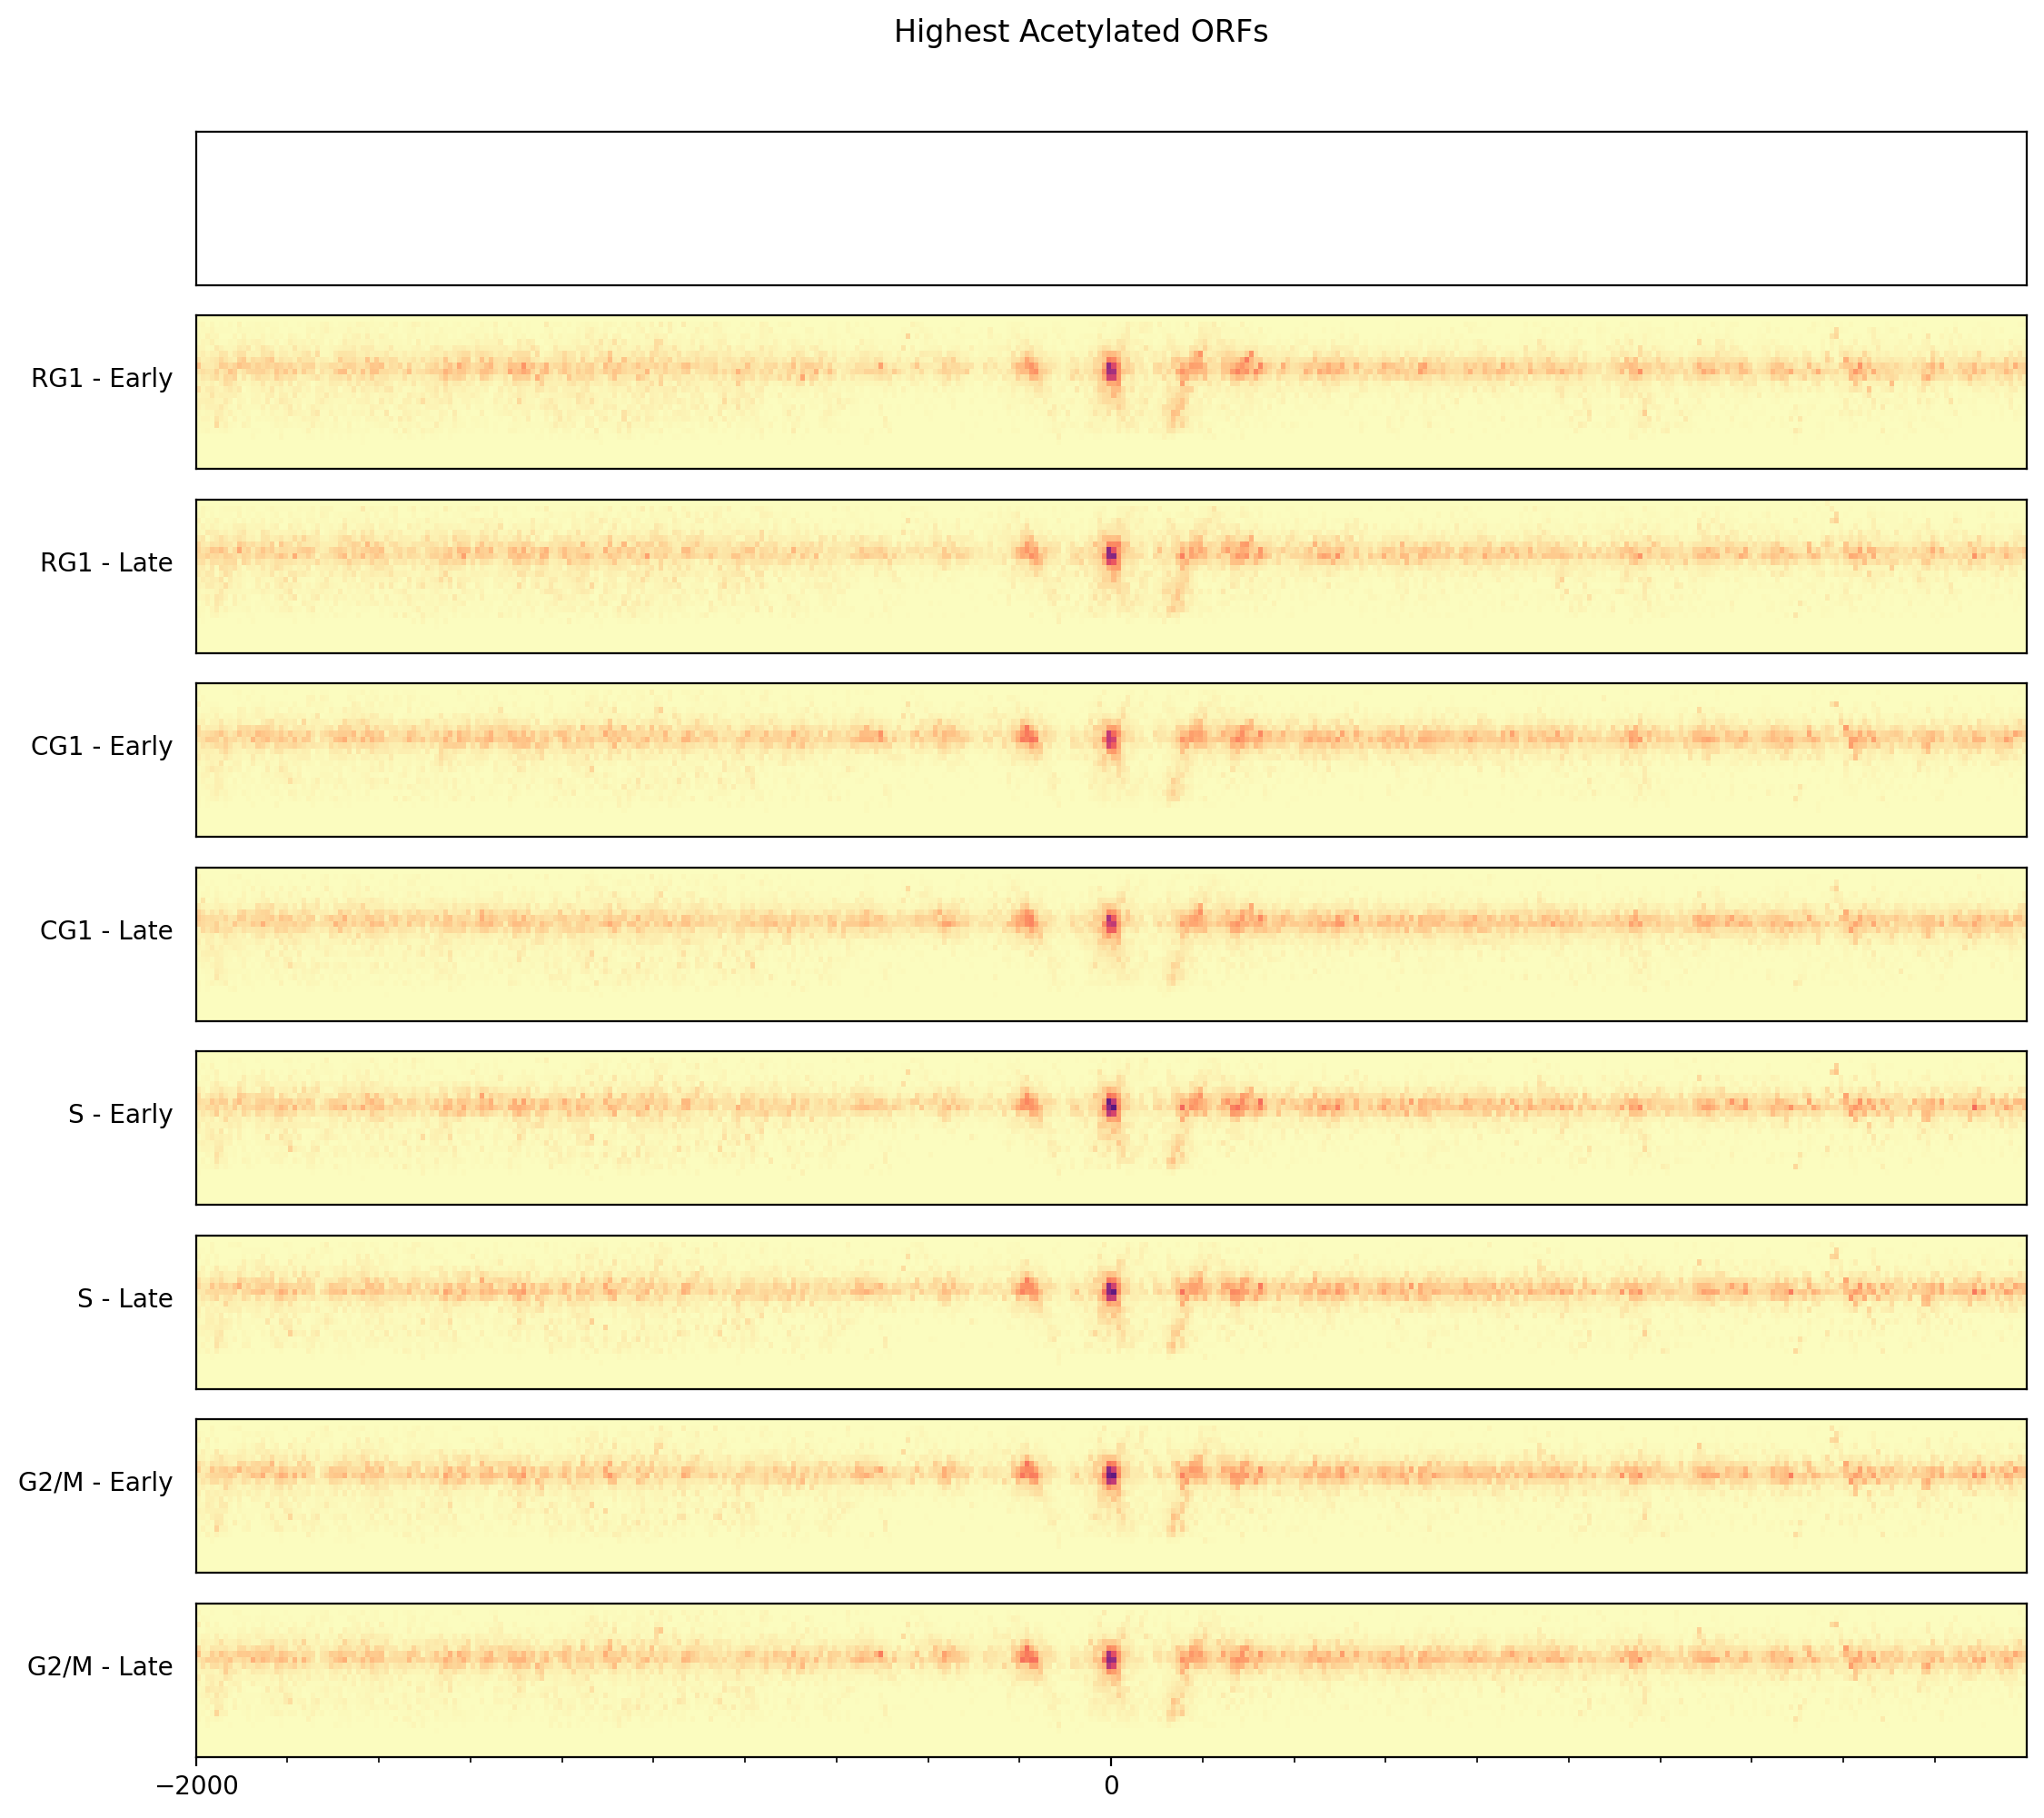

In [558]:
mean_imgs = analysis.load_stacked_mnase_data_for_genes(highest_acetylated_orfs, 
    center_mode='PAS_nuc')

fig = analysis.plot_deconvolved_result(mean_imgs, (-padding, padding), 
    normalize=True)
plt.suptitle(f"Highest Acetylated ORFs")


Failed to load 10 files


Text(0.5, 0.98, 'Lowest acetylated ORFs')

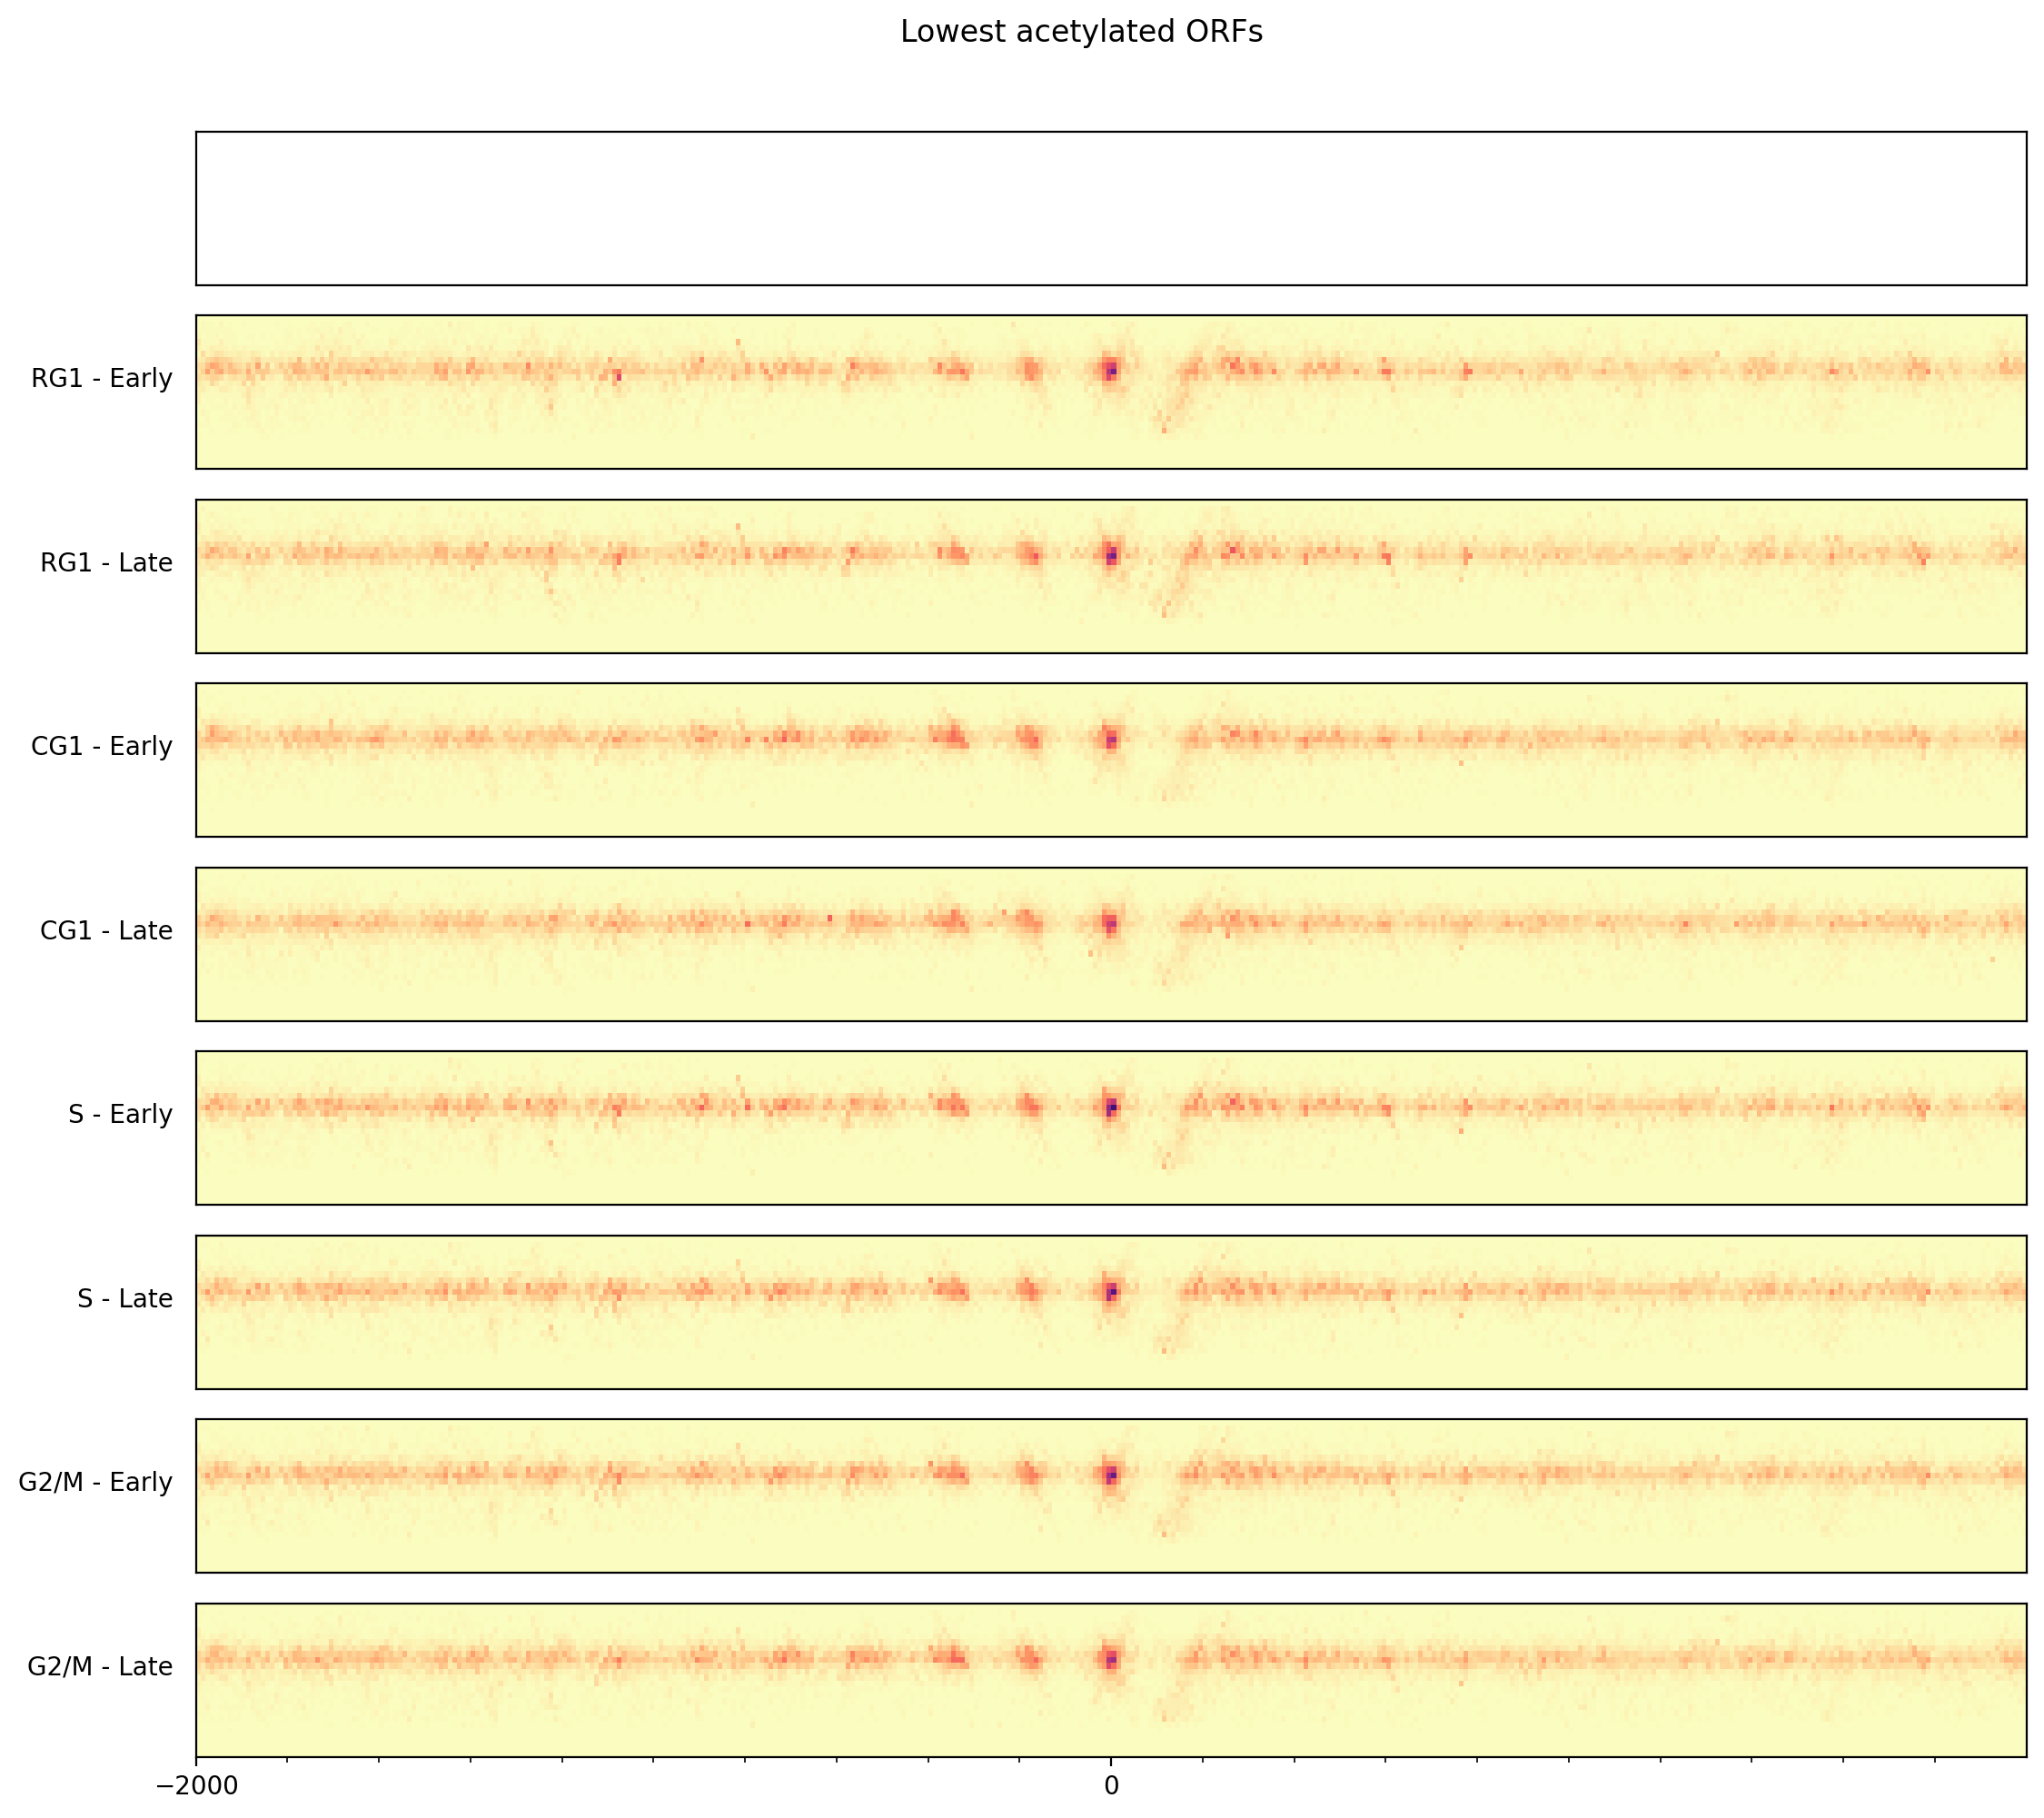

In [547]:
mean_imgs = analysis.load_stacked_mnase_data_for_genes(lowest_acetylated_orfs, 
    center_mode='PAS_nuc')

fig = analysis.plot_deconvolved_result(mean_imgs, (-padding, padding), 
    normalize=True)
plt.suptitle(f"Lowest acetylated ORFs")


In [554]:
genes_replication = pd.read_csv('data/replication_timing/yl_2019/genes_replication_timing_shared.csv').set_index('orf_name')
genes_replication = genes_replication.sort_values('replication_time')

Text(0.5, 0.98, 'Earliest replicating')

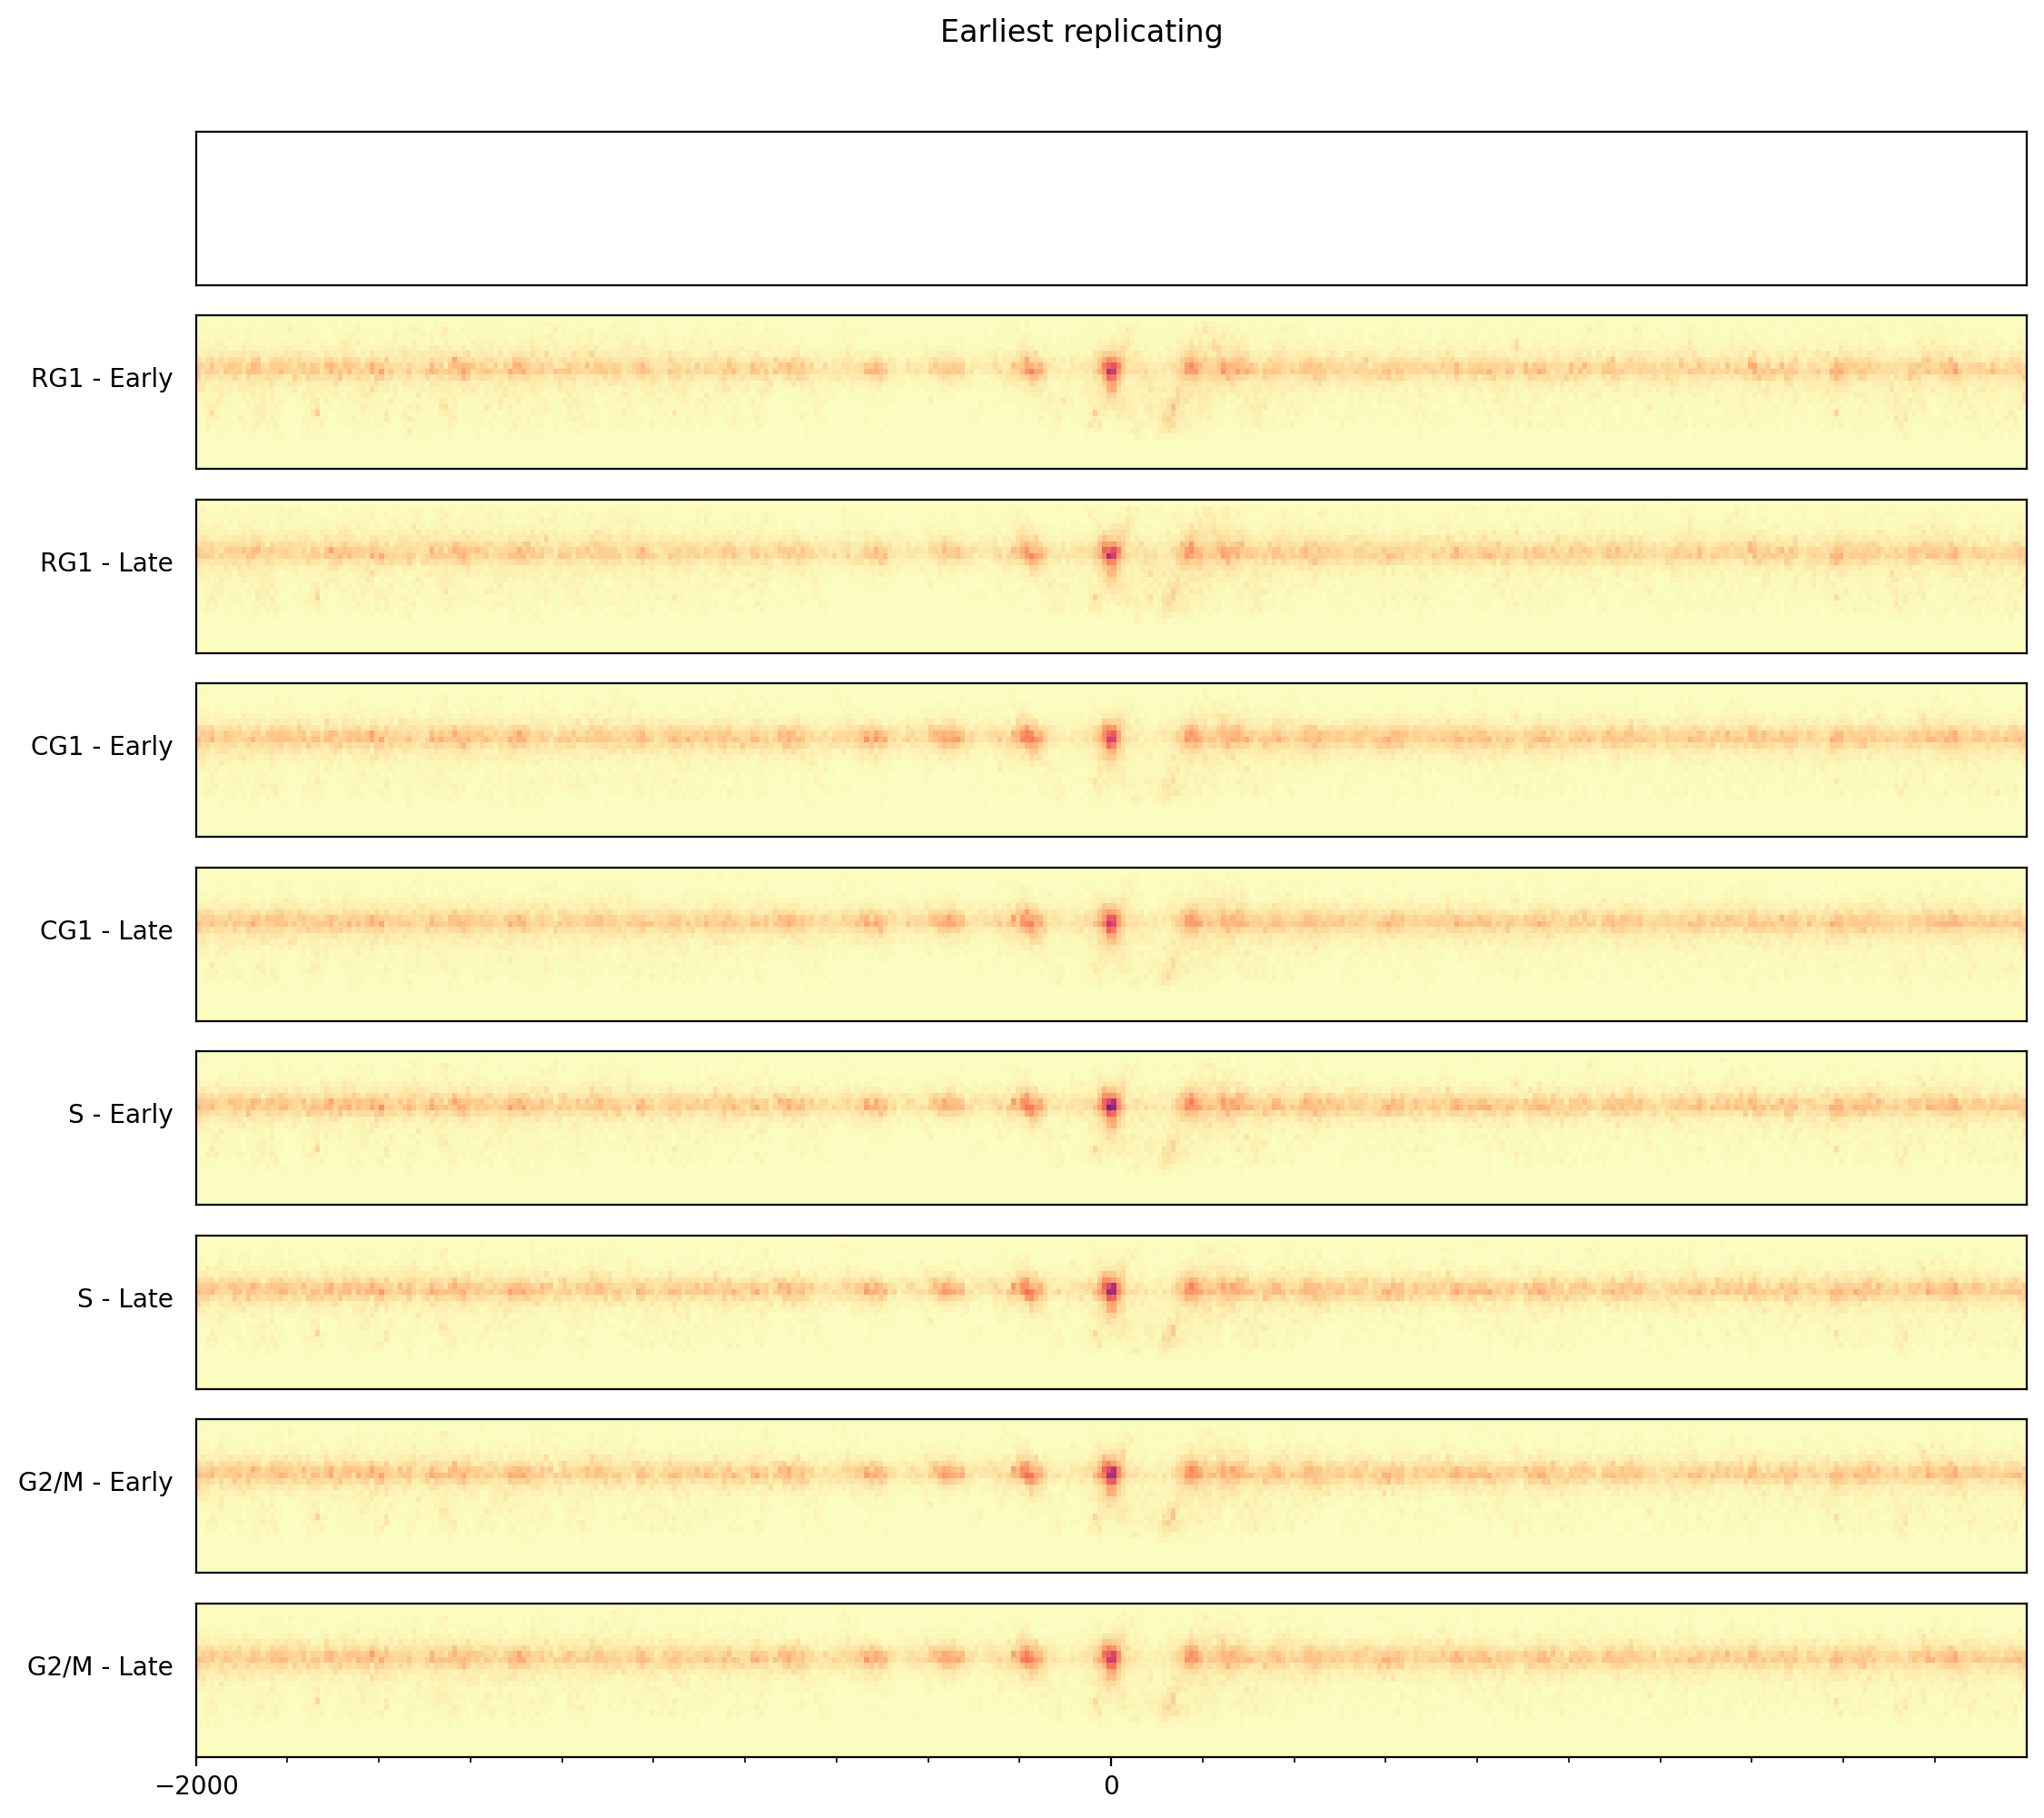

In [556]:
mean_imgs = analysis.load_stacked_mnase_data_for_genes(genes_replication.head(200), 
    center_mode='PAS_nuc')

fig = analysis.plot_deconvolved_result(mean_imgs, (-padding, padding), 
    normalize=True)
plt.suptitle(f"Earliest replicating")


Failed to load 1 files


Text(0.5, 0.98, 'Latest replicating')

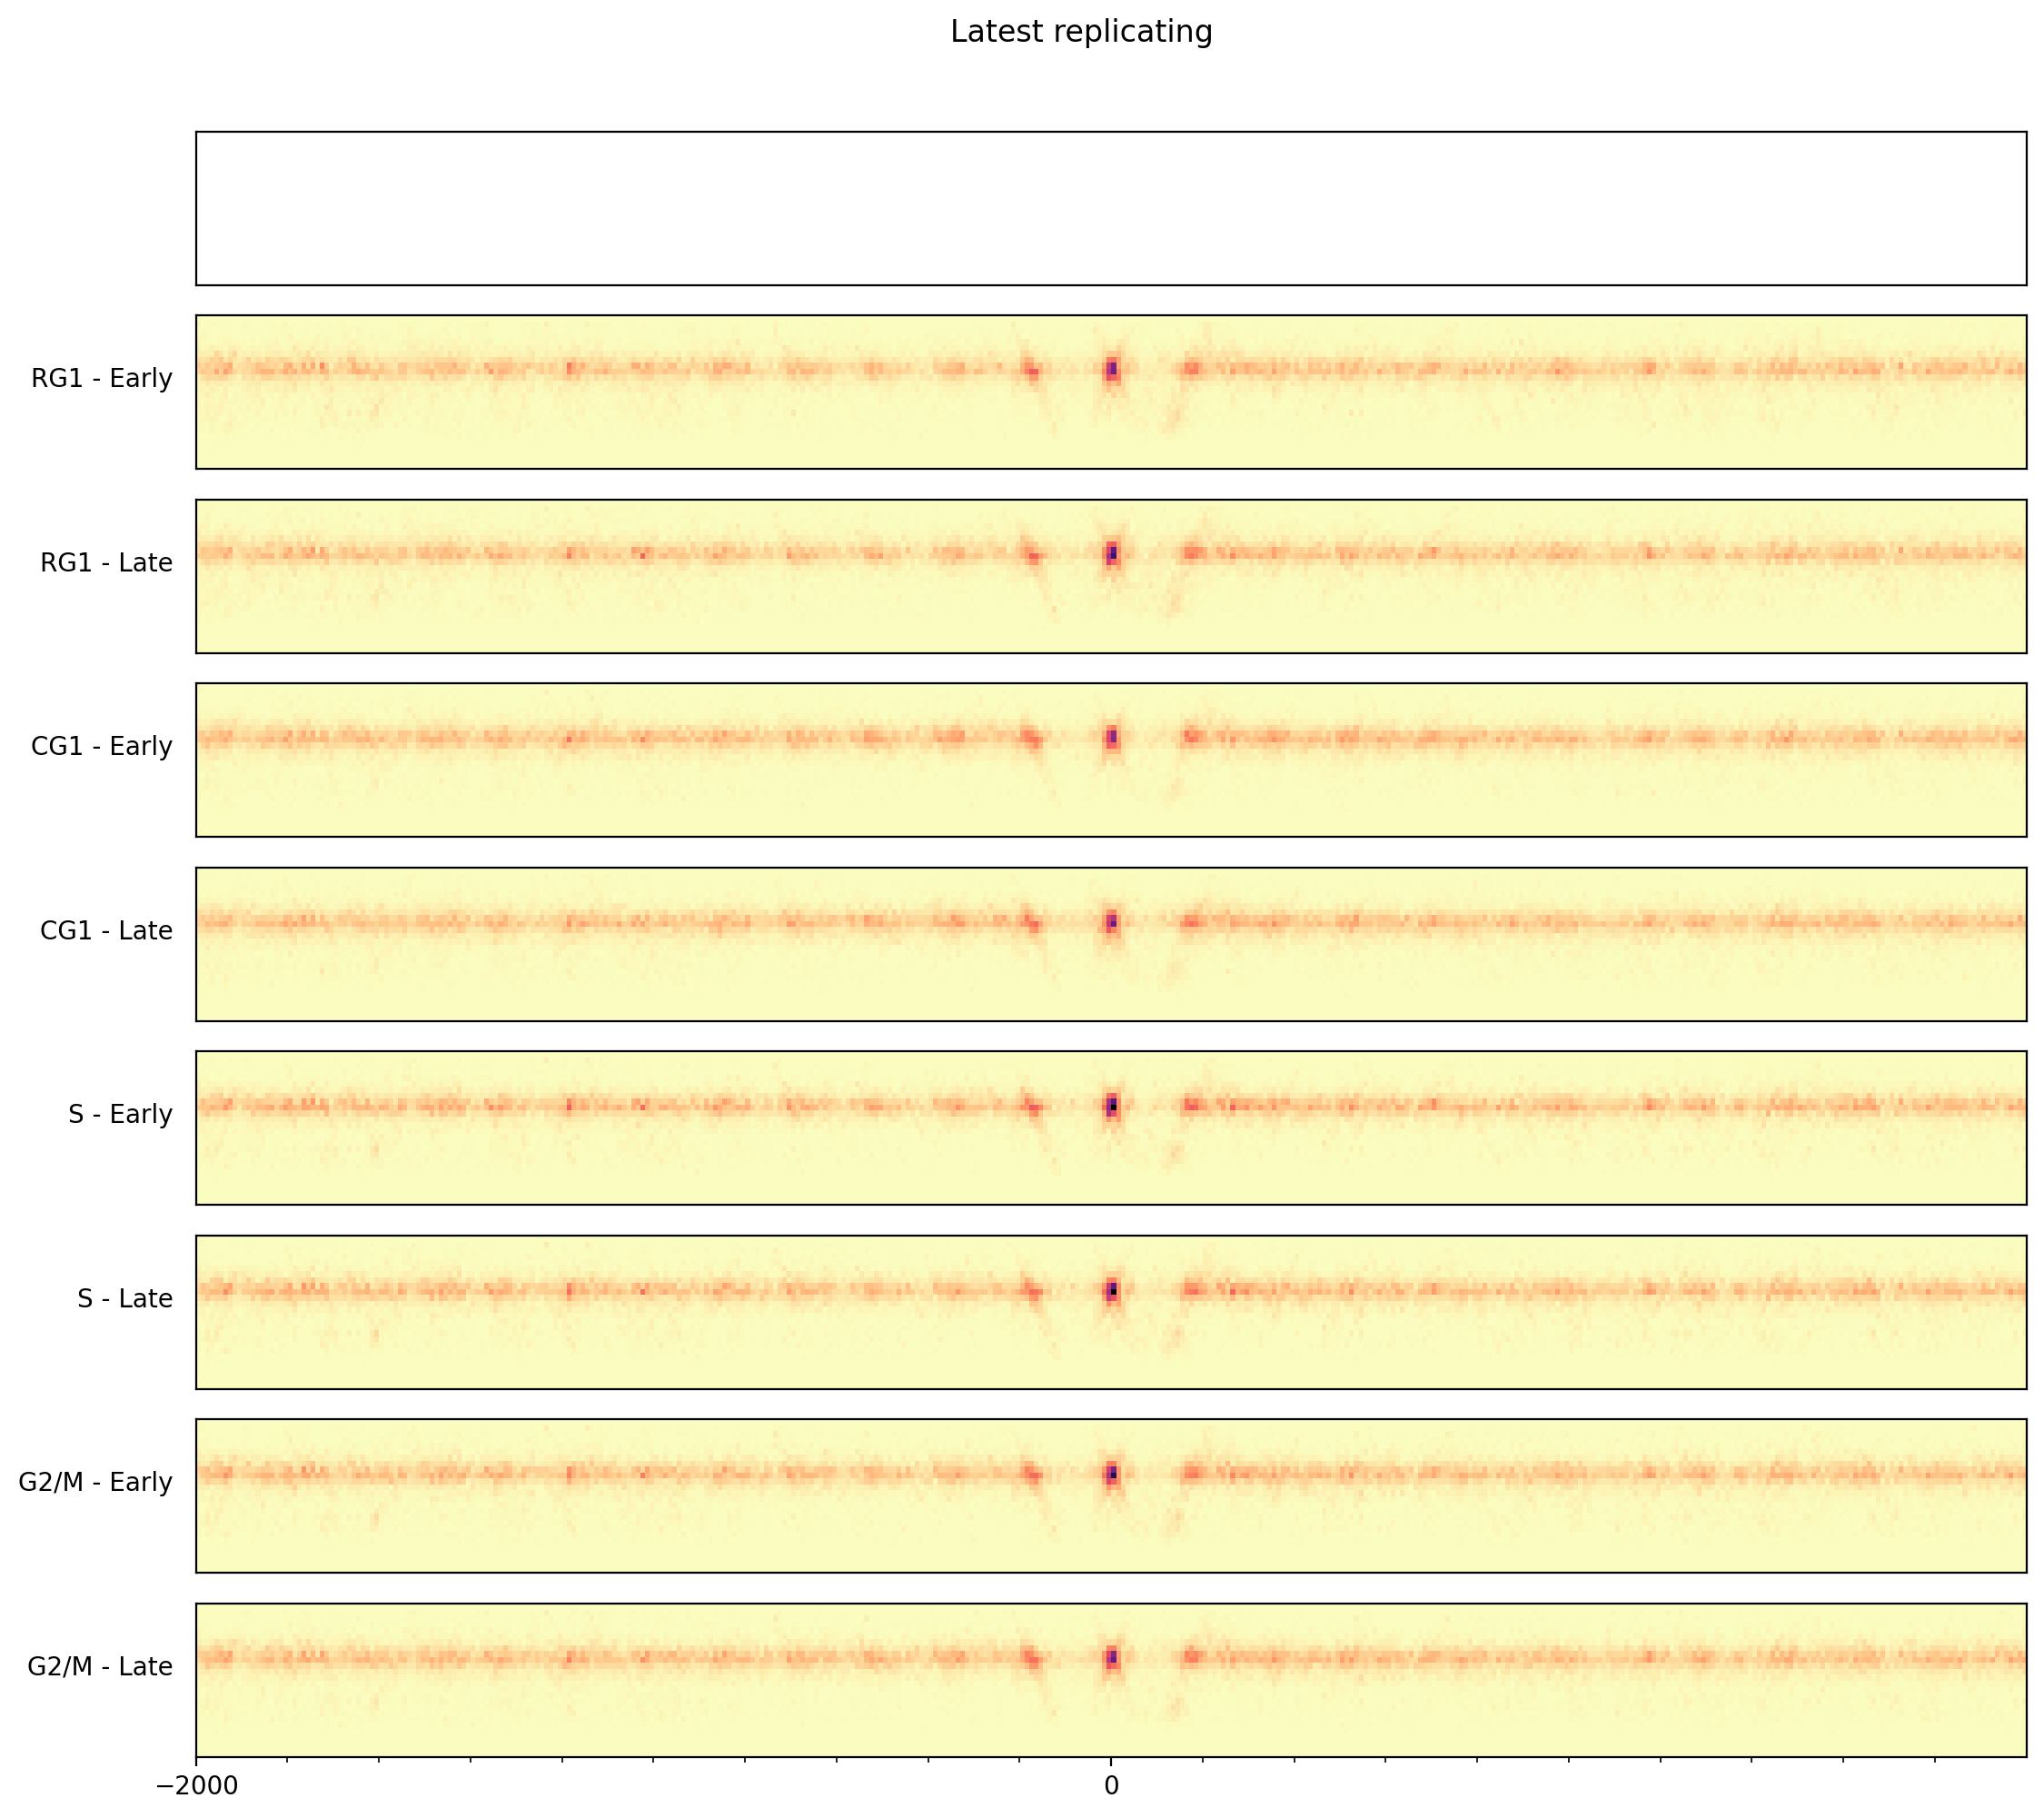

In [557]:
mean_imgs = analysis.load_stacked_mnase_data_for_genes(genes_replication.tail(200), 
    center_mode='PAS_nuc')

fig = analysis.plot_deconvolved_result(mean_imgs, (-padding, padding), 
    normalize=True)
plt.suptitle(f"Latest replicating")
